# IMPORT PACKAGES

In [150]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.decomposition import PCA
from statsmodels.stats.multitest import fdrcorrection
import matplotlib_venn
from venny4py.venny4py import *
from scipy import stats
import math
from matplotlib.lines import Line2D
from matplotlib.text import Text
from sklearn.preprocessing import RobustScaler,MinMaxScaler,StandardScaler
import lightgbm as lgb
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import cross_val_score, cross_val_predict, GridSearchCV
from sklearn.feature_selection import SelectKBest, f_classif, SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn.svm import SVC
from xgboost import XGBClassifier
import pickle
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score
import matplotlib
import random
import unicodeit
from matplotlib.colors import LinearSegmentedColormap
import umap
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from scipy.stats import shapiro

# DEFINE FUNCTION

In [151]:
#def histogram_entropy(data, bins=500):
#    # Create histogram
#    hist, bin_edges = np.histogram(data, bins=bins, density=True)

#    # Normalize histogram to represent a probability density function
#    hist = hist / hist.sum()
    
#    # Remove zero entries to avoid log(0)
#    hist = hist[hist > 0]
    
#    # Calculate entropy
#    entropy = -np.sum(hist * np.log(hist))
    
#    return entropy


def histogram_entropy(data, bins=500):
    # 1. Chuyển sang mảng numpy và xử lý giá trị Inf/NaN
    data = np.array(data)
    # Thay thế Inf bằng giá trị thực lớn nhất và -Inf bằng nhỏ nhất, NaN bằng 0
    clean_data = np.nan_to_num(data, nan=0.0, posinf=None, neginf=None)
    
    # Lọc bỏ Inf nếu np.nan_to_num chưa xử lý hết (để đảm bảo finite)
    clean_data = clean_data[np.isfinite(clean_data)]
    
    # 2. Kiểm tra nếu mảng rỗng hoặc chỉ có 1 giá trị duy nhất sau khi lọc
    if len(clean_data) == 0 or np.ptp(clean_data) == 0:
        return 0.0

    # 3. Đảm bảo bins không nhỏ hơn 1
    actual_bins = max(1, bins)

    # 4. Tính toán histogram
    hist, bin_edges = np.histogram(clean_data, bins=actual_bins, density=True)
    
    # Chuẩn hóa để thành PDF (Probability Density Function)
    hist_sum = hist.sum()
    if hist_sum == 0:
        return 0.0
        
    prob_dist = hist / hist_sum
    
    # 5. Tính Entropy (chỉ tính cho các bin có xác suất > 0)
    prob_dist = prob_dist[prob_dist > 0]
    entropy = -np.sum(prob_dist * np.log2(prob_dist))
    
    return entropy

In [152]:
def STATS_binary(df_1, df_2, col_start, name_1, name_2, groups_PADJ=[]):
    import pandas as pd
    import numpy as np
    from statsmodels.stats.multitest import fdrcorrection
    from scipy import stats
    import math
    from sklearn import metrics

    # Khởi tạo các list
    Mean_1, Mean_2, Median_1, Median_2 = [], [], [], []
    Feature, P_value, AUC, Log2FC, Log2FC_Median = [], [], [], [], []
    SD_1, SD_2, CVpct_1, CVpct_2 = [], [], [], []
    Entropy_1, Entropy_2 = [], []

    # Vòng lặp chính xử lý từng Feature
    for i in range(col_start, df_1.shape[1]):
        # Lấy dữ liệu dạng mảng để tính toán nhanh
        val1 = df_1.iloc[:, i].values
        val2 = df_2.iloc[:, i].values
        
        # 1. Mean & Median
        m1, m2 = np.mean(val1), np.mean(val2)
        me1, me2 = np.median(val1), np.median(val2)
        Mean_1.append(m1)
        Mean_2.append(m2)
        Median_1.append(me1)
        Median_2.append(me2)

        # 2. P-value (Ranksum test)
        P_value.append(stats.ranksums(val1, val2)[1])

        # 3. Log2FC an toàn (Sử dụng np.log2)
        # Tránh lỗi math domain bằng cách kiểm tra điều kiện > 0
        if m1 > 0 and m2 > 0:
            Log2FC.append(np.log2(m2 / m1))
        elif m1 == 0 and m2 > 0:
            Log2FC.append(10) # Giá trị gán cho trường hợp tăng đột biến từ 0
        elif m2 == 0 and m1 > 0:
            Log2FC.append(-10) # Giá trị gán cho trường hợp giảm về 0
        else:
            Log2FC.append(0)

        if me1 > 0 and me2 > 0:
            Log2FC_Median.append(np.log2(me2 / me1))
        else:
            Log2FC_Median.append(0)

        # 4. Feature name & AUC
        Feature.append(df_1.columns[i])
        
        y_true = [0]*len(val1) + [1]*len(val2)
        y_scores = np.nan_to_num(np.concatenate([val1, val2]), nan=0.0)
        
        try:
            # AUC chỉ tính được khi có ít nhất 2 class và các giá trị không trùng lặp hoàn toàn
            if len(np.unique(y_scores)) <= 1:
                AUC.append(0.5)
            else:
                AUC.append(metrics.roc_auc_score(y_true, y_scores))
        except:
            AUC.append(0.5)

        # 5. SD and CV%
        sd1, sd2 = np.std(val1), np.std(val2)
        SD_1.append(sd1)
        SD_2.append(sd2)
        CVpct_1.append((sd1 / m1 * 100) if m1 != 0 else np.nan)
        CVpct_2.append((sd2 / m2 * 100) if m2 != 0 else np.nan)

        # 6. Entropy
        # Giả định hàm histogram_entropy đã được định nghĩa bên ngoài
        #Entropy_1.append(histogram_entropy(data=list(val1), bins=int(len(val1)/2)))
        #Entropy_2.append(histogram_entropy(data=list(val2), bins=int(len(val2)/2)))
        # Tính số bins tối thiểu là 10 hoặc một nửa số mẫu
        n_bins_1 = max(10, int(len(val1)/2))
        n_bins_2 = max(10, int(len(val2)/2))
        
        Entropy_1.append(histogram_entropy(data=val1, bins=n_bins_1))
        Entropy_2.append(histogram_entropy(data=val2, bins=n_bins_2))

    # --- TẠO DATAFRAME (Khối này nằm NGOÀI vòng lặp for i) ---
    result = pd.DataFrame({
        'FEATURES': Feature,
        'Mean of ' + name_1: Mean_1,
        'Mean of ' + name_2: Mean_2,
        'Median of ' + name_1: Median_1,
        'Median of ' + name_2: Median_2,
        'SD of ' + name_1: SD_1,
        'SD of ' + name_2: SD_2,
        'CV% of ' + name_1: CVpct_1,
        'CV% of ' + name_2: CVpct_2,
        'Entropy of ' + name_1: Entropy_1,
        'Entropy of ' + name_2: Entropy_2,
        'Log2FC of ' + name_1 + ' vs ' + name_2: Log2FC,
        'Log2FC Median of ' + name_1 + ' vs ' + name_2: Log2FC_Median,
        'P of ' + name_1 + ' vs ' + name_2: P_value
    })

    # 7. Tính PADJ (FDR correction)
    PADJ = [np.nan] * len(result) # Khởi tạo mặc định
    if groups_PADJ:
        all_padj = []
        for g in groups_PADJ:
            mask = result['FEATURES'].str.startswith(g)
            filtered_p = result.loc[mask, 'P of ' + name_1 + ' vs ' + name_2]
            if len(filtered_p) > 0:
                # Thực hiện FDR correction cho từng nhóm đặc trưng
                _, adj_p = fdrcorrection(filtered_p)
                result.loc[mask, 'PADJ of ' + name_1 + ' vs ' + name_2] = adj_p
    else:
        # Nếu không truyền groups_PADJ, tính PADJ trên toàn bộ Feature
        _, adj_p = fdrcorrection(result['P of ' + name_1 + ' vs ' + name_2])
        result['PADJ of ' + name_1 + ' vs ' + name_2] = adj_p

    # 8. Tính toán các cột Log10 P-value, Distance và AUCADJ
    p_col = 'PADJ of ' + name_1 + ' vs ' + name_2
    # Tránh lỗi log10(0) bằng cách giới hạn giá trị tối thiểu
    result['-log10(p-value) of ' + name_1 + ' vs ' + name_2] = result[p_col].apply(
        lambda x: -np.log10(max(x, 1e-100)) if not pd.isna(x) else 0
    )
    
    result['Distance of ' + name_1 + ' vs ' + name_2] = result['Mean of ' + name_2] - result['Mean of ' + name_1]
    result['AUC of ' + name_1 + ' vs ' + name_2] = AUC
    
    log2fc_col = 'Log2FC of ' + name_1 + ' vs ' + name_2
    auc_col = 'AUC of ' + name_1 + ' vs ' + name_2
    
    result['AUCADJ of ' + name_1 + ' vs ' + name_2] = result.apply(
        lambda row: row[auc_col] if row[log2fc_col] >= 0 else 1 - row[auc_col], axis=1
    )

    return result

Volcanofea

In [153]:
def volcanofea(f,pair=['Lung vs Heathy'],alpha=0.05,show_region=False):
    data=stats_fea[f]
    data.index=data.FEATURES
    custom_lines = [Line2D([0], [0],marker='o',color='w', markerfacecolor='gray', markersize=5),
                        # Line2D([0], [0],marker='o', color='w', markerfacecolor='green', markersize=5),
                        # Line2D([0], [0],marker='o', color='w', markerfacecolor='orange', markersize=5),
                        Line2D([0], [0],marker='o', color='w', markerfacecolor='blue', markersize=5),
                        Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=5)]
    for p in pair:
        col_log='Log2FC of '+p
        col_PADJ='-log10(p-value) of '+p
        cols=[]
        for r in data['FEATURES']:
            if data.loc[r,'PADJ of '+p] >=alpha:
                cols+=['gray']
            elif data.loc[r,'PADJ of '+p] < alpha:
                if data.loc[r,col_log] >= 0:
                    cols+=['r']
                else:
                    cols+=['b']
        plt.figure(figsize=(6,6))
        x=data[col_log]
        y=data[col_PADJ]
        sb.scatterplot(x=x,y=y,c=cols,linewidth=0.5,edgecolor='black')
        plt.axvline(x=0, color='gray', label='axvline - full height',ls='--')
        left, right = plt.xlim()
        plt.axhline(y=-math.log10(alpha), color='green', label='axhline - full height',ls='--')
        plt.xlabel(u'log\u2082(fold change of means '+p.split(' vs ')[1]+'/'+ p.split(' vs ')[0]+')')
        plt.ylabel(unicodeit.replace('-log_1_0(adjusted p-value)'))
        plt.title('Volcano plot - '+f+' - '+p)
        # plt.yticks(np.arange(0,8,1))
        # plt.xticks(np.arange(-0.1,0.4,0.1))
        se_cols=pd.Series(cols)
        count=se_cols.value_counts()
        lst=[]
        for j, i in zip(['gray','b','r'],['No change','Down','Up']):    
            lst+=[i+' ('+str(count.get(j, 0))+')']
        plt.legend(custom_lines,lst,title='Change',loc='center left', bbox_to_anchor=(1, 0.2))
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)
        
        lst_name_show=list(data[((data[col_log]<=-0.1)|(data[col_log]>=0.015))]['FEATURES'])
        if show_region:
            region_name = list(data['FEATURES'])
            for i, txt in enumerate(region_name):
                if txt in lst_name_show:
                    plt.text(x[i],y[i],txt,fontsize=8,color='red')

AUCplotfea

In [154]:
def AUCplotfea(f,pair=['Lung vs Healthy'],alpha=0.05): 
    custom_lines = [Line2D([0], [0],marker='o',color='w', markerfacecolor='gray', markersize=5),
                            # Line2D([0], [0],marker='o', color='w', markerfacecolor='green', markersize=5),
                            # Line2D([0], [0],marker='o', color='w', markerfacecolor='orange', markersize=5),
                            Line2D([0], [0],marker='o', color='w', markerfacecolor='blue', markersize=5),
                            Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=5)]
    for p in pair:
        df=stats_fea[f][['FEATURES','PADJ of '+p,'Log2FC of '+p,'AUCADJ of '+p]]
        if f=='TM_RATIO_SHORT_LONG' or f=='TM_RATIO_SHORT_TOTAL' or f=='TMD':
            df.index=[int(i.split('_')[-1]) for i in df['FEATURES']]
            df.sort_index(inplace=True)
            x=[i.split('_')[-1] for i in list(df['FEATURES'])]
        else:
            df.index=[int(i.split('_')[2]) for i in df['FEATURES']]
            df.sort_index(inplace=True)
            x=[i.split('_')[2] for i in list(df['FEATURES'])]
        # data_concatenate=stats_fea['All_features']
        col_PADJ='PADJ of '+p
        col_L2FC='Log2FC of '+p
        cols=[]
        for i in list(df.iloc[:,0]):
            PADJ_split=df[df[df.columns[0]]==i][col_PADJ].reset_index(drop=True)[0]
            # PADJ_concatenate=data_concatenate[data_concatenate[data_concatenate.columns[0]]==i][col_PADJ].reset_index(drop=True)[0]
            L2FC_split=df[df[df.columns[0]]==i][col_L2FC].reset_index(drop=True)[0]
            if PADJ_split < alpha and L2FC_split <0:
                cols.append('b')
            elif PADJ_split < alpha and L2FC_split >=0:
                cols.append('r')
            elif PADJ_split >= alpha:
                cols.append('gray')

        plt.figure(figsize=(10,5))
        sb.scatterplot(data=df,x=x,y=list(df['AUCADJ of '+p]),c=cols)
        plt.yticks(np.arange(0.3,1.05,0.05))
        plt.xticks([])
        plt.xlabel('Regions')
        plt.ylabel('AUC')
        plt.title('AUC of '+f+' features - '+p)
        se_cols=pd.Series(cols)
        count=se_cols.value_counts()
        lst=[]
        for j, i in zip(['gray','b','r'],['No change','Down','Up']):    
            lst+=[i+' ('+str(count.get(j, 0))+')']
        plt.legend(custom_lines,lst,title='Change',loc='center left', bbox_to_anchor=(1, 0.5))
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)

Variability

In [155]:
def Varplotfea(f,pair=['Lung vs Healthy'],sig=False,alpha=0.05,VAR='AUC',ytick=[0,110,10],fea_compare='TMD',show_region=False,region_to_show=[]): 
    custom_lines = [Line2D([0], [0],marker='o',color='w', markerfacecolor='gray', markersize=5),
                            # Line2D([0], [0],marker='o', color='w', markerfacecolor='green', markersize=5),
                            # Line2D([0], [0],marker='o', color='w', markerfacecolor='orange', markersize=5),
                            Line2D([0], [0],marker='o', color='w', markerfacecolor='blue', markersize=5),
                            Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=5)]
    for p in pair:
        df=stats_fea[f][['FEATURES',
                        'PADJ of '+p,
                        'Log2FC of '+p,
                        'AUCADJ of '+p,
                        # 'CV% of Healthy',
                        # 'Entropy of Healthy',
                        'CV% of '+p.split(' vs ')[0],
                        'CV% of '+p.split(' vs ')[1],
                        'Entropy of '+p.split(' vs ')[0],
                        'Entropy of '+p.split(' vs ')[1],                        
                        ]]
        df.fillna(0,inplace=True)
        mean_=[np.mean(list(df[VAR+' of '+p.split(' vs ')[0]])),np.mean(list(df[VAR+' of '+p.split(' vs ')[1]]))]
        if sig:
            df=df[df['PADJ of '+p]<alpha]          

        if f=='TM_RATIO_SHORT_LONG' or f=='TM_RATIO_SHORT_TOTAL':
            df.index=[int(i.split('_')[-1]) for i in df['FEATURES']]
            df.sort_index(inplace=True)
            x=[i.split('_')[-1] for i in list(df['FEATURES'])]
        elif f in ['TM_CNA','TM_flen','TM_EM']:
            df.index=[int(i.split('_')[2]) for i in df['FEATURES']]
            df.sort_index(inplace=True)
            x=[i.split('_')[2] for i in list(df['FEATURES'])]
        elif f =='GWMD' or f=='CNA':
            x=[i for i in list(df['FEATURES'])]
        else:
            df.index=[int(i.split('_')[1]) for i in df['FEATURES']]
            df.sort_index(inplace=True)
            x=[i.split('_')[1] for i in list(df['FEATURES'])]

        # data_concatenate=stats_fea['All_features']
        col_PADJ='PADJ of '+p
        col_L2FC='Log2FC of '+p
        cols=[]
        for i in list(df.iloc[:,0]):
            PADJ_split=df[df[df.columns[0]]==i][col_PADJ].reset_index(drop=True)[0]
            # PADJ_concatenate=data_concatenate[data_concatenate[data_concatenate.columns[0]]==i][col_PADJ].reset_index(drop=True)[0]
            L2FC_split=df[df[df.columns[0]]==i][col_L2FC].reset_index(drop=True)[0]
            if PADJ_split < alpha and L2FC_split <0:
                cols.append('b')
            elif PADJ_split < alpha and L2FC_split >=0:
                cols.append('r')
            elif PADJ_split >= alpha:
                cols.append('gray')

        
        if VAR == 'AUC':
            plt.figure(figsize=(10,5))
            sb.scatterplot(data=df,x=x,y=list(df[VAR+'ADJ of '+p]),c=cols)
            plt.yticks(np.arange(0.3,1.05,0.05))
            plt.xticks([])
            plt.xlabel('Regions (features)')
            plt.ylabel(VAR)
            plt.title(VAR+' of '+f+' features - '+p)
        else:
            for i in [0,1]:
                plt.figure(figsize=(10,5))
                y=list(df[VAR+' of '+p.split(' vs ')[i]])
                sb.scatterplot(data=df,x=x,y=y,c=cols,markers='.')
                # plt.axhline(y=np.mean(list(df[VAR+' of Healthy'])), color='magenta', label='axvline - full height',ls='--')
                # plt.axhline(y=np.mean(list(stats_fea[fea_compare][VAR+' of '+p.split(' vs ')[i]])), color='red', label='axvline - full height',ls='--')
                plt.axhline(y=mean_[i], color='black', label='axvline - full height',ls='--')
                # plt.text(x=len(x)*1.06, y=np.mean(list(df[VAR+' of Healthy']))+ytick[2]/10, s='Average in Healthy', fontsize=12,color='magenta')
                # plt.text(x=len(x)*1.06, y=np.mean(list(stats_fea[fea_compare][VAR+' of '+p.split(' vs ')[i]])), s='Average in '+fea_compare+' of '+p.split(' vs ')[i], fontsize=12,color='red')
                plt.text(x=len(x)*1.06, y=mean_[i]-ytick[2]/3, s='Average in '+p.split(' vs ')[i], fontsize=12)
                plt.yticks(np.arange(ytick[0],ytick[1],ytick[2]))
                plt.xticks([])
                plt.xlabel('Regions (features)')
                plt.ylabel(VAR)
                plt.title(VAR+' of '+f+' features - '+p.split(' vs ')[i])

                se_cols=pd.Series(cols)
                count=se_cols.value_counts()
                lst=[]
                for j, i in zip(['gray','b','r'],['No change','Down','Up']):    
                    lst+=[i+' ('+str(count.get(j, 0))+')']
                plt.legend(custom_lines,lst,title='Change',loc='upper left', bbox_to_anchor=(1, 1))
                plt.gca().spines['top'].set_visible(False)
                plt.gca().spines['right'].set_visible(False)
                
                if show_region:
                    region_name = list(df['FEATURES'])
                    for i, txt in enumerate(region_name):
                        if txt in region_to_show:
                            plt.text(x[i],y[i],txt,fontsize=8,color='red')

        se_cols=pd.Series(cols)
        count=se_cols.value_counts()
        lst=[]
        for j, i in zip(['gray','b','r'],['No change','Down','Up']):    
            lst+=[i+' ('+str(count.get(j, 0))+')']
        plt.legend(custom_lines,lst,title='Change',loc='upper left', bbox_to_anchor=(1, 1))
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)

PCAsigfea

In [156]:
def PCAsigfea(DATA,SAMPLES,stats_fea,dict_cols,p='A vs B',f='TMD',
              sig=True,alpha=0.05,show_ID=False,IDs=[],
              plot_pct_explain=False,top_pc=2,
              yticks=[0,5,1],xticks=[0,5,1],
              save=False,figname='PCA.png'
              ):
    
    name0=p.split(' vs ')[0]
    name1=p.split(' vs ')[1]
    sample_list0=SAMPLES[name0]
    sample_list1=SAMPLES[name1]
    #Lấy data
    vector0=[]
    vector1=[]
    for s in list(DATA[f]['SampleID']):
        if s in list(sample_list0['SampleID']):
            vector0+=[True]
        else:
            vector0+=[False]
        if s in list(sample_list1['SampleID']):
            vector1+=[True]
        else:
            vector1+=[False]    
    data0=DATA[f][vector0]
    Labe0=[]
    for s in data0['SampleID']:
        Labe0+=[list(sample_list0[sample_list0['SampleID']==s]['Type'])[0]]
    data0.insert(loc=1,column='Type',value=Labe0)

    data1=DATA[f][vector1]
    Labe1=[]
    for s in data1['SampleID']:
        Labe1+=[list(sample_list1[sample_list1['SampleID']==s]['Type'])[0]]
    data1.insert(loc=1,column='Type',value=Labe1)


    if sig:
        sig_features=list(stats_fea[f][stats_fea[f]['PADJ of '+p]<alpha]['FEATURES'])
        data0=data0[['SampleID']+sig_features]
        data1=data1[['SampleID']+sig_features]

    data=pd.concat([data0,data1],axis=0)
    
    col_start=2


    pca=PCA(random_state=0)
    pca.fit(data.iloc[:,col_start:])
    pca_data=pca.transform(data.iloc[:,col_start:])

    # pca_data=pca.transform(scaled_data)

    per_var=np.round(pca.explained_variance_ratio_*100,decimals=1)
    labels=['PC'+str(x) for x in range(1,len(per_var)+1)]

    if plot_pct_explain ==True:
        if top_pc > data.shape[1]-col_start:
            top_pc = data.shape[1]-col_start
        ax1=plt.figure(figsize=(5,5))
        plt.bar(x=range(1,len(per_var[0:top_pc])+1),height=per_var[0:top_pc],tick_label=labels[0:top_pc])
        plt.ylabel('Percentage of Explained Variance')   
        plt.xlabel('Principal Component')
        if sig:
            plt.title('Top '+str(top_pc)+' PC | '+p+' | '+str(len(sig_features))+' Significant '+f+'s',pad=20)
        else:        
            plt.title('Top '+str(top_pc)+' PC | '+p+' | '+f,pad=20)
        plt.yticks(np.arange(0,110,top_pc))
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)
        if save:
            plt.savefig(figname[0:len(figname)-4]+'_top10.png',dpi=600,bbox_inches='tight')
    

    cols=[]
    if sorted(list(dict_cols.keys())) == sorted(list(data['Type'].unique())):
        for i in data['Type']:
            cols+=[dict_cols[i]]
    else:
        cols=['b']*len(data)

    ax2=plt.figure(figsize=(5,5))
    sb.scatterplot(x=pca_data[:,0],y=pca_data[:,1],c=cols)
    # sb.scatterplot(x=pca_data[:,0][::-1],y=pca_data[:,1][::-1],c=cols)

    if show_ID == True:
        labels=list(data['SampleID'])
        for i, label in enumerate(labels):
            if label in IDs:
                plt.text(pca_data[:,0][i], pca_data[:,1][i], label, fontsize=12, ha='right')

    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.yticks(np.arange(yticks[0],yticks[1],yticks[2]))
    plt.xticks(np.arange(xticks[0],xticks[1],xticks[2]))
    if p == 'Non_cancer vs Cancer':
        if sig:
            plt.title('PCA | Multiclass | '+str(len(sig_features))+' Significant '+f+'s',pad=20)
        else:
            plt.title('PCA | Multiclass | '+f,pad=20)
    else:
        if sig:
            plt.title('PCA | '+p+' | '+str(len(sig_features))+' Significant '+f+'s',pad=20)
        else:
            plt.title('PCA | '+p+' | '+f,pad=20)
    
    custom_lines =[]
    for c in dict_cols.keys():
        custom_lines +=[Line2D([0], [0],marker='o',color='w', markerfacecolor=dict_cols[c], markersize=7)]

    plt.legend(custom_lines,list(dict_cols.keys()),
            #    title='Type',
               loc='center left', bbox_to_anchor=(1, 0.5),frameon=False)

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    if save:
        plt.savefig(figname,dpi=600,bbox_inches='tight')


LDAsigfea

In [157]:
def LDAsigfea(DATA,SAMPLES,stats_fea,
            dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
            p='Nongastric vs Gastric',
            f='EM',
            sig=False,
            alpha=0.05,
            show_ID=False,
            IDs=[],
            yticks=[0,5,1],
            xticks=[0,5,1],
            save=False,
            figname='LDA.png'):
              
    
    name0=p.split(' vs ')[0]
    name1=p.split(' vs ')[1]
    sample_list0=SAMPLES[name0]
    sample_list1=SAMPLES[name1]
    #Lấy data
    vector0=[]
    vector1=[]
    for s in list(DATA[f]['SampleID']):
        if s in list(sample_list0['SampleID']):
            vector0+=[True]
        else:
            vector0+=[False]
        if s in list(sample_list1['SampleID']):
            vector1+=[True]
        else:
            vector1+=[False]    
    data0=DATA[f][vector0]
    Label0=[]
    Type0=[]
    for s in data0['SampleID']:
        Type0+=[list(sample_list0[sample_list0['SampleID']==s]['Type'])[0]]
        Label0+=[list(sample_list0[sample_list0['SampleID']==s]['Label'])[0]]
    data0.insert(loc=1,column='Type',value=Type0)
    data0.insert(loc=1,column='Label',value=Label0)


    data1=DATA[f][vector1]
    Label1=[]
    Type1=[]
    for s in data1['SampleID']:
        Type1+=[list(sample_list1[sample_list1['SampleID']==s]['Type'])[0]]
        Label1+=[list(sample_list1[sample_list1['SampleID']==s]['Label'])[0]]
    data1.insert(loc=1,column='Type',value=Type1)
    data1.insert(loc=1,column='Label',value=Label1)

    if sig:
        sig_features=list(stats_fea[f][stats_fea[f]['PADJ of '+p]<alpha]['FEATURES'])
        data0=data0[['SampleID']+sig_features]
        data1=data1[['SampleID']+sig_features]

    data=pd.concat([data0,data1],axis=0)

    col_start=3


    lda=LDA()
    X=data.iloc[:,col_start:]
    y=list(data.iloc[:,2])
    lda_data=lda.fit_transform(X, y)

    # pca_data=pca.transform(scaled_data)
    cols=[]
    if sorted(list(dict_cols.keys())) == sorted(list(data['Type'].unique())):
        for i in data['Type']:
            cols+=[dict_cols[i]]
    else:
        cols=['b']*len(data)

    ax2=plt.figure(figsize=(5,5))
    sb.scatterplot(x=lda_data[:,0],y=lda_data[:,1],c=cols)
    # sb.scatterplot(x=pca_data[:,0][::-1],y=pca_data[:,1][::-1],c=cols)

    if show_ID == True:
        labels=list(data['SampleID'])
        for i, label in enumerate(labels):
            if label in IDs:
                plt.text(lda_data[:,0][i], lda_data[:,1][i], label, fontsize=12, ha='right')

    plt.xlabel('LD 1')
    plt.ylabel('LD 2')
    plt.yticks(np.arange(yticks[0],yticks[1],yticks[2]))
    plt.xticks(np.arange(xticks[0],xticks[1],xticks[2]))
    if p == 'Non_cancer vs Cancer':
        if sig:
            plt.title('LDA | Multiclass | '+str(len(sig_features))+' Significant '+f+'s',pad=20)
        else:
            plt.title('LDA | Multiclass | '+f,pad=20)
    else:
        if sig:
            plt.title('LDA | '+p+' | '+str(len(sig_features))+' Significant '+f+'s',pad=20)
        else:
            plt.title('LDA | '+p+' | '+f,pad=20)

    custom_lines =[]
    for c in dict_cols.keys():
        custom_lines +=[Line2D([0], [0],marker='o',color='w', markerfacecolor=dict_cols[c], markersize=7)]

    plt.legend(custom_lines,list(dict_cols.keys()),
            #    title='Type',
                loc='center left', bbox_to_anchor=(1, 0.5),frameon=False)

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    if save:
        plt.savefig(figname,dpi=600,bbox_inches='tight')


In [158]:
def LDAbinary(pairs=['Healthy vs Lung'],features=['TMD'],sig=True,alpha=0.05,
              yticks=[0,5,1],xticks=[0,5,1],
              save=False,figname='LDA.png'
              ):
    for p in pairs:
        LDA_data=pd.DataFrame()
        for f in features:
            if sig:
                sig_features=list(stats_fea[f][stats_fea[f]['PADJ of '+p]<alpha]['FEATURES'])
                df=fea[f][list(fea[f].columns)[:col_start]+sig_features]
            else:
                df=fea[f]

            if df.shape[1]<=col_start:
                df=fea[f]
                
            Healthy=df[df['Class']==0]
            Lung=df[df['Class']==1]


            Group={'Lung':Lung,
                    'Healthy':Healthy,
                    }
            
            data_pair0=Group[p.split(' vs ')[0]]
            data_pair0.insert(loc=1,column='Group',value=0)
            data_pair1=Group[p.split(' vs ')[1]]
            data_pair1.insert(loc=1,column='Group',value=1)
            data_pair=pd.concat([data_pair0,data_pair1],axis=0)
            data_pair.reset_index(drop=True,inplace=True)
            # data_pair

            X=data_pair.drop(list(data_pair.columns[0:col_start+1]),axis=1)
            y=data_pair['Group']

            lda=LDA()
            X_train = lda.fit_transform(X, y)

            lst=[]
            for i in range(len(X_train)):
                lst+=[X_train[i,0]]
            LDA_data[f]=list(lst)
            # else:
            LDA_data['Class']=y
            cols=[]
            for t in data_pair['Class']:
                if t == 0: cols+=['b']
                elif t == 1: cols+=['r']
                #Plot LDA
        plt.figure(figsize=(len(features)*3,5))
        ax=sb.swarmplot(data=LDA_data.melt(id_vars='Class'),x='variable',y='value',c=cols)
        custom_lines = [Line2D([0], [0],marker='o',color='w', markerfacecolor='b', markersize=7),
                        # Line2D([0], [0],marker='o', color='w', markerfacecolor='g', markersize=7),
                        # Line2D([0], [0],marker='o', color='w', markerfacecolor='orange', markersize=7),
                            Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=7)
                            ]
        plt.legend(custom_lines,['Healthy','Lung'],loc='center left', bbox_to_anchor=(1, 0.5),frameon=False)
        plt.xticks(ticks=[0],labels=['']
                   )
        plt.xlabel('')
        plt.yticks(np.arange(yticks[0],yticks[1],yticks[2]))
        plt.ylabel('LD1')
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)
        plt.title('LDA | '+p+' | '+f,pad=20)
        if save:
            plt.savefig(figname,dpi=600,bbox_inches='tight')


UMAPfea

In [159]:
def UMAPfea(
        DATA, SAMPLES,stats_fea,dict_cols,
        f='EM',p='Healthy vs Lung',
        sig=False,alpha=0.05,show_ID=False,IDs=[],
        yticks=[0,5,1],
        xticks=[0,5,1],
        n_neighbors=3,n_components=2,
        save=False,figname='UMAP.png'
            ):
    name0=p.split(' vs ')[0]
    name1=p.split(' vs ')[1]
    sample_list0=SAMPLES[name0]
    sample_list1=SAMPLES[name1]
    #Lấy data
    vector0=[]
    vector1=[]
    for s in list(DATA[f]['SampleID']):
        if s in list(sample_list0['SampleID']):
            vector0+=[True]
        else:
            vector0+=[False]
        if s in list(sample_list1['SampleID']):
            vector1+=[True]
        else:
            vector1+=[False]    
    data0=DATA[f][vector0]
    Labe0=[]
    for s in data0['SampleID']:
        Labe0+=[list(sample_list0[sample_list0['SampleID']==s]['Type'])[0]]
    data0.insert(loc=1,column='Type',value=Labe0)

    data1=DATA[f][vector1]
    Labe1=[]
    for s in data1['SampleID']:
        Labe1+=[list(sample_list1[sample_list1['SampleID']==s]['Type'])[0]]
    data1.insert(loc=1,column='Type',value=Labe1)


    if sig:
        sig_features=list(stats_fea[f][stats_fea[f]['PADJ of '+p]<alpha]['FEATURES'])
        data0=data0[['SampleID']+sig_features]
        data1=data1[['SampleID']+sig_features]

    data=pd.concat([data0,data1],axis=0)
    
    col_start=2
    umap_model = umap.UMAP(n_neighbors=n_neighbors,n_components=n_components, random_state=0)
    X_umap = umap_model.fit_transform(data.iloc[:,col_start:])

    cols=[]
    if sorted(list(dict_cols.keys())) == sorted(list(data['Type'].unique())):
        for i in data['Type']:
            cols+=[dict_cols[i]]
    else:
        cols=['b']*len(data)

    plt.figure(figsize=(5, 5))
    sb.scatterplot(x=X_umap[:, 0],y=X_umap[:, 1],c=cols)
    if show_ID == True:
        labels=list(data['SampleID'])
        for i, label in enumerate(labels):
            if label in IDs:
                plt.text(X_umap[:,0][i],X_umap[:,1][i], label, fontsize=12, ha='right')
    plt.title('UMAP | '+p+' | '+f+' | n_neighbors='+str(n_neighbors),pad=20)
    plt.xlabel('UMAP1')
    plt.ylabel('UMAP2')
    # plt.yticks(np.arange(0,9,1))
    # plt.xticks(np.arange(-6,18,2))

    plt.yticks(np.arange(yticks[0],yticks[1],yticks[2]))
    plt.xticks(np.arange(xticks[0],xticks[1],xticks[2]))

    custom_lines =[]
    for c in dict_cols.keys():
        custom_lines +=[Line2D([0], [0],marker='o',color='w', markerfacecolor=dict_cols[c], markersize=7)]

    plt.legend(custom_lines,list(dict_cols.keys()),
            #    title='Type',
               loc='center left', bbox_to_anchor=(1, 0.5),frameon=False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    if save:
        plt.savefig(figname,dpi=600,bbox_inches='tight')

TSMEfea

In [160]:
def TSNEfea(
    DATA, SAMPLES,stats_fea,dict_cols,f='EM',
    p='Healthy vs Lung',
    sig=True,alpha=0.05,show_ID=False,IDs=[],
    yticks=[0,5,1],
    xticks=[0,5,1],
    perplexity=30,
    save=False,
    figname='TSNE.png'):

    name0=p.split(' vs ')[0]
    name1=p.split(' vs ')[1]
    sample_list0=SAMPLES[name0]
    sample_list1=SAMPLES[name1]
    #Lấy data
    vector0=[]
    vector1=[]
    for s in list(DATA[f]['SampleID']):
        if s in list(sample_list0['SampleID']):
            vector0+=[True]
        else:
            vector0+=[False]
        if s in list(sample_list1['SampleID']):
            vector1+=[True]
        else:
            vector1+=[False]    
    data0=DATA[f][vector0]
    Labe0=[]
    for s in data0['SampleID']:
        Labe0+=[list(sample_list0[sample_list0['SampleID']==s]['Type'])[0]]
    data0.insert(loc=1,column='Type',value=Labe0)

    data1=DATA[f][vector1]
    Labe1=[]
    for s in data1['SampleID']:
        Labe1+=[list(sample_list1[sample_list1['SampleID']==s]['Type'])[0]]
    data1.insert(loc=1,column='Type',value=Labe1)


    if sig:
        sig_features=list(stats_fea[f][stats_fea[f]['PADJ of '+p]<alpha]['FEATURES'])
        data0=data0[['SampleID']+sig_features]
        data1=data1[['SampleID']+sig_features]

    data=pd.concat([data0,data1],axis=0)
    
    col_start=2

    tsne = TSNE(perplexity=perplexity,n_components=2, random_state=42)
    X_tsne = tsne.fit_transform(data.iloc[:,col_start:])

    cols=[]
    if sorted(list(dict_cols.keys())) == sorted(list(data['Type'].unique())):
        for i in data['Type']:
            cols+=[dict_cols[i]]
    else:
        cols=['b']*len(data)


    plt.figure(figsize=(5, 5))
    sb.scatterplot(x=X_tsne[:, 0],y=X_tsne[:, 1],c=cols)
    if show_ID == True:
        labels=list(data['SampleID'])
        for i, label in enumerate(labels):
            if label in IDs:
                plt.text(X_tsne[:,0][i], X_tsne[:,1][i], label, fontsize=12, ha='right')

    plt.title('t-SNE | '+p+' | '+f+' | perplexity='+str(perplexity),pad=20)
    plt.xlabel('t-SNE component 1')
    plt.ylabel('t-SNE component 2')

    plt.yticks(np.arange(yticks[0],yticks[1],yticks[2]))
    plt.xticks(np.arange(xticks[0],xticks[1],xticks[2]))
    custom_lines =[]
    for c in dict_cols.keys():
        custom_lines +=[Line2D([0], [0],marker='o',color='w', markerfacecolor=dict_cols[c], markersize=7)]

    plt.legend(custom_lines,list(dict_cols.keys()),
            #    title='Type',
               loc='center left', bbox_to_anchor=(1, 0.5),frameon=False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    if save:
        plt.savefig(figname,dpi=600,bbox_inches='tight')


FEATURES

In [161]:
#features=['EM','FLEN','NFP','CNA','SCNA','RATIOSL','RATIOST','CLE']
features=['EM','FLEN','CNA','RATIOSL','RATIOST']

In [162]:
# STOP

DATA

In [163]:
import pandas as pd  # Dòng này cực kỳ quan trọng

# Sau đó mới chạy các lệnh tiếp theo của bạn
EM = pd.read_csv(r"C:\Users\XN\du-an-dung-chung\HNG_5_GW + 450 region_20260302\450 Region\Feature 450 region\TMEM.csv")
# ... các phần còn lại của code

In [164]:
FLEN=pd.read_csv(r"C:\Users\XN\du-an-dung-chung\HNG_5_GW + 450 region_20260302\450 Region\Feature 450 region\TMFLEN.csv")
FLEN

,SampleID,250_chr1:1163599-1163832,250_chr1:2443865-2444245,250_chr1:2789325-2789609,250_chr1:2789723-2790126,250_chr1:6064999-6065249,250_chr1:7668718-7668819,250_chr1:7668966-7668971,250_chr1:9317873-9318231,250_chr1:15345942-15346246,...,214_chr16:86579316-86579457,214_chr16:86579589-86579743,214_chr16:88703445-88703727,214_chr16:58463491-58463554,214_chr17:27540520-27540613,214_chr17:27540719-27540727,214_chr17:36808307-36808664,214_chr17:36942478-36942694,214_chr17:39165372-39165565,214_chr17:48544346-48544518
0,HNGK059,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.000000,NaN,0.0,0.000000,0.0,0.0,0.000000,0.0
1,HNGK061,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.030303,0.0,...,0.0,0.0,0.000000,NaN,0.0,0.000000,0.0,0.0,0.055556,0.0
2,HNGK067,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
3,HNGK068,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.000000,NaN,0.0,0.000000,0.0,0.0,0.000000,0.0
4,HNGK100,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274,HNGK199,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.000000,NaN,0.0,0.052632,0.0,0.0,0.000000,0.0
275,HNGK200,0.0,0.000000,0.007752,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
276,HNGK201,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.022727,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
277,HNGK202,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.000000,NaN,0.0,0.000000,0.0,0.0,0.000000,0.0


In [165]:
EM=pd.read_csv(r"C:\Users\XN\du-an-dung-chung\HNG_5_GW + 450 region_20260302\450 Region\Feature 450 region\TMEM.csv")
cols=[]
for c in list(EM.columns[1:]):
    cols+=['EM_'+c]
EM.columns=['SampleID']+cols
#-----------------------------------------------------------------------
FLEN=pd.read_csv(r"C:\Users\XN\du-an-dung-chung\HNG_5_GW + 450 region_20260302\450 Region\Feature 450 region\TMFLEN.csv")
cols=[]
for c in list(FLEN.columns[1:]):
    cols+=['FLEN_'+c]
FLEN.columns=['SampleID']+cols
#-----------------------------------------------------------------------
#NFP=pd.read_csv(r"C:\Users\XN\du-an-dung-chung\HNG_5_GW + 450 region_20260302\WG\NFP.csv")
#cols=[]
#for c in list(NFP.columns[1:]):
#    cols+=['NFP_'+c]
#NFP.columns=['SampleID']+cols
#-----------------------------------------------------------------------
CNA=pd.read_csv(r"C:\Users\XN\du-an-dung-chung\HNG_5_GW + 450 region_20260302\450 Region\Feature 450 region\TMCNA.csv")
cols=[]
for c in list(CNA.columns[1:]):
    cols+=['CNA_'+c]
CNA.columns=['SampleID']+cols
#-----------------------------------------------------------------------
#SCNA=pd.read_csv(r"C:\Users\XN\du-an-dung-chung\HNG_5_GW + 450 region_20260302\WG\SCNA.csv")
#cols=[]
#for c in list(SCNA.columns[1:]):
#    cols+=['SCNA_'+c]
#SCNA.columns=['SampleID']+cols
#-----------------------------------------------------------------------
RATIOSL=pd.read_csv(r"C:\Users\XN\du-an-dung-chung\HNG_5_GW + 450 region_20260302\450 Region\Feature 450 region\TMRATIOSL.csv")
cols=[]
for c in list(RATIOSL.columns[1:]):
    cols+=['RATIOSL_'+c]
RATIOSL.columns=['SampleID']+cols
#-----------------------------------------------------------------------
RATIOST=pd.read_csv(r"C:\Users\XN\du-an-dung-chung\HNG_5_GW + 450 region_20260302\450 Region\Feature 450 region\TMRATIOST.csv")
cols=[]
for c in list(RATIOST.columns[1:]):
    cols+=['RATIOST_'+c]
RATIOST.columns=['SampleID']+cols
#-----------------------------------------------------------------------
#CLE=pd.read_csv('D:\VoDacHo\Database\Data\cleave_profile\CLE.csv')
#cols=[]
#for c in list(CLE.columns[1:]):
#    cols+=['CLE_'+c]
#CLE.columns=['SampleID']+cols

In [166]:
EM

,SampleID,EM_TTTT_chr1:1163599-1163832,EM_TTTT_chr1:2443865-2444245,EM_TTTT_chr1:2789325-2789609,EM_TTTT_chr1:2789723-2790126,EM_TTTT_chr1:6064999-6065249,EM_TTTT_chr1:7668718-7668819,EM_TTTT_chr1:7668966-7668971,EM_TTTT_chr1:9317873-9318231,EM_TTTT_chr1:15345942-15346246,...,EM_TCGT_chr16:86579316-86579457,EM_TCGT_chr16:86579589-86579743,EM_TCGT_chr16:88703445-88703727,EM_TCGT_chr16:58463491-58463554,EM_TCGT_chr17:27540520-27540613,EM_TCGT_chr17:27540719-27540727,EM_TCGT_chr17:36808307-36808664,EM_TCGT_chr17:36942478-36942694,EM_TCGT_chr17:39165372-39165565,EM_TCGT_chr17:48544346-48544518
0,HNGK059,0.0,0,0.000000,0,0.000000,0.0,0.0,0.000000,0.055556,...,0,0.0,0.0,NaN,NaN,0.0,0,0.0,0.0,0.0
1,HNGK061,0.0,0,0.000000,0,0.000000,0.0,0.0,0.000000,0.000000,...,0,0.0,0.0,NaN,0.0,0.0,0,0.0,0.0,0.0
2,HNGK067,0.0,0,0.000000,0,0.028571,0.0,0.0,0.000000,0.000000,...,0,0.0,0.0,NaN,0.0,0.0,0,0.0,0.0,0.0
3,HNGK068,0.0,0,0.000000,0,0.000000,0.0,0.0,0.050000,0.000000,...,0,0.0,0.0,NaN,0.0,0.0,0,0.0,0.0,0.0
4,HNGK100,0.0,0,0.000000,0,0.000000,0.0,0.0,0.040000,0.000000,...,0,0.0,0.0,NaN,0.0,0.0,0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274,HNGK199,0.0,0,0.000000,0,0.000000,0.0,0.0,0.212121,0.000000,...,0,0.0,0.0,NaN,0.0,0.0,0,0.0,0.0,0.0
275,HNGK200,0.0,0,0.000000,0,0.000000,0.0,0.0,0.000000,0.000000,...,0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0
276,HNGK201,0.0,0,0.012821,0,0.000000,0.0,0.0,0.050000,0.000000,...,0,0.0,0.0,NaN,0.0,0.0,0,0.0,0.0,0.0
277,HNGK202,0.0,0,0.000000,0,0.000000,0.0,0.0,0.000000,0.000000,...,0,0.0,0.0,NaN,0.0,0.0,0,0.0,0.0,0.0


In [167]:
FLEN

,SampleID,FLEN_250_chr1:1163599-1163832,FLEN_250_chr1:2443865-2444245,FLEN_250_chr1:2789325-2789609,FLEN_250_chr1:2789723-2790126,FLEN_250_chr1:6064999-6065249,FLEN_250_chr1:7668718-7668819,FLEN_250_chr1:7668966-7668971,FLEN_250_chr1:9317873-9318231,FLEN_250_chr1:15345942-15346246,...,FLEN_214_chr16:86579316-86579457,FLEN_214_chr16:86579589-86579743,FLEN_214_chr16:88703445-88703727,FLEN_214_chr16:58463491-58463554,FLEN_214_chr17:27540520-27540613,FLEN_214_chr17:27540719-27540727,FLEN_214_chr17:36808307-36808664,FLEN_214_chr17:36942478-36942694,FLEN_214_chr17:39165372-39165565,FLEN_214_chr17:48544346-48544518
0,HNGK059,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.000000,NaN,0.0,0.000000,0.0,0.0,0.000000,0.0
1,HNGK061,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.030303,0.0,...,0.0,0.0,0.000000,NaN,0.0,0.000000,0.0,0.0,0.055556,0.0
2,HNGK067,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
3,HNGK068,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.000000,NaN,0.0,0.000000,0.0,0.0,0.000000,0.0
4,HNGK100,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274,HNGK199,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.000000,NaN,0.0,0.052632,0.0,0.0,0.000000,0.0
275,HNGK200,0.0,0.000000,0.007752,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
276,HNGK201,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.022727,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
277,HNGK202,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.000000,NaN,0.0,0.000000,0.0,0.0,0.000000,0.0


In [168]:
CNA

,SampleID,CNA_1:1163599-1163832,CNA_1:2443865-2444245,CNA_1:2789325-2789609,CNA_1:2789723-2790126,CNA_1:6064999-6065249,CNA_1:7668718-7668819,CNA_1:7668966-7668971,CNA_1:9317873-9318231,CNA_1:15345942-15346246,...,CNA_22:19767183-19767448,CNA_22:20280279-20280448,CNA_22:20438412-20438611,CNA_22:21652304-21652421,CNA_22:26050281-26050416,CNA_22:27799853-27800150,CNA_22:46007845-46008261,CNA_22:46525740-46525932,CNA_22:50548840-50549077,CNA_22:50577928-50578179
0,HNGK059,0.535088,0.236842,0.210526,1.368421,0.929825,0.201754,1.035088,3.070175,6.350877,...,0.421053,0.096491,0.359649,2.368421,0.964912,8.000000,0.543860,1.728070,0.192982,0.052632
1,HNGK061,0.739003,0.310850,0.334311,1.313783,1.079179,0.234604,1.008798,3.102639,6.240469,...,0.381232,0.146628,0.492669,2.480938,1.061584,7.818182,0.568915,1.788856,0.164223,0.076246
2,HNGK067,0.738532,0.321101,0.316514,1.068807,1.509174,0.412844,0.885321,3.155963,5.903670,...,0.522936,0.183486,0.628440,2.247706,1.192661,7.344037,0.802752,1.825688,0.252294,0.123853
3,HNGK068,0.769231,0.445759,0.493097,1.285996,1.159763,0.481262,0.990138,2.666667,5.905325,...,0.429980,0.276134,0.690335,1.936884,1.211045,7.096647,0.915187,1.633136,0.260355,0.169625
4,HNGK100,0.798507,0.328358,0.320896,1.701493,1.425373,0.276119,0.932836,2.746269,6.828358,...,0.574627,0.216418,0.447761,2.298507,1.395522,8.470149,0.686567,1.977612,0.149254,0.179104
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274,HNGK199,0.888283,0.310627,0.441417,1.776567,1.237057,0.332425,0.735695,2.397820,4.762943,...,0.337875,0.179837,0.621253,1.841962,0.926431,6.991826,0.850136,1.743869,0.250681,0.114441
275,HNGK200,0.725564,0.567669,0.774436,1.522556,1.214286,0.274436,0.657895,2.379699,5.048872,...,0.421053,0.195489,0.601504,1.770677,0.909774,5.736842,0.917293,1.710526,0.379699,0.172932
276,HNGK201,0.845987,0.511931,0.650759,1.665944,1.032538,0.277657,0.659436,2.394794,4.728850,...,0.455531,0.112798,0.325380,1.696312,1.045553,6.459870,1.019523,1.722343,0.329718,0.134490
277,HNGK202,0.878676,0.496324,0.643382,1.625000,1.382353,0.378676,0.772059,2.533088,5.341912,...,0.382353,0.264706,0.595588,1.852941,1.058824,6.378676,1.088235,1.753676,0.393382,0.231618


In [169]:
#SCNA

In [170]:
#NFP

In [171]:
DATA={
    'EM':EM,
    'FLEN':FLEN,
    #'NFP':NFP,
    'CNA':CNA,
    #'SCNA':SCNA,
    'RATIOSL':RATIOSL,
    'RATIOST':RATIOST,
    #'CLE':CLE
}

DANH SÁCH MẪU

In [172]:
exp_id='Gastric2'

In [173]:
metadata=pd.read_excel(r"C:\Users\XN\du-an-dung-chung\HNG_5_GW + 450 region_20260302\450 Region\Feature 450 region\Metadata_Feature 450.xlsx",sheet_name='QC')
metadata

,SampleID,Labcode,Label,Class,Type,Subtype,Tuổi,Giới tính,Stage,Stage short,...,Run GW,GW_Total sequence,GW_Duplication rate (%),GW_Average seq. length (bp),GW_Conversion rate (%),GW_Total aligned reads,GW_Depth cov. (x),GW_FailedQC,Datetime GW,GW_Pct. mapped reads (%)
0,HNGH005,HNGH005,0.0,0.0,Healthy,0,61,F,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,HNGH006,HNGH006,0.0,0.0,Healthy,0,66,M,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,HNGH007,HNGH007,0.0,0.0,Healthy,0,48,F,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,HNGH011,HNGH011,0.0,0.0,Healthy,0,53,M,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,HNGH012,HNGH012,0.0,0.0,Healthy,0,60,M,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274,HNGK001,HNGK001,NaN,NaN,Gastric_benign,NaN,71,M,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
275,HNGK084,HNGK084,NaN,NaN,Gastric_benign,NaN,64,F,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
276,HNGK090,HNGK090,NaN,NaN,Gastric_benign,NaN,34,M,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
277,HNGK182,HNGK182,NaN,NaN,Gastric_benign,NaN,55,M,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [174]:
# liver=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Liver')]
# liver_benign=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Liver_benign')]
# lung=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Lung')]
# lung_benign=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Lung_benign')]
# colorectal=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Colorectal')]
# colorectal_benign=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Colorectal_benign')]
# gastric=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Gastric')]
gastric=metadata[(metadata['Type']=='Gastric')]
# gastric_benign=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Gastric_benign')]
# pancreatic=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Pancreatic')]
# esophageal=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Esophageal')]
# head_and_neck=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Head_and_neck')]
# breast=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Breast')]
# breast_benign=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Breast_benign')]
# ovarian=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Ovarian')]
# ovarian_benign=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Ovarian_benign')]
# endometrial=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Endometrial')]
# healthy=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Healthy')]
healthy=metadata[(metadata['Type']=='Healthy')]
# Nongastric=pd.concat([healthy,gastric_benign],axis=0)

In [175]:
SAMPLES={
    # 'Healthy':healthy[healthy['Have data CLE']=='Yes'],
     'Healthy':healthy,
    # 'Colorectal':colorectal,
    # 'Liver':liver,
    # 'Lung':lung,
    # 'Gastric':gastric[gastric['Have data CLE']=='Yes'],
    'Gastric':gastric,
    # 'Pancreatic':pancreatic,
    # 'Esophageal':esophageal,
    # 'Head_and_neck':head_and_neck,
    # 'Breast':breast,
    # 'Ovarian':ovarian,
    # 'Endometrial':endometrial,
    # 'Colorectal_benign':colorectal_benign,
    # 'Liver_benign':liver_benign,
    # 'Lung_benign':lung_benign,
    #'Gastric_benign':gastric_benign[gastric_benign['Have data CLE']=='Yes'],
    # 'Breast_benign':breast_benign,
    # 'Ovarian_benign':ovarian_benign,
    # 'Nongastric':Nongastric[Nongastric['Have data CLE']=='Yes']
}

In [176]:
# sample_list_all=pd.concat([healthy,gastric_benign,gastric],axis=0)
sample_list_all=pd.concat([healthy,gastric],axis=0)
sample_list_all

,SampleID,Labcode,Label,Class,Type,Subtype,Tuổi,Giới tính,Stage,Stage short,...,Run GW,GW_Total sequence,GW_Duplication rate (%),GW_Average seq. length (bp),GW_Conversion rate (%),GW_Total aligned reads,GW_Depth cov. (x),GW_FailedQC,Datetime GW,GW_Pct. mapped reads (%)
0,HNGH005,HNGH005,0.0,0.0,Healthy,0,61,F,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,HNGH006,HNGH006,0.0,0.0,Healthy,0,66,M,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,HNGH007,HNGH007,0.0,0.0,Healthy,0,48,F,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,HNGH011,HNGH011,0.0,0.0,Healthy,0,53,M,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,HNGH012,HNGH012,0.0,0.0,Healthy,0,60,M,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221,HNGK139,HNGK139,1.0,4.0,Gastric,NaN,39,F,IB,I,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
222,HNGK143,HNGK143,1.0,4.0,Gastric,NaN,59,M,IA,I,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
223,HNGK145,HNGK145,1.0,4.0,Gastric,NaN,56,M,IB,I,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
224,HNGK146,HNGK146,1.0,4.0,Gastric,NaN,54,M,IIB,II,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [177]:
#plt.figure(figsize=(5,9))
#plt.figure(figsize=(5,9))
#sb.boxplot(data=sample_list_all,y='cfDNA conc',x='Type',
#           #palette=['b','g','r'],
#           palette=['b','r'],
#           #order=['Healthy','Gastric_benign','Gastric'],
#           order=['Healthy','Gastric'],
#           fill=False,linewidth=2,
#           flierprops=dict(marker='.',markersize=3),
#           showfliers=True,legend=False,
#           dodge=False,width=0.8,gap=0.1)

#sb.stripplot(data=sample_list_all,y='cfDNA conc',x='Type',
#             #palette=['b','g','r'],size=4,marker='.',linewidth=0,legend=False,
#             palette=['b','r'],size=4,marker='.',linewidth=0,legend=False,
#             dodge=False,
#             #order=['Healthy','Gastric_benign','Gastric'])
#             order=['Healthy','Gastric'])

#plt.ylim(1.5,1.5)
#plt.yticks(np.arange(0,1.5,0.5))
#plt.ylabel('cfDNA conc (ng/ul)')
#plt.xlabel('Type')
#plt.gca().spines['top'].set_visible(False)
#plt.gca().spines['right'].set_visible(False)
#plt.axhline(y=2.5,ls='--',color='gray')


In [178]:
#import seaborn as sb
#import matplotlib.pyplot as plt
#import numpy as np
#from scipy.stats import kruskal

# Tính p-value theo nhóm 'Type'
#groups = [group['cfDNA conc'].dropna().tolist()
#          for _, group in sample_list_all.groupby('Type')]
#stat, p_value = kruskal(*groups)

#plt.figure(figsize=(5, 9))

# Boxplot: không fill, có viền màu
#sb.boxplot(data=sample_list_all,
#           y='cfDNA conc',
#           x='Type',
#           palette=['b', 'r'],
#           order=['Healthy', 'Gastric'],
#           fill=False,
#           linewidth=2,
#           flierprops=dict(marker='.', markersize=3),
#           showfliers=True,
#           dodge=False,
#           width=0.8,
#           gap=0.1)

# Scatter dot
#sb.stripplot(data=sample_list_all,
#             y='cfDNA conc',
#             x='Type',
#             palette=['b', 'r'],
#             size=4,
#             marker='.',
#             linewidth=0,
#             legend=False,
#             dodge=False,
#             order=['Healthy', 'Gastric'])

# Thiết lập trục tung
#plt.ylim(0, 1.2)
#plt.yticks(np.arange(0, 1.21, 0.2))

# Nhãn trục
#plt.ylabel('cfDNA conc (ng/ul)')
#plt.xlabel('Type')

# Viền quanh toàn bộ biểu đồ
#ax = plt.gca()
#for spine in ax.spines.values():
#    spine.set_visible(True)
#    spine.set_linewidth(1.5)

# Thêm giá trị p
#plt.text(0.5, 1.15, f'p = {p_value:.4f}', ha='center', fontsize=12)

#plt.tight_layout()
#plt.show()




In [179]:
#import numpy as np
#import pandas as pd
#from scipy import stats

# Tách 2 nhóm
#healthy = sample_list_all[sample_list_all['Type'] == 'Healthy']['cfDNA conc']
#gastric = sample_list_all[sample_list_all['Type'] == 'Gastric']['cfDNA conc']

# Tính trung vị
#median_healthy = np.median(healthy)
#median_gastric = np.median(gastric)

# Hàm tính khoảng tin cậy 95% bằng bootstrap
#def bootstrap_ci(data, n_bootstrap=1000, ci=95):
#    boot_medians = []
#    for _ in range(n_bootstrap):
#        sample = np.random.choice(data, size=len(data), replace=True)
#        boot_medians.append(np.median(sample))
#    lower = np.percentile(boot_medians, (100 - ci) / 2)
#    upper = np.percentile(boot_medians, 100 - (100 - ci) / 2)
#    return lower, upper

# Tính khoảng tin cậy
#ci_healthy = bootstrap_ci(healthy)
#ci_gastric = bootstrap_ci(gastric)

# Kiểm định Mann-Whitney U
#u_stat, p_value = stats.mannwhitneyu(healthy, gastric, alternative='two-sided')

# In kết quả
#print(f"Healthy Median: {median_healthy:.3f} ng/ul, 95% CI: {ci_healthy}")
#print(f"Gastric Median: {median_gastric:.3f} ng/ul, 95% CI: {ci_gastric}")
#print(f"Mann-Whitney U Test: U = {u_stat}, p = {p_value:.4f}")



In [180]:
#import pandas as pd
#import matplotlib.pyplot as plt
#from scipy.stats import kruskal
#import numpy as np

# Đọc dữ liệu
#df = pd.read_excel(r"C:\Users\XN\du-an-dung-chung\HNG_2\Metadata_2.xlsx", sheet_name="QC")

# Chuẩn hóa tên cột
#df.columns = df.columns.str.strip().str.lower()
#df = df.rename(columns={
#    'loại mẫu': 'type',
#    'giai đoạn theo tnm': 'tnm',
#    'cfdna conc (ng/ml)': 'cfdna conc'
#})

# Lọc dữ liệu gastric và loại bỏ NA
#gastric_df = df[df['type'].str.lower() == 'gastric'].dropna(subset=['tnm', 'cfdna conc'])

# Đảm bảo thứ tự TNM
#order = ['I', 'II', 'III']
#gastric_df['tnm'] = pd.Categorical(gastric_df['tnm'], categories=order, ordered=True)

# Kiểm định Kruskal-Wallis
#grouped = gastric_df.groupby("tnm")["cfdna conc"].apply(list)
#stat, p_value = kruskal(*grouped)

# Thiết lập màu và vị trí
#colors = plt.cm.tab10.colors[:len(order)]
#positions = range(1, len(order) + 1)

# Vẽ boxplot
#plt.figure(figsize=(10, 6))
#box = plt.boxplot(
#    [grouped[cat] for cat in order],
#    positions=positions,
#    patch_artist=True,
#    widths=0.6
#)

# Chỉnh boxplot: trong suốt, có viền màu
#for patch, color in zip(box['boxes'], colors):
#    patch.set_facecolor('none')           # Trong suốt
#    patch.set_edgecolor(color)
#    patch.set_linewidth(2)

# Scatter dot nhỏ hơn
#for i, cat in enumerate(order):
#    y = grouped[cat]
#    x = np.random.normal(loc=positions[i], scale=0.05, size=len(y))
#    plt.scatter(x, y, color=colors[i], alpha=0.6, edgecolors='k', s=25)

# Thiết lập biểu đồ
#plt.xticks(positions, order, rotation=45, ha='right')
#plt.xlabel("TNM Stage")
#plt.ylabel("cfDNA conc (ng/ul)")
#plt.title(f"cfDNA by TNM Stage (p = {p_value:.4f})")
#plt.grid(False)
#plt.tight_layout()
#plt.show()



THỐNG KÊ ĐẶC ĐIỂM ĐỐI TƯỢNG NC

In [181]:
# THỐNG KÊ THEO GIỚI

import pandas as pd
from scipy.stats import chi2_contingency

# 1. Đọc dữ liệu
file_path = r"C:\Users\XN\du-an-dung-chung\HNG_5_GW + 450 region_20260302\450 Region\Feature 450 region\Metadata_Feature 450.xlsx"
data = pd.read_excel(file_path, sheet_name='QC')

# 2. Loại bỏ giá trị trống (NaN) ở các cột quan trọng trước khi xử lý
data = data.dropna(subset=['Type', 'Giới tính'])

# 3. Lọc dữ liệu nhóm Gastric và Healthy
filtered_data = data[data['Type'].isin(['Gastric', 'Healthy'])].copy()

# 4. Chuẩn hóa giá trị giới tính
# Sử dụng mapping để đưa tất cả các dạng về 'Male' và 'Female'
gender_map = {
    'Nam': 'Male', 'M': 'Male', 'Male': 'Male',
    'Nữ': 'Female', 'F': 'Female', 'Female': 'Female', 'NỮ': 'Female', 'NAM': 'Male'
}

# Loại bỏ khoảng trắng và chuẩn hóa
filtered_data['Giới tính'] = filtered_data['Giới tính'].str.strip()
filtered_data['Giới tính'] = filtered_data['Giới tính'].replace(gender_map)

# Loại bỏ những dòng có giá trị giới tính không nằm trong danh sách chuẩn hóa (nếu có)
filtered_data = filtered_data[filtered_data['Giới tính'].isin(['Male', 'Female'])]

# 5. Đếm số lượng và tính tỷ lệ (%)
gender_counts = pd.crosstab(filtered_data['Giới tính'], filtered_data['Type'])

# Kiểm tra nếu bảng gender_counts có đủ dữ liệu để tránh lỗi Index
if not gender_counts.empty:
    # 6. Tạo bảng định dạng theo yêu cầu của bạn
    # Tính toán trực tiếp để bảng chuyên nghiệp hơn
    result_data = {
        ("Gender", "Gastric", "N"): [gender_counts.get("Gastric", {}).get("Male", 0), 
                                     gender_counts.get("Gastric", {}).get("Female", 0)],
        ("Gender", "Gastric", "%"): [(gender_counts.get("Gastric", {}).get("Male", 0) / gender_counts["Gastric"].sum() * 100),
                                     (gender_counts.get("Gastric", {}).get("Female", 0) / gender_counts["Gastric"].sum() * 100)],
        ("Gender", "Healthy", "N"): [gender_counts.get("Healthy", {}).get("Male", 0), 
                                     gender_counts.get("Healthy", {}).get("Female", 0)],
        ("Gender", "Healthy", "%"): [(gender_counts.get("Healthy", {}).get("Male", 0) / gender_counts["Healthy"].sum() * 100),
                                     (gender_counts.get("Healthy", {}).get("Female", 0) / gender_counts["Healthy"].sum() * 100)]
    }

    formatted_table = pd.DataFrame(result_data, index=["Male", "Female"])
    formatted_table.columns = pd.MultiIndex.from_tuples(formatted_table.columns)

    print("Bảng kết quả giới tính theo nhóm:")
    print(formatted_table.round(2)) # Làm tròn 2 chữ số thập phân

    # 7. Thực hiện kiểm định Chi-squared
    # Lưu ý: gender_counts hiện tại đang có index là Giới tính, columns là Type (phù hợp cho chi2)
    chi2_stat, p_value, dof, expected = chi2_contingency(gender_counts)

    # Diễn giải kết quả
    interpretation = "Có sự khác biệt có ý nghĩa thống kê (p < 0.05)" if p_value < 0.05 else "Không có sự khác biệt có ý nghĩa thống kê (p ≥ 0.05)"

    print("\nKết quả kiểm định Chi-squared:")
    print(f"Chi-squared statistic: {chi2_stat:.4f}")
    print(f"p-value: {p_value:.4f}")
    print(f"Degrees of freedom: {dof}")
    print("Phiên giải:", interpretation)
else:
    print("Không có dữ liệu phù hợp sau khi lọc.")

Bảng kết quả giới tính theo nhóm:
        Gender                      
       Gastric        Healthy       
             N      %       N      %
Male        57  57.58      55  52.38
Female      42  42.42      50  47.62

Kết quả kiểm định Chi-squared:
Chi-squared statistic: 0.3654
p-value: 0.5455
Degrees of freedom: 1
Phiên giải: Không có sự khác biệt có ý nghĩa thống kê (p ≥ 0.05)


In [182]:
# THỐNG KÊ THEO TUỔI

import pandas as pd
from scipy.stats import ttest_ind, mannwhitneyu, shapiro, chi2_contingency

# 📥 Đọc dữ liệu
file_path = r"C:\Users\XN\du-an-dung-chung\HNG_5_GW + 450 region_20260302\450 Region\Feature 450 region\Metadata_Feature 450.xlsx"
data = pd.read_excel(file_path, sheet_name='QC')

# 🎯 Lọc dữ liệu chỉ lấy nhóm Gastric và Healthy
filtered_data = data[data['Type'].isin(['Gastric', 'Healthy'])].copy()
filtered_data['Giới tính'] = filtered_data['Giới tính'].str.strip()  # Chuẩn hóa giới tính

# =========================================
# 📌 1. TÍNH TUỔI + KIỂM ĐỊNH SỰ KHÁC BIỆT
print("📊 Thống kê tuổi theo nhóm:")
for group in ['Gastric', 'Healthy']:
    ages = filtered_data[filtered_data['Type'] == group]['Tuổi'].dropna()
    print(f"\n{group}:")
    print(f"  Số lượng: {len(ages)}")
    print(f"  Mean: {ages.mean():.2f}")
    print(f"  Min: {ages.min()}, Max: {ages.max()}")
    print(f"  Median: {ages.median():.2f}")

# 🧪 Kiểm định phân phối tuổi (Shapiro-Wilk)
gastric_age = filtered_data[filtered_data['Type'] == 'Gastric']['Tuổi'].dropna()
healthy_age = filtered_data[filtered_data['Type'] == 'Healthy']['Tuổi'].dropna()

_, p_gastric = shapiro(gastric_age)
_, p_healthy = shapiro(healthy_age)
print("\n🔍 Kiểm định phân phối tuổi (Shapiro-Wilk):")
print(f"  Gastric: p = {p_gastric:.4f} {'✅ Bình thường' if p_gastric >= 0.05 else '❌ Không bình thường'}")
print(f"  Healthy: p = {p_healthy:.4f} {'✅ Bình thường' if p_healthy >= 0.05 else '❌ Không bình thường'}")

# 🧪 Kiểm định sự khác biệt tuổi giữa 2 nhóm
if p_gastric >= 0.05 and p_healthy >= 0.05:
    stat, p_age = ttest_ind(gastric_age, healthy_age)
    method = "T-test"
else:
    stat, p_age = mannwhitneyu(gastric_age, healthy_age, alternative='two-sided')
    method = "Mann-Whitney U test"

print(f"\n🧪 {method} giữa Gastric và Healthy:")
print(f"  Statistic: {stat:.4f}, p-value: {p_age:.4g}")
if p_age < 0.05:
    print("  ✅ Kết luận: Có sự khác biệt tuổi giữa Gastric và Healthy.")
else:
    print("  ❌ Kết luận: Không có sự khác biệt tuổi giữa Gastric và Healthy.")



📊 Thống kê tuổi theo nhóm:

Gastric:
  Số lượng: 99
  Mean: 61.77
  Min: 35, Max: 86
  Median: 62.00

Healthy:
  Số lượng: 105
  Mean: 60.37
  Min: 36, Max: 85
  Median: 61.00

🔍 Kiểm định phân phối tuổi (Shapiro-Wilk):
  Gastric: p = 0.1164 ✅ Bình thường
  Healthy: p = 0.9023 ✅ Bình thường

🧪 T-test giữa Gastric và Healthy:
  Statistic: 0.9465, p-value: 0.345
  ❌ Kết luận: Không có sự khác biệt tuổi giữa Gastric và Healthy.


In [183]:
# NỒNG ĐỘ CFDNA

#plt.figure(figsize=(5,9))
#sb.boxplot(data=sample_list_all,y='cfDNA conc',x='Type',
#           palette=['b','g','r'],
#           order=['Healthy','Gastric_benign','Gastric'],
#           fill=False,linewidth=2,
#           flierprops=dict(marker='.',markersize=3),
#           showfliers=True,legend=False,
#           dodge=False,width=0.8,gap=0.1)
#
#sb.stripplot(data=sample_list_all,y='cfDNA conc',x='Type',
#             palette=['b','g','r'],size=4,marker='.',linewidth=0,legend=False,
#             dodge=False,
#             order=['Healthy','Gastric_benign','Gastric'])
#plt.ylim(2,9)
#plt.yticks(np.arange(0,10,0.5))
#plt.ylabel('ng/ul')
#plt.gca().spines['top'].set_visible(False)
#plt.gca().spines['right'].set_visible(False)
#plt.axhline(y=0.5,ls='--',color='gray')

In [184]:
# Lấy danh sách tên các nhóm (EM, FLEN, NFP, CNA...) từ dictionary DATA
features = list(DATA.keys()) 

FEATURES=[]
Group=[]

features
# ... (phần còn lại của code bạn)

['EM', 'FLEN', 'CNA', 'RATIOSL', 'RATIOST']

In [185]:
from scipy.stats import shapiro  # Sửa lỗi name 'shapiro' is not defined
from statsmodels.stats.multitest import fdrcorrection # Để tránh lỗi tiếp theo với fdrcorrection
import pandas as pd

# THỐNG KÊ

In [186]:
FEATURES=[]
Group=[]
P_value=[]
for f in features:
    p_value=[]
    vector=[]
    for s in list(DATA[f]['SampleID']):
        if s in list(sample_list_all['SampleID']):
            vector+=[True]
        else:
            vector+=[False]
    data=DATA[f][vector]

    for c in data.columns[1:]:
        FEATURES+=[c]
        Group+=[f]
        p_value+=[shapiro(data[c])[1]]
    P_value+=list(fdrcorrection(p_value)[1])
df_norm=pd.DataFrame({
    'FEATURES':FEATURES,
    'Group':Group,
    'p_value':P_value
})
df_norm

c:\Users\XN\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\XN\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


,FEATURES,Group,p_value
0,EM_TTTT_chr1:1163599-1163832,EM,NaN
1,EM_TTTT_chr1:2443865-2444245,EM,NaN
2,EM_TTTT_chr1:2789325-2789609,EM,NaN
3,EM_TTTT_chr1:2789723-2790126,EM,NaN
4,EM_TTTT_chr1:6064999-6065249,EM,NaN
...,...,...,...
34107,RATIOST_9:21974678-21974780,RATIOST,NaN
34108,RATIOST_9:27690518-27690700,RATIOST,NaN
34109,RATIOST_9:36986086-36986754,RATIOST,NaN
34110,RATIOST_9:36986901-36987144,RATIOST,NaN


In [187]:
df_norm['Group'].value_counts()

Group
EM         16381
FLEN       16381
CNA          450
RATIOSL      450
RATIOST      450
Name: count, dtype: int64

In [188]:
df_norm[df_norm['p_value']>0.05]['Group'].value_counts()

Group
CNA    238
Name: count, dtype: int64

In [189]:
df_norm[df_norm['p_value']<0.05]['Group'].value_counts()

Group
CNA    212
Name: count, dtype: int64

In [190]:
df_norm[df_norm['p_value']>0.05]

,FEATURES,Group,p_value
32764,CNA_1:2789325-2789609,CNA,0.095180
32767,CNA_1:7668718-7668819,CNA,0.065973
32769,CNA_1:9317873-9318231,CNA,0.126163
32771,CNA_1:29259675-29260134,CNA,0.063009
32772,CNA_1:37475577-37475796,CNA,0.084818
...,...,...,...
33202,CNA_22:19767183-19767448,CNA,0.924273
33203,CNA_22:20280279-20280448,CNA,0.055392
33205,CNA_22:21652304-21652421,CNA,0.098927
33208,CNA_22:46007845-46008261,CNA,0.123239


In [191]:
list_columns_vlookup=[exp_id+'Cohort','Label','Class','Type','Age','Gender']

In [192]:
col_start=len(list_columns_vlookup)+1
col_start


7

In [193]:
#PAIR=[
#    'Healthy vs Gastric',
#    'Gastric_benign vs Gastric',
#    'Nongastric vs Gastric'
#]
PAIR=[
    'Healthy vs Gastric',
]


In [194]:
# KIỂM TRA DATA
DATA[f]

,SampleID,RATIOST_1:109792189-109792254,RATIOST_1:109792367-109792397,RATIOST_1:110069838-110070192,RATIOST_1:110083552-110083775,RATIOST_1:111270865-111271077,RATIOST_1:111271216-111271381,RATIOST_1:1163599-1163832,RATIOST_1:118979744-118979926,RATIOST_1:118984362-118984632,...,RATIOST_9:13323139-13323351,RATIOST_9:136534110-136534227,RATIOST_9:14346834-14347128,RATIOST_9:19788616-19788772,RATIOST_9:19789007-19789198,RATIOST_9:21974678-21974780,RATIOST_9:27690518-27690700,RATIOST_9:36986086-36986754,RATIOST_9:36986901-36987144,RATIOST_9:97853977-97854388
0,HNGK059,0.000000,0.315789,0.625000,0.298701,0.333333,0.427711,0.406780,0.461538,0.190476,...,0.403509,0.000000,0.353612,0.000000,0.428571,0.352657,0.382609,0.315789,0.340690,0.336646
1,HNGK061,0.208333,0.333333,0.380000,0.487500,0.307692,0.344388,0.232759,0.181818,0.192308,...,0.275862,0.533333,0.370192,0.181818,0.367470,0.436000,0.357759,0.279412,0.338007,0.348879
2,HNGK067,0.444444,0.444444,0.420290,0.506329,0.535714,0.538328,0.528662,0.400000,0.503704,...,0.445455,0.535714,0.429072,0.416667,0.512346,0.543478,0.502362,0.458564,0.506426,0.502778
3,HNGK068,0.537037,0.455882,0.394366,0.497462,0.380952,0.487973,0.478261,0.276596,0.296703,...,0.413043,0.275862,0.429851,0.291667,0.428571,0.522876,0.462500,0.529825,0.431599,0.474085
4,HNGK100,0.461538,0.285714,0.270270,0.493506,0.333333,0.446541,0.425743,0.380952,0.575758,...,0.263158,0.555556,0.360563,0.695652,0.376000,0.437186,0.448430,0.304348,0.407035,0.426710
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274,HNGK199,0.360000,0.295455,0.422535,0.519084,0.542857,0.431290,0.509677,0.560976,0.433962,...,0.427419,0.083333,0.349425,0.578947,0.461538,0.474074,0.404135,0.369565,0.409188,0.450467
275,HNGK200,0.589041,0.416667,0.552381,0.597701,0.607843,0.458904,0.524324,0.534247,0.594203,...,0.544304,0.272727,0.455128,0.477612,0.573684,0.509202,0.432551,0.576208,0.508320,0.539788
276,HNGK201,0.555556,0.276923,0.409091,0.479452,0.425532,0.385797,0.476190,0.474576,0.618421,...,0.503704,0.538462,0.374768,0.382979,0.411043,0.440678,0.390424,0.454106,0.378653,0.391804
277,HNGK202,0.575000,0.379747,0.404110,0.406593,0.536000,0.452514,0.472340,0.472973,0.435115,...,0.542857,0.657143,0.497462,0.525424,0.435754,0.457516,0.535494,0.555556,0.495592,0.538150


In [195]:
for f in features:
    print(f"--- Kiểm tra đặc trưng: {f} ---")
    for p in PAIR:
        name_1 = p.split(' vs ')[0]
        name_2 = p.split(' vs ')[1]
        
        # 1. Kiểm tra nhóm có trong SAMPLES không
        if name_1 not in SAMPLES:
            print(f"❌ LỖI: Không tìm thấy nhóm '{name_1}' trong biến SAMPLES")
            continue
        if name_2 not in SAMPLES:
            print(f"❌ LỖI: Không tìm thấy nhóm '{name_2}' trong biến SAMPLES")
            continue
            
        # 2. Lấy danh sách ID mẫu
        data_ids = set(DATA[f]['SampleID'].astype(str).str.strip())
        group1_ids = set(SAMPLES[name_1]['SampleID'].astype(str).str.strip())
        group2_ids = set(SAMPLES[name_2]['SampleID'].astype(str).str.strip())
        
        # 3. Tìm các mẫu khớp nhau (Giao của 2 tập hợp)
        match1 = data_ids.intersection(group1_ids)
        match2 = data_ids.intersection(group2_ids)
        
        print(f"Cặp so sánh: {p}")
        print(f"   + Nhóm {name_1}: Khớp {len(match1)} mẫu (Yêu cầu SAMPLES: {len(group1_ids)})")
        print(f"   + Nhóm {name_2}: Khớp {len(match2)} mẫu (Yêu cầu SAMPLES: {len(group2_ids)})")
        
        if len(match1) == 0 or len(match2) == 0:
            print(f"   ⚠️ CẢNH BÁO: Một trong hai nhóm bị rỗng! Đây là nguyên nhân gây lỗi AUC.")
    print("-" * 30)

--- Kiểm tra đặc trưng: EM ---
Cặp so sánh: Healthy vs Gastric
   + Nhóm Healthy: Khớp 105 mẫu (Yêu cầu SAMPLES: 105)
   + Nhóm Gastric: Khớp 99 mẫu (Yêu cầu SAMPLES: 99)
------------------------------
--- Kiểm tra đặc trưng: FLEN ---
Cặp so sánh: Healthy vs Gastric
   + Nhóm Healthy: Khớp 105 mẫu (Yêu cầu SAMPLES: 105)
   + Nhóm Gastric: Khớp 99 mẫu (Yêu cầu SAMPLES: 99)
------------------------------
--- Kiểm tra đặc trưng: CNA ---
Cặp so sánh: Healthy vs Gastric
   + Nhóm Healthy: Khớp 105 mẫu (Yêu cầu SAMPLES: 105)
   + Nhóm Gastric: Khớp 99 mẫu (Yêu cầu SAMPLES: 99)
------------------------------
--- Kiểm tra đặc trưng: RATIOSL ---
Cặp so sánh: Healthy vs Gastric
   + Nhóm Healthy: Khớp 105 mẫu (Yêu cầu SAMPLES: 105)
   + Nhóm Gastric: Khớp 99 mẫu (Yêu cầu SAMPLES: 99)
------------------------------
--- Kiểm tra đặc trưng: RATIOST ---
Cặp so sánh: Healthy vs Gastric
   + Nhóm Healthy: Khớp 105 mẫu (Yêu cầu SAMPLES: 105)
   + Nhóm Gastric: Khớp 99 mẫu (Yêu cầu SAMPLES: 99)
--------

In [196]:
for f in features:
    # 1. Kiểm tra xem có giá trị NaN nào không
    if DATA[f].isnull().values.any():
        print(f"--- Đặc trưng: {f} ---")
        
        # Tính tổng số NaN ở mỗi cột trước khi sửa
        nan_counts = DATA[f].isnull().sum()
        nan_cols = nan_counts[nan_counts > 0]
        
        print(f"Phát hiện {nan_cols.sum()} giá trị NaN tại {len(nan_cols)} cột.")
        print("Đang tiến hành thay thế NaN bằng 0...")
        
        # 2. LỆNH QUAN TRỌNG: Thay thế toàn bộ NaN bằng 0
        # inplace=True giúp ghi đè trực tiếp vào bảng dữ liệu gốc
        DATA[f].fillna(0, inplace=True)
        
        print(f"✅ Đã làm sạch đặc trưng: {f}")
        print("-" * 30)
    else:
        print(f"--- Đặc trưng: {f}: Sạch (Không có NaN) ---")

--- Đặc trưng: EM ---
Phát hiện 57160 giá trị NaN tại 8336 cột.
Đang tiến hành thay thế NaN bằng 0...
✅ Đã làm sạch đặc trưng: EM
------------------------------
--- Đặc trưng: FLEN ---
Phát hiện 25614 giá trị NaN tại 4482 cột.
Đang tiến hành thay thế NaN bằng 0...
✅ Đã làm sạch đặc trưng: FLEN
------------------------------
--- Đặc trưng: CNA: Sạch (Không có NaN) ---
--- Đặc trưng: RATIOSL ---
Phát hiện 439 giá trị NaN tại 47 cột.
Đang tiến hành thay thế NaN bằng 0...
✅ Đã làm sạch đặc trưng: RATIOSL
------------------------------
--- Đặc trưng: RATIOST ---
Phát hiện 439 giá trị NaN tại 47 cột.
Đang tiến hành thay thế NaN bằng 0...
✅ Đã làm sạch đặc trưng: RATIOST
------------------------------


In [197]:
# Chỉ mở để chạy 1 lần cùng với đoạn code bên dưới
stats_fea={}
for f in features:
    result=pd.DataFrame()
    for p in PAIR:
        name_1=p.split(' vs ')[0]
        name_2=p.split(' vs ')[1]

        vector1=[]
        for s in list(DATA[f]['SampleID']):
            if s in list(SAMPLES[name_1]['SampleID']):
                vector1+=[True]
            else:
                vector1+=[False]
        df_1=DATA[f][vector1]

        vector2=[]
        for s in list(DATA[f]['SampleID']):
            if s in list(SAMPLES[name_2]['SampleID']):
                vector2+=[True]
            else:
                vector2+=[False]
        df_2=DATA[f][vector2]

        stats_bi=STATS_binary(df_1=df_1,df_2=df_2,col_start=1,name_1=name_1,name_2=name_2,groups_PADJ=[f])
        result=pd.concat([result,stats_bi],axis=1)
    else:
        result = result.loc[:,~result.columns.duplicated()].copy()
        stats_fea[f]=result

C:\Users\XN\AppData\Local\Temp\ipykernel_11628\3154077737.py:35: RuntimeWarning: divide by zero encountered in log2
  Log2FC.append(np.log2(m2 / m1))
c:\Users\XN\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\_methods.py:191: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
C:\Users\XN\AppData\Local\Temp\ipykernel_11628\3154077737.py:35: RuntimeWarning: divide by zero encountered in log2
  Log2FC.append(np.log2(m2 / m1))
c:\Users\XN\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\_methods.py:191: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
C:\Users\XN\AppData\Local\Temp\ipykernel_11628\3154077737.py:35: RuntimeWarning: divide by zero encountered in log2
  Log2FC.append(np.log2(m2 / m1))
c:\Users\XN\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\_methods.py:191: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrm

In [198]:
# !!!! Chỉ chạy 1 lần xong khóa code lại 
with pd.ExcelWriter(exp_id + '_STATS.xlsx') as writer:
   for f in features:
        if f not in ['CONCAT', 'CONCAT21', 'CONCAT21TM']:
            stats_fea[f].to_excel(writer, sheet_name=f, index=False)


In [199]:
stats_fea={}
for f in features:
    stats_fea[f]=pd.read_excel(exp_id+'_STATS.xlsx',sheet_name=f)
    
    

In [200]:
stats_fea['EM']

,FEATURES,Mean of Healthy,Mean of Gastric,Median of Healthy,Median of Gastric,SD of Healthy,SD of Gastric,CV% of Healthy,CV% of Gastric,Entropy of Healthy,Entropy of Gastric,Log2FC of Healthy vs Gastric,Log2FC Median of Healthy vs Gastric,P of Healthy vs Gastric,PADJ of Healthy vs Gastric,-log10(p-value) of Healthy vs Gastric,Distance of Healthy vs Gastric,AUC of Healthy vs Gastric,AUCADJ of Healthy vs Gastric
0,EM_TTTT_chr1:1163599-1163832,0.000000,0.000000,0.0,0.0,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.0,1.000000,1,0,0.000000,0.500000,0.500000
1,EM_TTTT_chr1:2443865-2444245,0.000000,0.000000,0.0,0.0,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.0,1.000000,1,0,0.000000,0.500000,0.500000
2,EM_TTTT_chr1:2789325-2789609,0.002726,0.001990,0.0,0.0,0.009740,0.006702,357.278428,336.756538,0.873020,0.866366,-0.454131,0.0,0.894281,1,0,-0.000736,0.494613,0.505387
3,EM_TTTT_chr1:2789723-2790126,0.000000,0.000000,0.0,0.0,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.0,1.000000,1,0,0.000000,0.500000,0.500000
4,EM_TTTT_chr1:6064999-6065249,0.004006,0.003514,0.0,0.0,0.010106,0.008702,252.254210,247.626539,1.374638,1.214466,-0.189179,0.0,0.900853,1,0,-0.000492,0.494949,0.505051
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16376,EM_TCGT_chr17:27540719-27540727,0.000000,0.000000,0.0,0.0,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.0,1.000000,1,0,0.000000,0.500000,0.500000
16377,EM_TCGT_chr17:36808307-36808664,0.000000,0.000000,0.0,0.0,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.0,1.000000,1,0,0.000000,0.500000,0.500000
16378,EM_TCGT_chr17:36942478-36942694,0.002977,0.001651,0.0,0.0,0.015727,0.007830,528.271176,474.372288,0.386763,0.405808,-0.850897,0.0,0.982014,1,0,-0.001326,0.500914,0.499086
16379,EM_TCGT_chr17:39165372-39165565,0.000000,0.000000,0.0,0.0,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.0,1.000000,1,0,0.000000,0.500000,0.500000


In [201]:
# THỐNG KÊ SỐ LƯỢNG FEATURES GIẢM TẦN SUẤT CÓ Ý NGHĨA TKE

Thong_ke_stats_split=pd.DataFrame({'Pairs':PAIR})
for f in features:
    lst=[]
    df=stats_fea[f]
    for p in PAIR:
        lst+=[len(df[(df['PADJ of '+p]<0.05)&(df['Log2FC Median of '+p]<0)])]
    Thong_ke_stats_split[f]=lst
Thong_ke_stats_split

,Pairs,EM,FLEN,CNA,RATIOSL,RATIOST
0,Healthy vs Gastric,0,0,27,0,0


In [202]:
Thong_ke_stats_split.to_clipboard(index=False)

In [203]:
# THỐNG KÊ SỐ LƯỢNG FEATURES TĂNG TẦN SUẤT CÓ Ý NGHĨA TKE

Thong_ke_stats_split=pd.DataFrame({'Pairs':PAIR})  
for f in features:
    lst=[]
    df=stats_fea[f]
    for p in PAIR:
        lst+=[len(df[(df['PADJ of '+p]<0.05)&(df['Log2FC Median of '+p]>=0)])]
    Thong_ke_stats_split[f]=lst
Thong_ke_stats_split

,Pairs,EM,FLEN,CNA,RATIOSL,RATIOST
0,Healthy vs Gastric,0,0,56,0,0


In [204]:
Thong_ke_stats_split.to_clipboard(index=False)

EM ven

In [205]:
#f='EM'
#df=stats_fea[f]
#a=set(df[(df['PADJ of '+PAIR[0]]<0.05)&(df['Log2FC Median of '+PAIR[0]]>=0)]['FEATURES'])
#b=set(df[(df['PADJ of '+PAIR[1]]<0.05)&(df['Log2FC Median of '+PAIR[1]]>=0)]['FEATURES'])
#c=set(df[(df['PADJ of '+PAIR[2]]<0.05)&(df['Log2FC Median of '+PAIR[2]]>=0)]['FEATURES'])
#plt.figure(figsize=(3,3))
#matplotlib_venn.venn3_unweighted([a,b,c],[PAIR[0],PAIR[1],PAIR[2]])
#plt.title(f+" \nIncerease in cancer")
#overlap01=list(a&b-c)
#overlap012=list(a&b&c)

In [206]:
#f='EM'
#df=stats_fea[f]
#a=set(df[(df['PADJ of '+PAIR[0]]<0.05)&(df['Log2FC Median of '+PAIR[0]]<0)]['FEATURES'])
#b=set(df[(df['PADJ of '+PAIR[1]]<0.05)&(df['Log2FC Median of '+PAIR[1]]<0)]['FEATURES'])
#c=set(df[(df['PADJ of '+PAIR[2]]<0.05)&(df['Log2FC Median of '+PAIR[2]]<0)]['FEATURES'])
#plt.figure(figsize=(3,3))
#matplotlib_venn.venn3_unweighted([a,b,c],[PAIR[0],PAIR[1],PAIR[2]])
#plt.title(f+" \nDecerease in cancer")
#overlap01=list(a&b-c)
#overlap012=list(a&b&c)

EM heatmap log2FC

In [207]:
p=PAIR[0]
# p=PAIR[1]
# p=PAIR[2]

In [208]:
sample_list=pd.concat([SAMPLES[p.split(' vs ')[0]],SAMPLES[p.split(' vs ')[1]]],axis=0)
sample_list

,SampleID,Labcode,Label,Class,Type,Subtype,Tuổi,Giới tính,Stage,Stage short,...,Run GW,GW_Total sequence,GW_Duplication rate (%),GW_Average seq. length (bp),GW_Conversion rate (%),GW_Total aligned reads,GW_Depth cov. (x),GW_FailedQC,Datetime GW,GW_Pct. mapped reads (%)
0,HNGH005,HNGH005,0.0,0.0,Healthy,0,61,F,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,HNGH006,HNGH006,0.0,0.0,Healthy,0,66,M,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,HNGH007,HNGH007,0.0,0.0,Healthy,0,48,F,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,HNGH011,HNGH011,0.0,0.0,Healthy,0,53,M,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,HNGH012,HNGH012,0.0,0.0,Healthy,0,60,M,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221,HNGK139,HNGK139,1.0,4.0,Gastric,NaN,39,F,IB,I,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
222,HNGK143,HNGK143,1.0,4.0,Gastric,NaN,59,M,IA,I,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
223,HNGK145,HNGK145,1.0,4.0,Gastric,NaN,56,M,IB,I,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
224,HNGK146,HNGK146,1.0,4.0,Gastric,NaN,54,M,IIB,II,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [209]:
result=pd.DataFrame(stats_fea['EM'])
result['nu_start']=result.apply(lambda row: row['FEATURES'][-4],axis=1)
result.index=result.apply(lambda row: row['FEATURES'][-4:],axis=1)
result.sort_values(by=['nu_start','Mean of '+p.split(' vs ')[0],],ascending=True)
result

,FEATURES,Mean of Healthy,Mean of Gastric,Median of Healthy,Median of Gastric,SD of Healthy,SD of Gastric,CV% of Healthy,CV% of Gastric,Entropy of Healthy,Entropy of Gastric,Log2FC of Healthy vs Gastric,Log2FC Median of Healthy vs Gastric,P of Healthy vs Gastric,PADJ of Healthy vs Gastric,-log10(p-value) of Healthy vs Gastric,Distance of Healthy vs Gastric,AUC of Healthy vs Gastric,AUCADJ of Healthy vs Gastric,nu_start
3832,EM_TTTT_chr1:1163599-1163832,0.000000,0.000000,0.0,0.0,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.0,1.000000,1,0,0.000000,0.500000,0.500000,3
4245,EM_TTTT_chr1:2443865-2444245,0.000000,0.000000,0.0,0.0,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.0,1.000000,1,0,0.000000,0.500000,0.500000,4
9609,EM_TTTT_chr1:2789325-2789609,0.002726,0.001990,0.0,0.0,0.009740,0.006702,357.278428,336.756538,0.873020,0.866366,-0.454131,0.0,0.894281,1,0,-0.000736,0.494613,0.505387,9
0126,EM_TTTT_chr1:2789723-2790126,0.000000,0.000000,0.0,0.0,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.0,1.000000,1,0,0.000000,0.500000,0.500000,0
5249,EM_TTTT_chr1:6064999-6065249,0.004006,0.003514,0.0,0.0,0.010106,0.008702,252.254210,247.626539,1.374638,1.214466,-0.189179,0.0,0.900853,1,0,-0.000492,0.494949,0.505051,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0727,EM_TCGT_chr17:27540719-27540727,0.000000,0.000000,0.0,0.0,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.0,1.000000,1,0,0.000000,0.500000,0.500000,0
8664,EM_TCGT_chr17:36808307-36808664,0.000000,0.000000,0.0,0.0,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.0,1.000000,1,0,0.000000,0.500000,0.500000,8
2694,EM_TCGT_chr17:36942478-36942694,0.002977,0.001651,0.0,0.0,0.015727,0.007830,528.271176,474.372288,0.386763,0.405808,-0.850897,0.0,0.982014,1,0,-0.001326,0.500914,0.499086,2
5565,EM_TCGT_chr17:39165372-39165565,0.000000,0.000000,0.0,0.0,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.0,1.000000,1,0,0.000000,0.500000,0.500000,5


In [211]:
# 1. Các tính toán Log2FC và Significance (Giữ nguyên logic của bạn nhưng tối ưu hơn)
result['Log2FC_+-'] = result['Log2FC Median of '+p].apply(lambda x: 0 if x < 0 else 1)
result['ABS Log2FC Median of '+p] = result['Log2FC Median of '+p].abs()
result['Sig'] = result['PADJ of '+p].apply(lambda x: 0 if x <= 0.05 else 1)

# 2. Sửa lỗi nu_start_order (Dùng Mapping để đảm bảo luôn cùng độ dài với result)
# Định nghĩa bảng ánh xạ: A->0, T->1, G->2, C->3
nu_mapping = {'A': 0, 'T': 1, 'G': 2, 'C': 3}

# Sử dụng .str.upper().str.strip() để xử lý trường hợp chữ thường hoặc có khoảng trắng thừa
# .fillna(-1) để gắn giá trị -1 cho các dòng không phải A, T, G, C (tránh lỗi)
result['nu_start_order'] = result['nu_start'].str.upper().str.strip().map(nu_mapping).fillna(-1).astype(int)

# Hiển thị kết quả
result

,FEATURES,Mean of Healthy,Mean of Gastric,Median of Healthy,Median of Gastric,SD of Healthy,SD of Gastric,CV% of Healthy,CV% of Gastric,Entropy of Healthy,...,PADJ of Healthy vs Gastric,-log10(p-value) of Healthy vs Gastric,Distance of Healthy vs Gastric,AUC of Healthy vs Gastric,AUCADJ of Healthy vs Gastric,nu_start,Log2FC_+-,ABS Log2FC Median of Healthy vs Gastric,Sig,nu_start_order
3832,EM_TTTT_chr1:1163599-1163832,0.000000,0.000000,0.0,0.0,0.000000,0.000000,NaN,NaN,0.000000,...,1,0,0.000000,0.500000,0.500000,3,1,0.0,1,-1
4245,EM_TTTT_chr1:2443865-2444245,0.000000,0.000000,0.0,0.0,0.000000,0.000000,NaN,NaN,0.000000,...,1,0,0.000000,0.500000,0.500000,4,1,0.0,1,-1
9609,EM_TTTT_chr1:2789325-2789609,0.002726,0.001990,0.0,0.0,0.009740,0.006702,357.278428,336.756538,0.873020,...,1,0,-0.000736,0.494613,0.505387,9,1,0.0,1,-1
0126,EM_TTTT_chr1:2789723-2790126,0.000000,0.000000,0.0,0.0,0.000000,0.000000,NaN,NaN,0.000000,...,1,0,0.000000,0.500000,0.500000,0,1,0.0,1,-1
5249,EM_TTTT_chr1:6064999-6065249,0.004006,0.003514,0.0,0.0,0.010106,0.008702,252.254210,247.626539,1.374638,...,1,0,-0.000492,0.494949,0.505051,5,1,0.0,1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0727,EM_TCGT_chr17:27540719-27540727,0.000000,0.000000,0.0,0.0,0.000000,0.000000,NaN,NaN,0.000000,...,1,0,0.000000,0.500000,0.500000,0,1,0.0,1,-1
8664,EM_TCGT_chr17:36808307-36808664,0.000000,0.000000,0.0,0.0,0.000000,0.000000,NaN,NaN,0.000000,...,1,0,0.000000,0.500000,0.500000,8,1,0.0,1,-1
2694,EM_TCGT_chr17:36942478-36942694,0.002977,0.001651,0.0,0.0,0.015727,0.007830,528.271176,474.372288,0.386763,...,1,0,-0.001326,0.500914,0.499086,2,1,0.0,1,-1
5565,EM_TCGT_chr17:39165372-39165565,0.000000,0.000000,0.0,0.0,0.000000,0.000000,NaN,NaN,0.000000,...,1,0,0.000000,0.500000,0.500000,5,1,0.0,1,-1


C:\Users\XN\AppData\Local\Temp\ipykernel_11628\2400276928.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g1=sb.barplot(data=data[['FEATURES','AUCADJ of '+p]][64*(n-1):64*n],x='FEATURES',y='AUCADJ of '+p,
C:\Users\XN\AppData\Local\Temp\ipykernel_11628\2400276928.py:87: UserWarning: 
The palette list has fewer values (1) than needed (64) and will cycle, which may produce an uninterpretable plot.
  g1=sb.barplot(data=data[['FEATURES','AUCADJ of '+p]][64*(n-1):64*n],x='FEATURES',y='AUCADJ of '+p,
C:\Users\XN\AppData\Local\Temp\ipykernel_11628\2400276928.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g1=sb.barplot(data=data[['FEATURES','AUCADJ of '+p]][64*(n-1):64*n],x='FEATURES',y='AUCADJ of '+p,
C:\Users

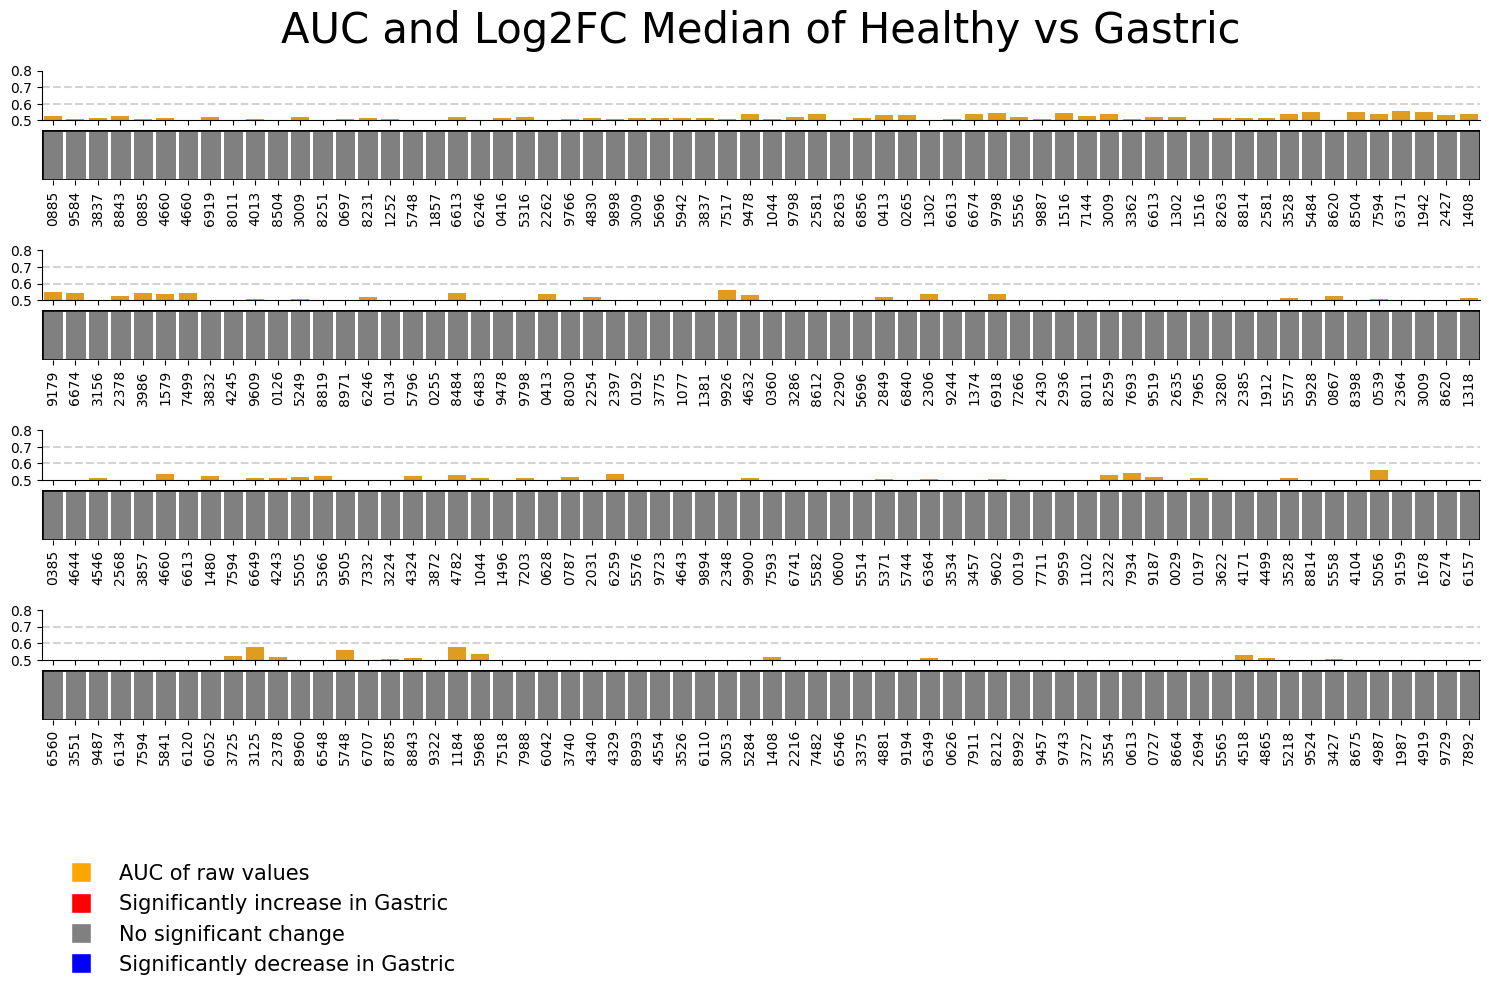

In [213]:
# data=result.sort_values(by=['nu_start','PlusMinus_Log2FC_'+p.split('-')[0]+'_'+p.split('-')[1],'ABS_Log2FC_'+p.split('-')[0]+'_'+p.split('-')[1]],ascending=True)
data=result.sort_values(by=['nu_start_order','Sig','Log2FC_+-','ABS Log2FC Median of '+p,],ascending=True)
# data=result
# cols=['Mean_F_Healthy','Mean_M_Healthy']
lst_PDAJ=list(data[data['PADJ of '+p.split(' vs ')[0]+' vs '+p.split(' vs ')[1]]<0.05]['FEATURES'])
set1=lst_PDAJ
# for n in [1,2,3,4,5,6,7,8]:
fig, axs = plt.subplots(12, 1, figsize=(15, 8))

for n in [1,2,3,4]:
        # A=data[cols][32*(n-1):32*n].T
        # A=data[['Mean of '+p.split(' vs ')[0],'Mean of '+p.split(' vs ')[1]]][64*(n-1):64*n].T
        # cmap = matplotlib.colormaps["Greens"]
        #         # Set the under color to white
        #         # cmap.set_under("yellow")
        #         # # Set the voer color to white
        #         # cmap.set_over("black")
        # # Set the background color
        # plt.figure(figsize=(15,1))
        # g = sb.heatmap(A,
        #                 # vmin=0,
        #                 # vmax=0.0125,
        #                 cmap=cmap,
        #                 # mask=mask_array,
        #                 yticklabels=True,
        #                 linewidths=2)
        # Set color of masked region
        # g.set_facecolor('gray')
        # if n==1: plt.title(col)
        # plt.title(col)

        lst_out=[]
        for i in list(np.arange(64*(n-1),64*n)):
                # if data['FEATURES'].iloc[i] not in lst_PDAJ:
                if data['FEATURES'].iloc[i] not in set(stats_fea['EM'][stats_fea['EM']['PADJ of '+p]<0.05]['FEATURES']):
                        lst_out+=[i-64*(n-1)]


        col = 'Log2FC Median of '+p.split(' vs ')[0]+' vs '+p.split(' vs ')[1]




        B = data[[col]][64*(n-1):64*n].T
        B.index=[B.columns[0][0]]
        mask_array = np.zeros((1, 64), dtype=bool)
        mask_array[:, lst_out] = True
        cmap = matplotlib.colormaps["seismic"]
        # Set the under color to white
        # cmap.set_under("yellow")
        # # Set the voer color to white
        # cmap.set_over("black")
        # Set the background color
        # plt.figure(figsize=(15,0.7))
        # cbar=True if n==1 else False
        g = sb.heatmap(B,
                        # vmin=-max([abs(min(data[col])),abs(max(data[col]))]),
                        # vmax=max([abs(min(data[col])),abs(max(data[col]))]),
                        vmin=-0.16,
                        vmax=0.16,
                        cmap=cmap,
                        mask=mask_array,
                        yticklabels=False,
                        linewidths=2,
                        # linecolor='black',
                        cbar=False,
                        # cbar_kws={'shrink': 1, 'fraction': 0.5, 'pad': 0.03},
                        # ax=axs[n-1])
                        # ax=axs[2*n-1])
                        ax=axs[(n-1)*3+1])
        # Set color of masked region
        g.set_facecolor('gray')
        # plt.title(col)ax.axhline(y=0, color='k',linewidth=10)
        g.axhline(y=0, color='k',linewidth=2)
        g.axhline(y=1, color='k',linewidth=2)
        g.axvline(x=0, color='k',linewidth=2)
        g.axvline(x=64, color='k',linewidth=2)
        for labe in g.get_xticklabels():
                text = 'EM_'+labe.get_text()
                #if text in overlap012:
                #        labe.set_color('magenta')
                #elif text in overlap01:
                #        labe.set_color('g')



        g1=sb.barplot(data=data[['FEATURES','AUCADJ of '+p]][64*(n-1):64*n],x='FEATURES',y='AUCADJ of '+p,
                #       ax=axs[2*n-2],
                      ax=axs[(n-1)*3],
                      palette=['orange'])
        g1.axhline(y=0.6,ls='--',color='lightgray')
        g1.axhline(y=0.7,ls='--',color='lightgray')
        g1.spines['top'].set_visible(False)
        g1.spines['right'].set_visible(False)
        g1.tick_params(axis='x', labelrotation=90,labelbottom=False)
        g1.set_xlabel('')
        g1.set_ylabel('')
        g1.set_yticks([0.5,0.6,0.7,0.8])
        # sb.despine(left=True)
        g1.set_xlim(left=-0.5)
        g1.set_ylim([0.5,0.8])

        if n==1: g1.set_title('AUC and '+col,pad=20,fontsize=30)

        axs[(n-1)*3+2].axis('off')
plt.tight_layout()
custom_lines = [Line2D([0], [0],marker='s', color='w', markerfacecolor='orange', markersize=15),
        Line2D([0], [0],marker='s', color='w', markerfacecolor='r', markersize=15),
                Line2D([0], [0],marker='s', color='w', markerfacecolor='gray', markersize=15),
                    Line2D([0], [0],marker='s', color='w', markerfacecolor='b', markersize=15),
                    ]
plt.legend(custom_lines,['AUC of raw values','Significantly increase in '+p.split(' vs ')[1],'No significant change','Significantly decrease in '+p.split(' vs ')[1]],loc='upper left',fontsize=15, bbox_to_anchor=(0, -1.3),frameon=False)
# plt.savefig('.\Figure\EM.png', dpi=600, bbox_inches='tight')
plt.subplots_adjust(hspace=0.2)

EM top sig

In [214]:
#stats_fea['EM'].sort_values(by='Log2FC Median of '+p).reset_index(drop=True).head(5)[['PADJ of '+PAIR[0],'PADJ of '+PAIR[1],'PADJ of '+PAIR[2]]]
stats_fea['EM'].sort_values(by='Log2FC Median of '+p).reset_index(drop=True).head(5)[['PADJ of '+PAIR[0]]]

,PADJ of Healthy vs Gastric
0,1
1,1
2,1
3,1
4,1


In [215]:
stats_fea['EM'].sort_values(by='Log2FC Median of '+p,ascending=False).reset_index(drop=True)

,FEATURES,Mean of Healthy,Mean of Gastric,Median of Healthy,Median of Gastric,SD of Healthy,SD of Gastric,CV% of Healthy,CV% of Gastric,Entropy of Healthy,Entropy of Gastric,Log2FC of Healthy vs Gastric,Log2FC Median of Healthy vs Gastric,P of Healthy vs Gastric,PADJ of Healthy vs Gastric,-log10(p-value) of Healthy vs Gastric,Distance of Healthy vs Gastric,AUC of Healthy vs Gastric,AUCADJ of Healthy vs Gastric
0,EM_TTTG_chr5:1877759-1878263,0.011212,0.013100,0.003984,0.009709,0.015425,0.016849,137.578628,128.621644,3.115133,3.253337,0.224487,1.285043,0.364047,1,0,0.001888,0.536797,0.536797
1,EM_TGTC_chr9:36986901-36987144,0.014320,0.011909,0.002786,0.006579,0.023736,0.015425,165.752086,129.516579,2.838838,3.155089,-0.265946,1.239913,0.961201,1,0,-0.002411,0.498028,0.501972
2,EM_TGTA_chr22:19767183-19767448,0.026842,0.044001,0.018182,0.040816,0.031936,0.037853,118.978193,86.028725,3.365496,3.946686,0.713055,1.166650,0.000531,1,0,0.017159,0.640452,0.640452
3,EM_TGTC_chr19:1210277-1210602,0.015199,0.017168,0.005988,0.013158,0.024836,0.019228,163.410435,112.002981,2.954859,3.686118,0.175752,1.135777,0.152450,1,0,0.001969,0.558009,0.558009
4,EM_TTGG_chr9:124016065-124016323,0.018067,0.023141,0.011236,0.021739,0.026684,0.021958,147.694052,94.887852,3.056487,3.915319,0.357076,0.952171,0.014233,1,0,0.005074,0.599375,0.599375
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16376,EM_TGGG_chr4:110612859-110613156,0.016595,0.017939,0.012500,0.008547,0.022642,0.034279,136.441436,191.088927,3.189252,2.651732,0.112347,-0.548437,0.736140,1,0,0.001344,0.486340,0.486340
16377,EM_TGTT_chr13:112782153-112782378,0.021221,0.020551,0.017241,0.011494,0.023587,0.026495,111.152659,128.926112,3.721618,3.519673,-0.046270,-0.584962,0.564180,1,0,-0.000670,0.476623,0.523377
16378,EM_TGGC_chr5:76953575-76953986,0.021020,0.018634,0.017241,0.011236,0.023432,0.024552,111.473505,131.755769,3.755044,3.117783,-0.173810,-0.617752,0.305855,1,0,-0.002386,0.458490,0.541510
16379,EM_TGCA_chr7:351427-351579,0.023995,0.017596,0.015385,0.008000,0.036851,0.022759,153.576719,129.343342,3.078751,3.197116,-0.447532,-0.943416,0.388361,1,0,-0.006400,0.465031,0.534969


In [216]:
EM_top=list(stats_fea['EM'].sort_values(by='Log2FC Median of '+p).reset_index(drop=True)['FEATURES'][0:5])+list(stats_fea['EM'].sort_values(by='Log2FC Median of '+p,ascending=False).reset_index(drop=True)['FEATURES'][0:5])
EM_top

['EM_TTTT_chr12:124457139-124457499',
 'EM_TGCA_chr7:351427-351579',
 'EM_TGGC_chr5:76953575-76953986',
 'EM_TGTT_chr13:112782153-112782378',
 'EM_TGGG_chr4:110612859-110613156',
 'EM_TTTG_chr5:1877759-1878263',
 'EM_TGTC_chr9:36986901-36987144',
 'EM_TGTA_chr22:19767183-19767448',
 'EM_TGTC_chr19:1210277-1210602',
 'EM_TTGG_chr9:124016065-124016323']

In [217]:
f='EM'
vector=[]
for s in list(DATA[f]['SampleID']):
    if s in list(sample_list['SampleID']):
        vector+=[True]
    else:
        vector+=[False]
data=DATA[f][vector]
labels=[]
for s in list(data['SampleID']):
    labels+=[list(sample_list[sample_list['SampleID']==s]['Label'])[0]]
data.insert(loc=1,column='Label',value=labels)
data.sort_values(by='SampleID',inplace=True)
data.reset_index(drop=True,inplace=True)
EM_plot1=data[['Label']+EM_top[0:5]].melt(id_vars="Label")
EM_plot1['x']=EM_plot1.apply(lambda r: r['variable'][3:]+'_'+str(int(r['Label'])),axis=1)
EM_plot1.sort_values(by='x',inplace=True)
EM_plot1

C:\Users\XN\AppData\Local\Temp\ipykernel_11628\4088704475.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.sort_values(by='SampleID',inplace=True)


,Label,variable,value,x
304,0.0,EM_TGCA_chr7:351427-351579,0.038462,TGCA_chr7:351427-351579_0
231,0.0,EM_TGCA_chr7:351427-351579,0.042553,TGCA_chr7:351427-351579_0
232,0.0,EM_TGCA_chr7:351427-351579,0.000000,TGCA_chr7:351427-351579_0
233,0.0,EM_TGCA_chr7:351427-351579,0.023256,TGCA_chr7:351427-351579_0
234,0.0,EM_TGCA_chr7:351427-351579,0.050000,TGCA_chr7:351427-351579_0
...,...,...,...,...
132,1.0,EM_TTTT_chr12:124457139-124457499,0.000000,TTTT_chr12:124457139-124457499_1
131,1.0,EM_TTTT_chr12:124457139-124457499,0.044444,TTTT_chr12:124457139-124457499_1
130,1.0,EM_TTTT_chr12:124457139-124457499,0.076923,TTTT_chr12:124457139-124457499_1
140,1.0,EM_TTTT_chr12:124457139-124457499,0.000000,TTTT_chr12:124457139-124457499_1


In [218]:
EM_plot2=data[['Label']+EM_top[5:10]].melt(id_vars="Label")
EM_plot2

,Label,variable,value
0,0.0,EM_TTTG_chr5:1877759-1878263,0.012579
1,0.0,EM_TTTG_chr5:1877759-1878263,0.000000
2,0.0,EM_TTTG_chr5:1877759-1878263,0.010870
3,0.0,EM_TTTG_chr5:1877759-1878263,0.015385
4,0.0,EM_TTTG_chr5:1877759-1878263,0.013158
...,...,...,...
1015,1.0,EM_TTGG_chr9:124016065-124016323,0.012658
1016,1.0,EM_TTGG_chr9:124016065-124016323,0.000000
1017,1.0,EM_TTGG_chr9:124016065-124016323,0.098361
1018,1.0,EM_TTGG_chr9:124016065-124016323,0.047619


Text(-1.1, -0.0065, '**  p-value < 0.05')

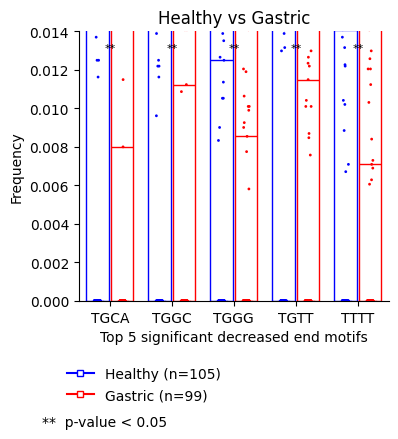

In [219]:
plt.figure(figsize=(4,3.5))
sb.boxplot(data=EM_plot1,y='value',x='variable',hue='Label',
           palette=['b','r'],hue_order=[0,1],fill=False,linewidth=1,
           flierprops=dict(marker='.',markersize=3),
           showfliers=False,legend=False,
           dodge=True,width=0.8,gap=0.1)
sb.stripplot(data=EM_plot1,y='value',x='variable',hue='Label',
             palette=['b','r'],hue_order=[0,1],
             marker='.',size=4,linewidth=0,legend=False,
             dodge=True
             )
plt.yticks(np.arange(0,0.016,0.002))
plt.ylim(0,0.014)
plt.xticks(ticks=[0,1,2,3,4],labels=[em.split('_')[1] for em in list(EM_plot1['variable'].unique())])
plt.ylabel('Frequency')
plt.xlabel('Top 5 significant decreased end motifs')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
custom_lines = [
                    # Line2D([0], [0], color='w', lw=0, marker='*', markersize=00),
                    Line2D([0], [0],marker='s', color='b', markerfacecolor='w', markersize=5),     
                    Line2D([0], [0],marker='s', color='r', markerfacecolor='w', markersize=5),
                    ]
# plt.legend(custom_lines,['p-value < 0.00001','Control (n=168)','Lung cancer (n=99)'],bbox_to_anchor=(1.3, .8),loc='center right',frameon=False)
# plt.legend(custom_lines,['Control (n=168)','Lung cancer (n=99)'],bbox_to_anchor=(1.05, .1),loc='center right',frameon=False)
tys=[p.split(' vs ')[0]+' (n='+str(len(SAMPLES[p.split(' vs ')[0]]))+')',
     p.split(' vs ')[1]+' (n='+str(len(SAMPLES[p.split(' vs ')[1]]))+')']
plt.legend(custom_lines,tys,frameon=False,loc='upper right', bbox_to_anchor=(0.5, -0.2))
plt.text(x=0,y=0.013,s='**',ha='center',fontsize=8)
plt.text(x=1,y=0.013,s='**',ha='center',fontsize=8)
plt.text(x=2,y=0.013,s='**',ha='center',fontsize=8)
plt.text(x=3,y=0.013,s='**',ha='center',fontsize=8)
plt.text(x=4,y=0.013,s='**',ha='center',fontsize=8)
plt.title(p)
plt.text(x=-1.1,y=-0.0065,s='**  p-value < 0.05')
# plt.text(x=4.7,y=0.007,s='**',fontsize=8)
# plt.savefig('.\Figure/EM_top5_1.png',dpi=600,bbox_inches='tight')

Text(-1.1, -0.0065, '**  p-value < 0.05')

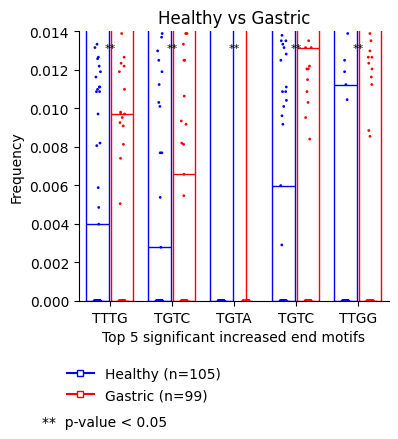

In [220]:
plt.figure(figsize=(4,3.5))
sb.boxplot(data=EM_plot2,y='value',x='variable',hue='Label',
           palette=['b','r'],hue_order=[0,1],fill=False,linewidth=1,
           flierprops=dict(marker='.',markersize=3),
           showfliers=False,
           dodge=True,width=0.8,gap=0.1)
sb.stripplot(data=EM_plot2,y='value',x='variable',hue='Label',
             palette=['b','r'],hue_order=[0,1],
             marker='.',size=4,linewidth=0,
             dodge=True
             )
plt.yticks(np.arange(0,0.016,0.002))
plt.ylim(0,0.014)
plt.xticks(ticks=[0,1,2,3,4],labels=[em.split('_')[1] for em in list(EM_plot2['variable'].unique())])
plt.ylabel('Frequency')
plt.xlabel('Top 5 significant increased end motifs')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
custom_lines = [
                    # Line2D([0], [0], color='w', lw=0, marker='*', markersize=00),
                    Line2D([0], [0],marker='s', color='b', markerfacecolor='w', markersize=5),     
                    Line2D([0], [0],marker='s', color='r', markerfacecolor='w', markersize=5),
                    ]
# plt.legend(custom_lines,['p_value < 0.00001','Healthy','Lung'],bbox_to_anchor=(1, .8),frameon=False)
# plt.legend(custom_lines,['Control \n(n=168)','Lung cancer \n(n=99)'],bbox_to_anchor=(1.45, .8),loc='center right',frameon=False)
tys=[p.split(' vs ')[0]+' (n='+str(len(SAMPLES[p.split(' vs ')[0]]))+')',
     p.split(' vs ')[1]+' (n='+str(len(SAMPLES[p.split(' vs ')[1]]))+')']
plt.legend(custom_lines,tys,frameon=False,loc='upper right', bbox_to_anchor=(0.5, -0.2))
plt.text(x=0,y=0.013,s='**',ha='center',fontsize=8)
plt.text(x=1,y=0.013,s='**',ha='center',fontsize=8)
plt.text(x=2,y=0.013,s='**',ha='center',fontsize=8)
plt.text(x=3,y=0.013,s='**',ha='center',fontsize=8)
plt.text(x=4,y=0.013,s='**',ha='center',fontsize=8)
# plt.text(x=4.7,y=0.0021,s='*****',fontsize=8)
# plt.savefig('.\Figure/EM_top5_2.png',dpi=600,bbox_inches='tight')
plt.title(p)
plt.text(x=-1.1,y=-0.0065,s='**  p-value < 0.05')

In [ ]:
EM_plot2=data[['Label']+['EM_AAGG']].melt(id_vars="Label")
EM_plot2

ValueError: The number of FixedLocator locations (1), usually from a call to set_ticks, does not match the number of labels (5).

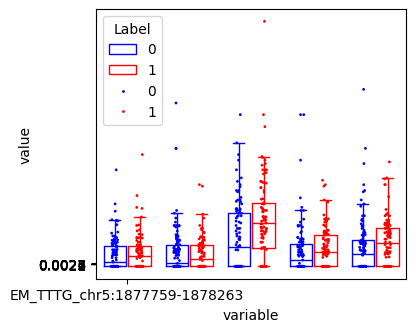

In [222]:
plt.figure(figsize=(4,3.5))
sb.boxplot(data=EM_plot2,y='value',x='variable',hue='Label',
           palette=['b','r'],hue_order=[0,1],fill=False,linewidth=1,
           flierprops=dict(marker='.',markersize=3),
           showfliers=False,
           dodge=True,width=0.8,gap=0.1)
sb.stripplot(data=EM_plot2,y='value',x='variable',hue='Label',
             palette=['b','r'],hue_order=[0,1],
             marker='.',size=4,linewidth=0,
             dodge=True
             )
plt.yticks(np.arange(0.0021,0.0027,0.0001))
# plt.ylim(0,0.014)
plt.xticks(ticks=[0,
               #    1,2,3,4
                  ],labels=[em.split('_')[1] for em in list(EM_plot2['variable'].unique())])
plt.ylabel('Frequency')
# plt.xlabel('Top 5 significant increased end motifs')
plt.xlabel('End motifs')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
custom_lines = [
                    # Line2D([0], [0], color='w', lw=0, marker='*', markersize=00),
                    Line2D([0], [0],marker='s', color='b', markerfacecolor='w', markersize=5),     
                    Line2D([0], [0],marker='s', color='r', markerfacecolor='w', markersize=5),
                    ]
# plt.legend(custom_lines,['p_value < 0.00001','Healthy','Lung'],bbox_to_anchor=(1, .8),frameon=False)
# plt.legend(custom_lines,['Control \n(n=168)','Lung cancer \n(n=99)'],bbox_to_anchor=(1.45, .8),loc='center right',frameon=False)
tys=[p.split(' vs ')[0],
     p.split(' vs ')[1]]
plt.legend(custom_lines,tys,frameon=False,loc='upper right', bbox_to_anchor=(0.5, -0.2))
# plt.text(x=0,y=0.013,s='**',ha='center',fontsize=8)
# plt.text(x=1,y=0.013,s='**',ha='center',fontsize=8)
# plt.text(x=2,y=0.013,s='**',ha='center',fontsize=8)
# plt.text(x=3,y=0.013,s='**',ha='center',fontsize=8)
# plt.text(x=4,y=0.013,s='**',ha='center',fontsize=8)
# plt.text(x=4.7,y=0.0021,s='*****',fontsize=8)
# plt.savefig('.\Figure/EM_top5_2.png',dpi=600,bbox_inches='tight')
plt.title(p)
# plt.text(x=-1.1,y=-0.0065,s='**  p-value < 0.05')

c:\Users\XN\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\XN\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\XN\AppData\Local\Temp\ipykernel_11628\649609783.py:30: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p_val = mannwhitneyu(healthy_vals, gastric_vals, alternative='two-sided')


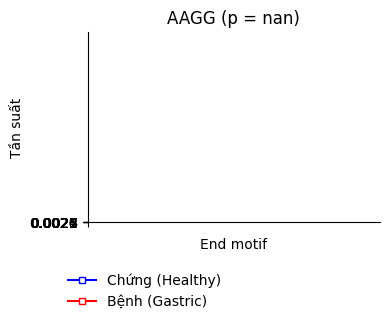

✅ Kết quả thống kê tần suất EM_AAGG:
Healthy  : Mean = nan, 95% CI = [nan, nan]
Gastric  : Mean = nan, 95% CI = [nan, nan]
📌 p-value (Mann–Whitney U test) = nan


In [223]:
import numpy as np
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt
import seaborn as sb
from matplotlib.lines import Line2D

# Hàm tính trung bình và khoảng tin cậy 95% (bootstrap)
def mean_ci(values, n_boot=1000, ci=0.95):
    means = []
    np.random.seed(42)
    for _ in range(n_boot):
        sample = np.random.choice(values, size=len(values), replace=True)
        means.append(np.mean(sample))
    lower = np.percentile(means, (1 - ci) / 2 * 100)
    upper = np.percentile(means, (1 + ci) / 2 * 100)
    return np.mean(values), (lower, upper)

# 👉 1. Lọc dữ liệu cho motif AAGG
df_aagg = EM_plot2[EM_plot2['variable'].str.contains("AAGG")]

# 👉 2. Tách theo nhóm
healthy_vals = df_aagg[df_aagg["Label"] == 0]["value"]
gastric_vals = df_aagg[df_aagg["Label"] == 1]["value"]

# 👉 3. Tính trung bình và 95%CI mỗi nhóm
mean_h, ci_h = mean_ci(healthy_vals)
mean_g, ci_g = mean_ci(gastric_vals)

# 👉 4. Kiểm định Mann–Whitney
stat, p_val = mannwhitneyu(healthy_vals, gastric_vals, alternative='two-sided')

# 👉 5. Vẽ biểu đồ
plt.figure(figsize=(4, 3.5))
sb.boxplot(data=df_aagg, y='value', x='variable', hue='Label',
           palette=['b', 'r'], hue_order=[0, 1], fill=False, linewidth=1,
           flierprops=dict(marker='.', markersize=3),
           showfliers=False, dodge=True, width=0.8, gap=0.1)
sb.stripplot(data=df_aagg, y='value', x='variable', hue='Label',
             palette=['b', 'r'], hue_order=[0, 1],
             marker='.', size=4, linewidth=0, dodge=True)

plt.yticks(np.arange(0.0021, 0.0027, 0.0001))
plt.xticks(ticks=[0], labels=[em.split('_')[1] for em in df_aagg['variable'].unique()])
plt.ylabel('Tần suất')
plt.xlabel('End motif')
plt.title(f"AAGG (p = {p_val:.4f})")
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# 👉 6. Thêm chú thích nhóm
custom_lines = [
    Line2D([0], [0], marker='s', color='b', markerfacecolor='w', markersize=5),
    Line2D([0], [0], marker='s', color='r', markerfacecolor='w', markersize=5),
]
tys = ['Chứng (Healthy)', 'Bệnh (Gastric)']
plt.legend(custom_lines, tys, frameon=False, loc='upper right', bbox_to_anchor=(0.5, -0.2))

# 👉 7. Hiển thị dấu sao nếu có ý nghĩa
if p_val < 0.05:
    plt.text(x=0, y=max(df_aagg['value']) + 0.00002, s='', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# 👉 8. In ra kết quả thống kê
print("✅ Kết quả thống kê tần suất EM_AAGG:")
print(f"Healthy  : Mean = {mean_h:.6f}, 95% CI = [{ci_h[0]:.6f}, {ci_h[1]:.6f}]")
print(f"Gastric  : Mean = {mean_g:.6f}, 95% CI = [{ci_g[0]:.6f}, {ci_g[1]:.6f}]")
print(f"📌 p-value (Mann–Whitney U test) = {p_val:.4g}")


In [229]:
# for

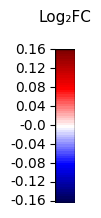

In [234]:
a=0.16
step1=0.005
Cbar=pd.DataFrame({u'log\u2082(fold change)':np.arange(a,-(a+step1),-step1)})
Cbar.index=[round(x,2) for x in Cbar[u'log\u2082(fold change)']]
plt.figure(figsize=(0.25,2))
Cbar_g=sb.heatmap(Cbar,
           cbar=False,
           cmap = matplotlib.colormaps["seismic"],
           xticklabels=False,
           )
labels=[round(i,2) for i in np.arange(a,-(a+0.04),-0.04)]
step=(len(Cbar)-1)/(len(labels)-1)
ticks=list(np.arange(0,len(Cbar),step))
plt.yticks(ticks=ticks,labels=labels)
plt.title(u'Log\u2082FC',pad=20,fontsize=11)
Cbar_g.axhline(y=0, color='k',linewidth=1)
Cbar_g.axhline(y=len(Cbar), color='k',linewidth=1)
Cbar_g.axvline(x=0, color='k',linewidth=1)
Cbar_g.axvline(x=1, color='k',linewidth=1)

FLEN distribution

In [235]:
f='FLEN'

In [236]:
#df=stats_fea[f]
#a=set(df[(df['PADJ of '+PAIR[0]]<0.05)&(df['Log2FC Median of '+PAIR[0]]>=0)]['FEATURES'])
#b=set(df[(df['PADJ of '+PAIR[1]]<0.05)&(df['Log2FC Median of '+PAIR[1]]>=0)]['FEATURES'])
#c=set(df[(df['PADJ of '+PAIR[2]]<0.05)&(df['Log2FC Median of '+PAIR[2]]>=0)]['FEATURES'])
#plt.figure(figsize=(3,3))
#matplotlib_venn.venn3_unweighted([a,b,c],[PAIR[0],PAIR[1],PAIR[2]])
#plt.title(f+" \nIncerease in cancer")
#overlap01=list(a&b-c)
#overlap012=list(a&b&c)

#df=stats_fea[f]
#a=set(df[(df['PADJ of '+PAIR[0]]<0.05)&(df['Log2FC Median of '+PAIR[0]]<0)]['FEATURES'])
#b=set(df[(df['PADJ of '+PAIR[1]]<0.05)&(df['Log2FC Median of '+PAIR[1]]<0)]['FEATURES'])
#c=set(df[(df['PADJ of '+PAIR[2]]<0.05)&(df['Log2FC Median of '+PAIR[2]]<0)]['FEATURES'])
#plt.figure(figsize=(3,3))
#matplotlib_venn.venn3_unweighted([a,b,c],[PAIR[0],PAIR[1],PAIR[2]])
#plt.title(f+" \nDecerease in cancer")
#overlap01=list(a&b-c)
#overlap012=list(a&b&c)

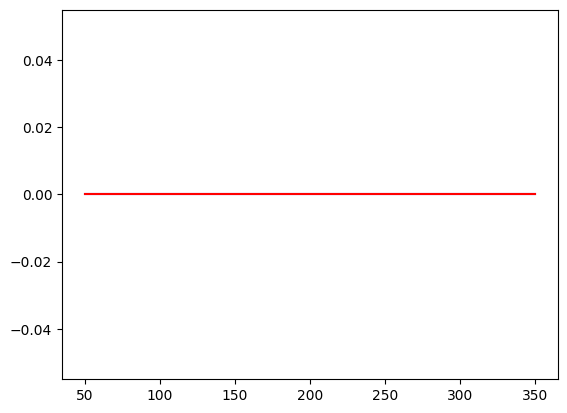

In [240]:
# Xác định trục x: từ 50 đến 350 (tổng cộng 301 điểm)
x = np.arange(50, 351) 

for g in list(G.keys()):
    # Lấy dữ liệu Median. Đảm bảo y1 chỉ chứa 301 giá trị tương ứng với x
    y1 = stats_fea['FLEN']['Median of ' + g].values 
    
    # Kiểm tra độ dài trước khi vẽ để tránh crash
    if len(y1) == len(x):
        sb.lineplot(x=x, y=y1, color=G[g], lw=1.5)
    else:
        # Nếu y1 bị thừa/thiếu, ta cần filter đúng các cột fragment length
        # Thường là lấy từ cột thứ 1 trở đi nếu col_start của bạn là 1
        y1_fixed = y1[:len(x)] 
        sb.lineplot(x=x, y=y1_fixed, color=G[g], lw=1.5)
        
    custom_lines += [Line2D([0], [0], color=G[g], lw=3)]

In [241]:
G={
    'Healthy':'b',
    #'Gastric_benign':'g',
    'Gastric':'r'
    }
plt.figure(figsize=(8,4))
custom_lines=[]
# x=np.arange(100,251,1)
x=np.arange(50,351,1)

for g in list(G.keys()):
    y1=stats_fea['FLEN']['Median of '+g]
    sb.lineplot(x=x,y=y1,color=G[g],lw=1.5)
    custom_lines += [Line2D([0], [0], color=G[g], lw=3)]

plt.axvline(x=150, color='gray', label='axvline - full height',ls=':')
tys=['Healthy (n='+str(len(SAMPLES['Healthy']))+')',
    # 'Gastric_benign (n='+str(len(SAMPLES['Gastric_benign']))+')',
     'Gastric (n='+str(len(SAMPLES['Gastric']))+')']
plt.legend(custom_lines,tys,bbox_to_anchor=(1, 1.05),frameon=False)
plt.ylabel('Frequency')
plt.xlabel('Fragment length (bp)')
# plt.xticks(np.arange(100,275,25))
plt.xlim(50,350)
plt.xticks(np.arange(50,375,25))
plt.yticks(np.arange(0,0.04,0.005))
# plt.title('Fragment length distribution')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
# plt.savefig('.\Figure/FLEN_50-350_distribution.png', dpi=600, bbox_inches='tight')
plt.grid(False)


ValueError: array length 301 does not match index length 16381

<Figure size 800x400 with 0 Axes>

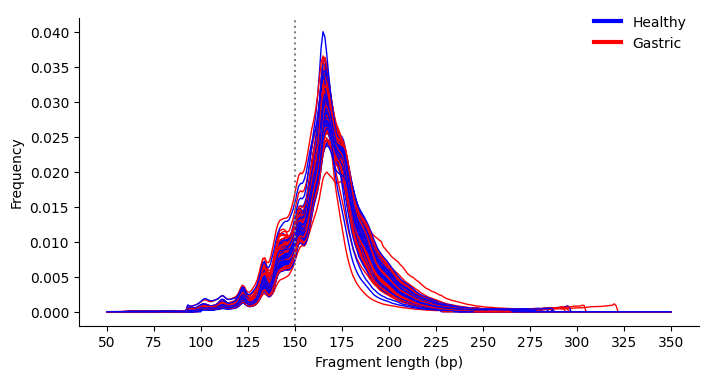

In [ ]:
G2={
    'Healthy':'blue',
#    'Gastric_benign':'g',
    'Gastric':'r'
    }
plt.figure(figsize=(8,4))
custom_lines=[Line2D([0], [0], color='b', lw=3),
#              Line2D([0], [0], color='g', lw=3),
              Line2D([0], [0], color='r', lw=3)]
vector=[]
for s in list(DATA[f]['SampleID']):
    if s in list(sample_list_all['SampleID']):
        vector+=[True]
    else:
        vector+=[False]
data=DATA[f][vector]
labels=[]
for s in list(data['SampleID']):
    labels+=[list(sample_list_all[sample_list_all['SampleID']==s]['Type'])[0]]
data.insert(loc=1,column='Type',value=labels)
data.sort_values(by='Type',ascending=False)
data.reset_index(drop=True,inplace=True)

x=np.arange(50,351,1)
for i in range(len(data)):
    g=data['Type'][i]
    y2=data.iloc[i,2:]
    sb.lineplot(x=x,y=y2,color=G2[g],lw=1)
#plt.legend(custom_lines,['Healthy','Gastric_benign','Gastric'],bbox_to_anchor=(1, 1.05),frameon=False)
plt.legend(custom_lines,['Healthy','Gastric'],bbox_to_anchor=(1, 1.05),frameon=False)
plt.ylabel('Frequency')
plt.xlabel('Fragment length (bp)')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.axvline(x=150, color='gray', label='axvline - full height',ls=':')
# sb.lineplot(x=x,y=stats_fea['FLEN100']['Mean of Lung'],color='b',lw=2)
# sb.lineplot(x=x,y=stats_fea['FLEN100']['Mean of Healthy'],color='r',lw=2)
# plt.title(fea['FLEN100']['SampleID'][r])
plt.yticks(np.arange(0,0.045,0.005))
plt.xticks(np.arange(50,375,25))
plt.grid(False)

In [ ]:
#df=pd.DataFrame(data[data['Type']=='Healthy'])[['SampleID','FLEN_200']].sort_values(by='FLEN_200')
#df


In [ ]:
#special_sample='KGDAAA09'
#G2={
#    'Healthy':'blue',
#    'Gastric_benign':'g',
#    'Gastric':'r'
#    }
#plt.figure(figsize=(8,4))
#custom_lines=[Line2D([0], [0], color='b', lw=3),
#              Line2D([0], [0], color='g', lw=3),
#              Line2D([0], [0], color='r', lw=3)]
#vector=[]
#for s in list(DATA[f]['SampleID']):
#    if s in list(sample_list_all['SampleID']):
#        vector+=[True]
#    else:
#        vector+=[False]
#data=DATA[f][vector]
#labels=[]
#for s in list(data['SampleID']):
#    labels+=[list(sample_list_all[sample_list_all['SampleID']==s]['Type'])[0]]
#data.insert(loc=1,column='Type',value=labels)
#data.sort_values(by='Type',ascending=False)
#data.reset_index(drop=True,inplace=True)

#x=np.arange(50,351,1)
#for i in range(len(data)):
#    g=data['Type'][i]
#    y2=data.iloc[i,2:]
#    if data['SampleID'][i]==special_sample:
#        sb.lineplot(x=x,y=y2,color=G2[g],lw=1)
#plt.legend(custom_lines,['Healthy','Gastric_benign','Gastric'],bbox_to_anchor=(1, 1.05),frameon=False)
#plt.ylabel('Frequency')
#plt.xlabel('Fragment length (bp)')
#plt.gca().spines['top'].set_visible(False)
#plt.gca().spines['right'].set_visible(False)
#plt.axvline(x=150, color='gray', label='axvline - full height',ls=':')
# sb.lineplot(x=x,y=stats_fea['FLEN100']['Mean of Lung'],color='b',lw=2)
# sb.lineplot(x=x,y=stats_fea['FLEN100']['Mean of Healthy'],color='r',lw=2)
#plt.title(special_sample)
#plt.yticks(np.arange(0,0.045,0.005))
#plt.xticks(np.arange(50,375,25))

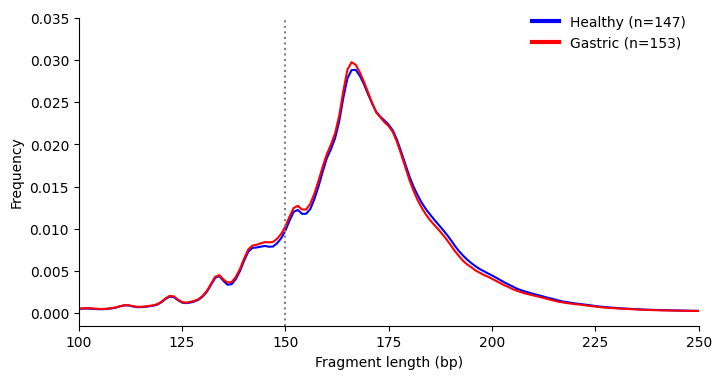

In [ ]:
G={
    'Healthy':'b',
#    'Gastric_benign':'g',
    'Gastric':'r'
    }
plt.figure(figsize=(8,4))
custom_lines=[]
# x=np.arange(100,251,1)
x=np.arange(50,351,1)

for g in list(G.keys()):
    y1=stats_fea['FLEN']['Median of '+g]
    sb.lineplot(x=x,y=y1,color=G[g],lw=1.5)
    custom_lines += [Line2D([0], [0], color=G[g], lw=3)]

plt.axvline(x=150, color='gray', label='axvline - full height',ls=':')
tys=['Healthy (n='+str(len(SAMPLES['Healthy']))+')',
#     'Gastric_benign (n='+str(len(SAMPLES['Gastric_benign']))+')',
     'Gastric (n='+str(len(SAMPLES['Gastric']))+')']
plt.legend(custom_lines,tys,bbox_to_anchor=(1, 1.05),frameon=False)
plt.ylabel('Frequency')
plt.xlabel('Fragment length (bp)')
# plt.xticks(np.arange(100,275,25))
plt.xticks(np.arange(50,375,25))
plt.xlim(100,250)
plt.yticks(np.arange(0,0.04,0.005))
# plt.title('Fragment length distribution')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
# plt.savefig('.\Figure/FLEN_50-350_distribution.png', dpi=600, bbox_inches='tight')
plt.grid(False)

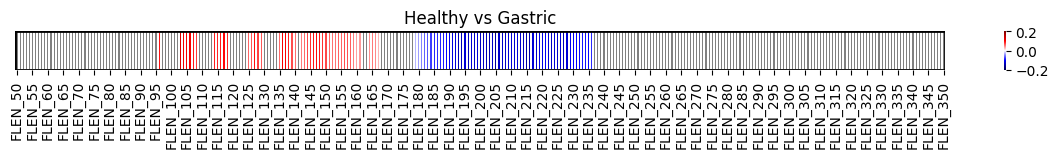

In [ ]:
for p in PAIR:
    df=stats_fea['FLEN']
    set_Overlap=df[df['PADJ of '+p]<=0.05]['FEATURES']
    # df.index=df.apply(lambda row: row['FEATURES'].split('_')[1],axis=1)
    df.index=df.apply(lambda row: row['FEATURES'],axis=1)
    lst_in_out=[]
    for i in range(len(df['FEATURES'])):
        if df['FEATURES'].iloc[i] not in list(set_Overlap):
            lst_in_out+=[i]
    len(lst_in_out)

    A = df[['Log2FC Median of '+p]].T
    mask_array = np.zeros((1, df.shape[0]), dtype=bool)
    mask_array[:, lst_in_out] = True
    cmap = matplotlib.colormaps["seismic"]
    # Set the under color to white
    # cmap.set_under("yellow")
    # # Set the voer color to white
    # cmap.set_over("black")
    # Set the background color
    plt.figure(figsize=(15,0.5))
    g = sb.heatmap(A,
                    # vmin=-max([abs(min(df[col])),abs(max(df[col]))]),
                    # vmax=max([abs(min(df[col])),abs(max(df[col]))]),
                   vmin=-0.2,vmax=0.2,
                   cmap=cmap, mask=mask_array,yticklabels=False,
                   cbar=True,linewidths=0.003,linecolor='w',
                #    cbar_kws={'label': u'log\u2082(fold change)'}
                )
    # Set color of masked region
    g.set_facecolor('gray')
    g.axhline(y=0, color='k',linewidth=2)
    g.axhline(y=1, color='k',linewidth=2)
    g.axvline(x=0, color='k',linewidth=2)
    g.axvline(x=301, color='k',linewidth=2)
    g.set_title(p)
    # colorbar = g.collections[0].colorbar
    # colorbar.set_label('Colorbar Title', fontsize=12, labelpad=10)
    # colorbar.ax.invert_yaxis()
    # colorbar.set_label(u'log\u2082(fold change)', fontsize=12, rotation=0)
    # plt.title(p)
    # plt.savefig('.\Figure/FLEN_50-350_heatmap.png', dpi=600, bbox_inches='tight')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from matplotlib.colors import TwoSlopeNorm

# Đọc dữ liệu
flen_df = pd.read_csv(r"C:\Users\XN\du-an-dung-chung\HNG_5_GW + 450 region_20260302\WG\FLEN.csv")
meta_df = pd.read_excel(r"C:\Users\XN\du-an-dung-chung\HNG_5_GW + 450 region_20260302\WG\Metadata.xlsx", sheet_name="QC", nrows=1000)

# Ghép bảng theo SampleID
merged_df = pd.merge(flen_df, meta_df, on='SampleID', how='inner')

# Xác định cột fragment lengths từ 50 đến 350
flen_cols = [str(i) for i in range(50, 351)]



In [ ]:
# Re-import necessary libraries after code execution state reset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from matplotlib.colors import TwoSlopeNorm

# Re-load the files after reset
flen_df = pd.read_csv(r"C:\Users\XN\du-an-dung-chung\HNG_5_GW + 450 region_20260302\WG\FLEN.csv")
meta_df = pd.read_excel(r"C:\Users\XN\du-an-dung-chung\HNG_5_GW + 450 region_20260302\WG\Metadata.xlsx", sheet_name="QC", nrows=1000)

# Merge on SampleID
merged_df = pd.merge(flen_df, meta_df, on='SampleID', how='inner')

# Determine fragment length columns
flen_cols = [str(i) for i in range(50, 351)]

# Filter necessary columns for "Kích thước khối u"
merged_df = merged_df[['SampleID', 'Kích thước khối u'] + flen_cols].dropna()
merged_df = merged_df.rename(columns={'Kích thước khối u': 'TumorSize'})

# Remove rows with '-' value in TumorSize
merged_df = merged_df[merged_df['TumorSize'] != '-']

# Melt data from wide to long format
flen_long = merged_df.melt(id_vars=['SampleID', 'TumorSize'], value_vars=flen_cols,
                           var_name='Length', value_name='Count')
flen_long['Length'] = flen_long['Length'].astype(int)

# Normalize by total per sample
flen_long['Total'] = flen_long.groupby('SampleID')['Count'].transform('sum')
flen_long['Freq'] = flen_long['Count'] / flen_long['Total']

# Calculate mean frequency by TumorSize and Length
grouped = flen_long.groupby(['TumorSize', 'Length'])['Freq'].mean().reset_index()

# Line plot
plt.figure(figsize=(10, 5))
sns.set(style='whitegrid')
palette = sns.color_palette(['#e41a1c', '#377eb8'])

for idx, (group, group_data) in enumerate(grouped.groupby('TumorSize')):
    plt.plot(group_data['Length'], group_data['Freq'], label=group, linewidth=2.5, color=palette[idx % len(palette)])

plt.axvline(x=150, color='gray', linestyle='--', linewidth=1)
plt.xlabel('Fragment length (bp)')
plt.ylabel('Frequency')
plt.title('Fragment Length Distribution by Tumor Size')
plt.legend()
plt.tight_layout()
plt.show()

# Heatmap of log2FC with larger font and Arial
fig, ax = plt.subplots(figsize=(14, 2.5))
cmap = sns.diverging_palette(220, 20, as_cmap=True)
norm = TwoSlopeNorm(vmin=-0.2, vcenter=0, vmax=0.2)

# Đặt font mặc định là Arial
plt.rcParams['font.family'] = 'Arial'

# Vẽ các cột biểu diễn log2FC
for i, row in stat_df.iterrows():
    color = cmap(norm(row['log2FC']))
    ax.bar(i, 1, color=color, edgecolor='black', linewidth=0.2)

# Gán nhãn trục x với cỡ chữ lớn hơn
flen_labels = [f"FLEN_{l}" for l in stat_df['Length']]
ax.set_xticks(np.arange(len(flen_labels))[::10])
ax.set_xticklabels(flen_labels[::10], rotation=90, fontsize=14)
ax.set_yticks([])

# Tiêu đề biểu đồ heatmap với tên nhóm và cỡ lớn
ax.set_title(f"{ref_group} vs {test_group}", fontsize=16, fontname='Arial')

# Thanh màu (colorbar) với cỡ chữ lớn hơn
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='vertical', fraction=0.02, pad=0.01)
cbar.set_label('log2FC', fontsize=14)

# Tiêu đề tổng thể
plt.title('Fragment Length Distribution by Tumor Size (<=5cm vs >5cm)',
          fontsize=16, fontname='Arial')

plt.tight_layout()
plt.show()

KeyError: "['Kích thước khối u'] not in index"

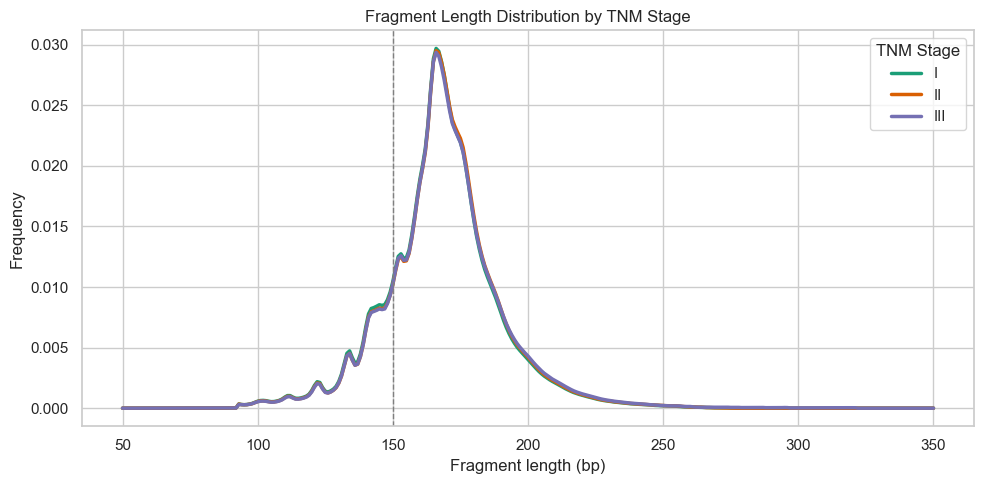

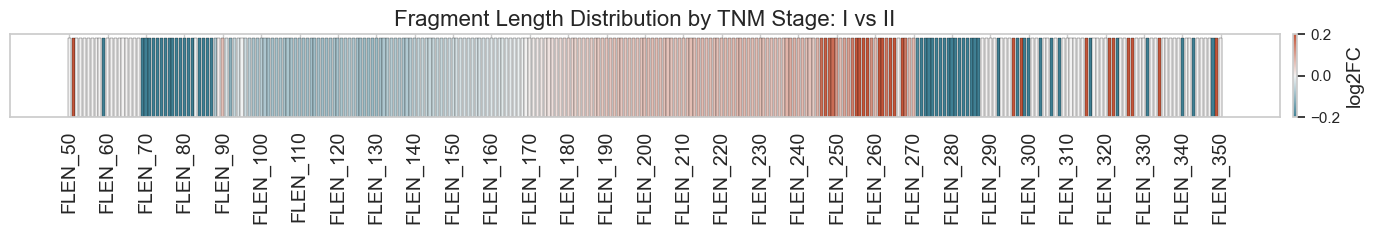

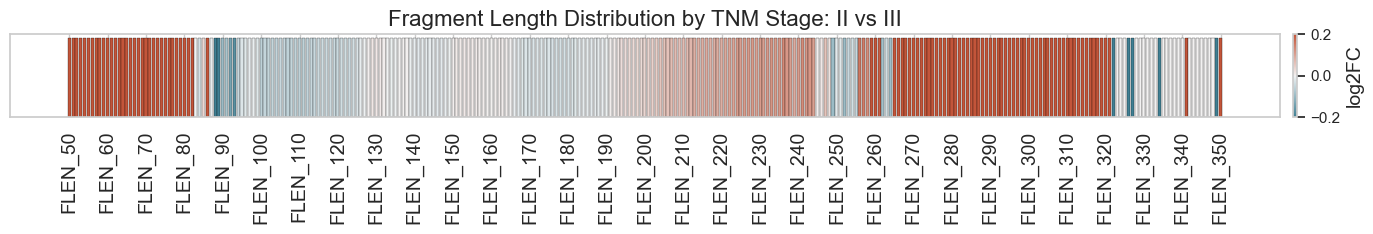

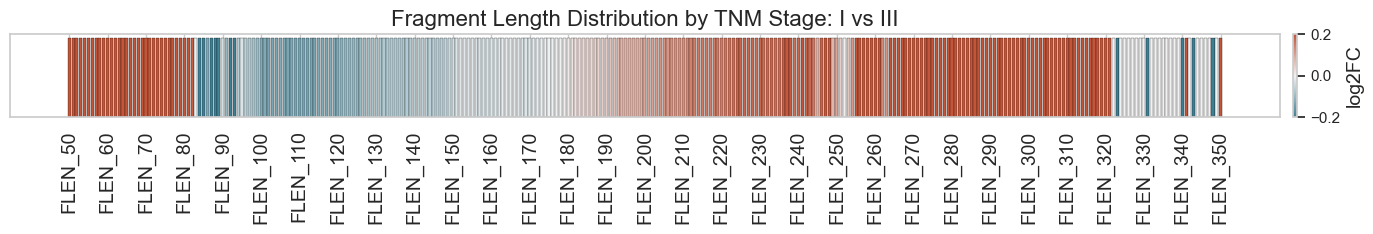

In [ ]:
import itertools

# Dữ liệu ban đầu giống như trước, chỉ thay thế cột phân nhóm
merged_df = pd.merge(flen_df, meta_df, on='SampleID', how='inner')
flen_cols = [str(i) for i in range(50, 351)]
merged_df = merged_df[['SampleID', 'Giai đoạn theo TNM'] + flen_cols].dropna()
merged_df = merged_df.rename(columns={'Giai đoạn theo TNM': 'TNMStage'})

# Loại bỏ giá trị không hợp lệ
merged_df = merged_df[merged_df['TNMStage'].isin(['I', 'II', 'III'])]

# Long format
flen_long = merged_df.melt(id_vars=['SampleID', 'TNMStage'], value_vars=flen_cols,
                           var_name='Length', value_name='Count')
flen_long['Length'] = flen_long['Length'].astype(int)
flen_long['Total'] = flen_long.groupby('SampleID')['Count'].transform('sum')
flen_long['Freq'] = flen_long['Count'] / flen_long['Total']

# Biểu đồ đường tổng quát theo TNM
grouped = flen_long.groupby(['TNMStage', 'Length'])['Freq'].mean().reset_index()

plt.figure(figsize=(10, 5))
palette = sns.color_palette(['#1b9e77', '#d95f02', '#7570b3'])
for idx, (stage, data) in enumerate(grouped.groupby('TNMStage')):
    plt.plot(data['Length'], data['Freq'], label=stage, linewidth=2.5, color=palette[idx])
plt.axvline(x=150, color='gray', linestyle='--', linewidth=1)
plt.xlabel('Fragment length (bp)')
plt.ylabel('Frequency')
plt.title('Fragment Length Distribution by TNM Stage')
plt.legend(title="TNM Stage")
plt.tight_layout()
plt.show()

# Heatmap log2FC cho từng cặp: I vs II, II vs III, I vs III
pair_results = {}

# Cài đặt font mặc định là Arial
plt.rcParams['font.family'] = 'Arial'

for ref_stage, test_stage in [('I', 'II'), ('II', 'III'), ('I', 'III')]:
    # Pivot dữ liệu
    pivot_df = grouped[grouped['TNMStage'].isin([ref_stage, test_stage])] \
        .pivot(index='Length', columns='TNMStage', values='Freq').fillna(0)

    epsilon = 1e-9
    log2fc = np.log2((pivot_df[test_stage] + epsilon) / (pivot_df[ref_stage] + epsilon))

    p_values = []
    log2fc_values = []

    for length in range(50, 351):
        ref_vals = flen_long[(flen_long['TNMStage'] == ref_stage) & (flen_long['Length'] == length)]['Freq'].dropna()
        test_vals = flen_long[(flen_long['TNMStage'] == test_stage) & (flen_long['Length'] == length)]['Freq'].dropna()
        if len(ref_vals) > 0 and len(test_vals) > 0:
            stat, p = mannwhitneyu(test_vals, ref_vals, alternative='two-sided')
            lfc = np.log2((test_vals.mean() + epsilon) / (ref_vals.mean() + epsilon))
        else:
            p = np.nan
            lfc = 0
        p_values.append(p)
        log2fc_values.append(lfc)

    stat_df = pd.DataFrame({
        'Length': list(range(50, 351)),
        'log2FC': log2fc_values,
        'p-value': p_values
    })
    stat_df['Significance'] = ['p < 0.05' if p < 0.05 else 'n.s.' for p in stat_df['p-value']]
    pair_results[f"{ref_stage} vs {test_stage}"] = stat_df

    # Vẽ heatmap
    fig, ax = plt.subplots(figsize=(14, 2.5))
    cmap = sns.diverging_palette(220, 20, as_cmap=True)
    norm = TwoSlopeNorm(vmin=-0.2, vcenter=0, vmax=0.2)

    for i, row in stat_df.iterrows():
        color = cmap(norm(row['log2FC']))
        ax.bar(i, 1, color=color, edgecolor='black', linewidth=0.2)

    flen_labels = [f"FLEN_{l}" for l in stat_df['Length']]
    ax.set_xticks(np.arange(len(flen_labels))[::10])
    ax.set_xticklabels(flen_labels[::10], rotation=90, fontsize=14)
    ax.set_yticks([])

    # Tiêu đề biểu đồ heatmap với Arial và kích thước lớn
    ax.set_title(f"Fragment Length Distribution by TNM Stage: {ref_stage} vs {test_stage}", fontsize=16, fontname='Arial')

    # Thêm colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, orientation='vertical', fraction=0.02, pad=0.01)
    cbar.set_label('log2FC', fontsize=14)

    plt.tight_layout()
    plt.show()


NFP distribution

In [ ]:
f='NFP'

In [ ]:
#df=stats_fea[f]
#a=set(df[(df['PADJ of '+PAIR[0]]<0.05)&(df['Log2FC Median of '+PAIR[0]]>=0)]['FEATURES'])
#b=set(df[(df['PADJ of '+PAIR[1]]<0.05)&(df['Log2FC Median of '+PAIR[1]]>=0)]['FEATURES'])
#c=set(df[(df['PADJ of '+PAIR[2]]<0.05)&(df['Log2FC Median of '+PAIR[2]]>=0)]['FEATURES'])
#plt.figure(figsize=(3,3))
#matplotlib_venn.venn3_unweighted([a,b,c],[PAIR[0],PAIR[1],PAIR[2]])
#plt.title(f+" \nIncerease in cancer")
#overlap01=list(a&b-c)
#overlap012=list(a&b&c)

#df=stats_fea[f]
#a=set(df[(df['PADJ of '+PAIR[0]]<0.05)&(df['Log2FC Median of '+PAIR[0]]<0)]['FEATURES'])
#b=set(df[(df['PADJ of '+PAIR[1]]<0.05)&(df['Log2FC Median of '+PAIR[1]]<0)]['FEATURES'])
#c=set(df[(df['PADJ of '+PAIR[2]]<0.05)&(df['Log2FC Median of '+PAIR[2]]<0)]['FEATURES'])
#plt.figure(figsize=(3,3))
#matplotlib_venn.venn3_unweighted([a,b,c],[PAIR[0],PAIR[1],PAIR[2]])
#plt.title(f+" \nDecerease in cancer")
#overlap01=list(a&b-c)
#overlap012=list(a&b&c)

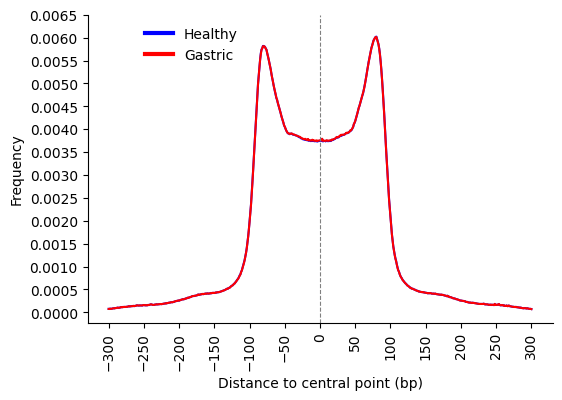

In [ ]:
G={
    'Healthy':'b',
    #'Gastric_benign':'g',
    'Gastric':'r'
    }
plt.figure(figsize=(6,4))
custom_lines=[]
x=np.arange(-300,301,1)

for g in list(G.keys()):
    y1=stats_fea['NFP']['Median of '+g]
    ax=sb.lineplot(x=x,y=y1,color=G[g])
    custom_lines += [Line2D([0], [0], color=G[g], lw=3)]

plt.legend(custom_lines,G,bbox_to_anchor=(0.35, 1.),frameon=False)
plt.ylabel('Frequency')
plt.yticks(np.arange(0,0.007,0.0005))
plt.xlabel('Distance to central point (bp)')
plt.xticks(np.arange(-300,350,50),rotation=90)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.axvline(x=0, color='gray', label='axvline - full height',ls='--',lw=0.8)

# plt.axvline(x=-90, ymin=0.0035/0.0070, ymax=0.0065/0.0070,ls='-',lw=0.8,color='gray')
# plt.axvline(x=90, ymin=0.0035/0.0070, ymax=0.0065/0.0070,ls='-',lw=0.8,color='gray')
# plt.axhline(y=0.0035-0.00011, xmin=(300-90+9)/601, xmax=(300+90-7)/601,ls='-',lw=0.8,color='gray')
# plt.axhline(y=0.0065, xmin=(300-90+9)/601, xmax=(300+90-7)/601,ls='-',lw=0.8,color='gray')

# plt.savefig('.\Figure/NFP_distribution.png', dpi=600, bbox_inches='tight')
plt.grid(False)

In [ ]:
G2={
    'Healthy':'blue',
    'Gastric':'r',
    #'Gastric_benign':'g',   
    }
plt.figure(figsize=(8,4))
custom_lines=[Line2D([0], [0], color='b', lw=3),
              Line2D([0], [0], color='r', lw=3),
              Line2D([0], [0], color='g', lw=3)
              ]
vector=[]
for s in list(DATA[f]['SampleID']):
    if s in list(sample_list_all['SampleID']):
        vector+=[True]
    else:
        vector+=[False]
data=DATA[f][vector]
labels=[]
for s in list(data['SampleID']):
    labels+=[list(sample_list_all[sample_list_all['SampleID']==s]['Type'])[0]]
data.insert(loc=1,column='Type',value=labels)
data.sort_values(by='Type',ascending=False)

order=[]
for s in list(data['SampleID']):
    if list(data[data['SampleID']==s]['Type'])[0]=='Healthy':
        order+=[0]
    elif list(data[data['SampleID']==s]['Type'])[0]=='Gastric':
        order+=[1]
    #elif list(data[data['SampleID']==s]['Type'])[0]=='Gastric_benign':
    #    order+=[2]
data.insert(loc=1,column='order',value=order)
data.sort_values(by='order',ascending=True,inplace=True)          
data.reset_index(drop=True,inplace=True)

x=np.arange(-300,301,1)

# for g in list(G.keys()):
#     y1=stats_fea['NFP']['Mean of '+g]
#     ax=sb.lineplot(x=x,y=y1,color=G[g],lw=2)
#     custom_lines += [Line2D([0], [0], color=G[g], lw=3)]
for i in range(len(data)):
    g=data['Type'][i]
    y2=data.iloc[i,3:]
    sb.lineplot(x=x,y=y2,color=G2[g],lw=0.5)
# sb.lineplot(x=x,y=stats_fea['NFP']['Mean of Lung'],color='b',lw=2)
# sb.lineplot(x=x,y=stats_fea['NFP']['Mean of Healthy'],color='r',lw=2)

#plt.legend(custom_lines,['Healthy','Gastric','Gastric_benign'],bbox_to_anchor=(1, 1.05),frameon=False)
plt.legend(custom_lines,['Healthy','Gastric'],bbox_to_anchor=(1, 1.05),frameon=False)
plt.ylabel('Frequency')
plt.yticks(np.arange(0,0.008,0.001))
plt.xlabel('Distance to central point (bp)')
plt.xticks(np.arange(-300,350,50),rotation=90)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.axvline(x=0, color='gray', label='axvline - full height',ls='--',lw=0.8)

# plt.axvline(x=-90, ymin=0.0035/0.0070, ymax=0.0065/0.0070,ls='-',lw=0.8,color='gray')
# plt.axvline(x=90, ymin=0.0035/0.0070, ymax=0.0065/0.0070,ls='-',lw=0.8,color='gray')
# plt.axhline(y=0.0035-0.00011, xmin=(300-90+9)/601, xmax=(300+90-7)/601,ls='-',lw=0.8,color='gray')
# plt.axhline(y=0.0065, xmin=(300-90+9)/601, xmax=(300+90-7)/601,ls='-',lw=0.8,color='gray')
# square=patches.Rectangle((0.003, 0.003), 0.006, 0.006, edgecolor='orange', facecolor='none')
# ax.add_patch(square)
# plt.title('Nucleosome footprint partern')
# plt.savefig('.\Figure/NFP_distribution_all.png', dpi=600, bbox_inches='tight')

C:\Users\XN\AppData\Local\Temp\ipykernel_728\3160854511.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.sort_values(by='order',ascending=True,inplace=True)


ValueError: array length 601 does not match index length 301

<Figure size 800x400 with 0 Axes>

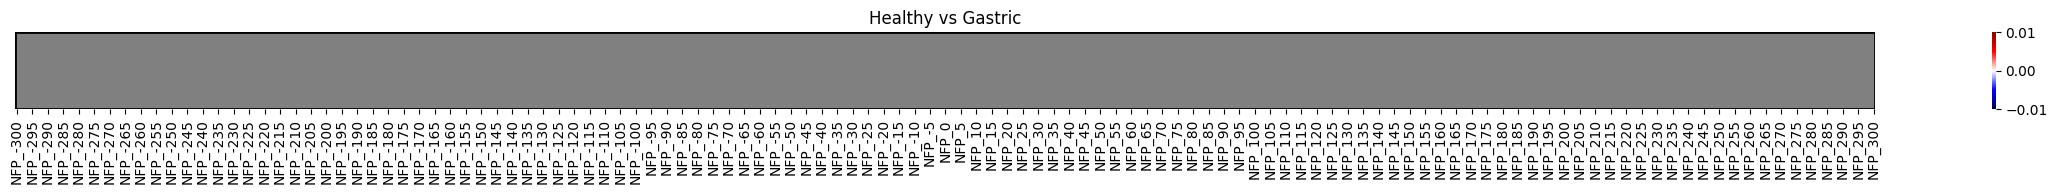

In [ ]:
for p in PAIR:
    df=stats_fea['NFP']
    set_Overlap=df[df['PADJ of '+p]<=0.05]['FEATURES']
    # df.index=df.apply(lambda row: row['FEATURES'].split('_')[1],axis=1)
    df.index=df.apply(lambda row: row['FEATURES'],axis=1)
    lst_in_out=[]
    for i in range(len(df['FEATURES'])):
        if df['FEATURES'].iloc[i] not in list(set_Overlap):
            lst_in_out+=[i]
    len(lst_in_out)

    A = df[['Log2FC Median of '+p]].T
    mask_array = np.zeros((1, df.shape[0]), dtype=bool)
    mask_array[:, lst_in_out] = True
    cmap = matplotlib.colormaps["seismic"]
    # Set the under color to white
    # cmap.set_under("yellow")
    # # Set the voer color to white
    # cmap.set_over("black")
    # Set the background color
    plt.figure(figsize=(30,1))
    g = sb.heatmap(A,
                    # vmin=-max([abs(min(df[col])),abs(max(df[col]))]),
                    # vmax=max([abs(min(df[col])),abs(max(df[col]))]),
                   vmin=-0.01,vmax=0.01,
                   cmap=cmap, mask=mask_array,yticklabels=False,
                   cbar=True,linewidths=0.00,linecolor='w',
                #    cbar_kws={'label': u'log\u2082(fold change)'}
                )
    # Set color of masked region
    g.set_facecolor('gray')
    g.axhline(y=0, color='k',linewidth=2)
    g.axhline(y=1, color='k',linewidth=2)
    g.axvline(x=0, color='k',linewidth=2)
    g.axvline(x=601, color='k',linewidth=2)
    g.set_title(p)
    # colorbar = g.collections[0].colorbar
    # colorbar.set_label('Colorbar Title', fontsize=12, labelpad=10)
    # colorbar.ax.invert_yaxis()
    # colorbar.set_label(u'log\u2082(fold change)', fontsize=12, rotation=0)
    # plt.title(p)
    # plt.savefig('.\Figure/FLEN_50-350_heatmap.png', dpi=600, bbox_inches='tight')

In [ ]:
df=pd.DataFrame(data[data['Type']=='Healthy'])[['SampleID','NFP_75']].sort_values(by='NFP_75')
df

KeyError: "['NFP_75'] not in index"

C:\Users\XN\AppData\Local\Temp\ipykernel_2928\1935119429.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.sort_values(by='order',ascending=True,inplace=True)


Text(0.5, 1.0, 'KGDAAA09')

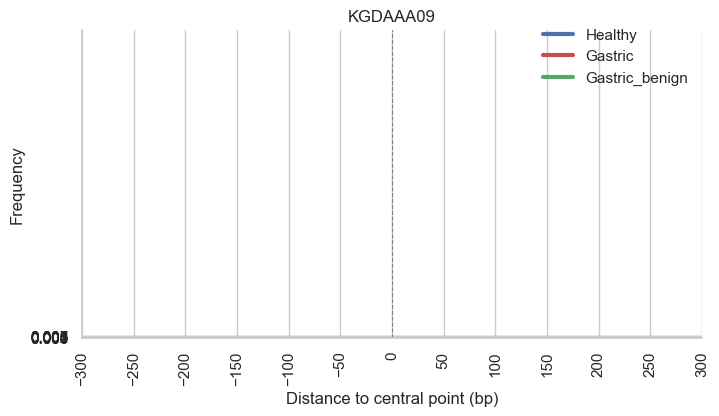

In [ ]:
special_sample='KGDAAA09'
G2={
    'Healthy':'blue',
    'Gastric':'r',
    'Gastric_benign':'g'
    }
plt.figure(figsize=(8,4))
custom_lines=[Line2D([0], [0], color='b', lw=3),
              Line2D([0], [0], color='r', lw=3),
              Line2D([0], [0], color='g', lw=3)
              ]
vector=[]
for s in list(DATA[f]['SampleID']):
    if s in list(sample_list_all['SampleID']):
        vector+=[True]
    else:
        vector+=[False]
data=DATA[f][vector]
labels=[]
for s in list(data['SampleID']):
    labels+=[list(sample_list_all[sample_list_all['SampleID']==s]['Type'])[0]]
data.insert(loc=1,column='Type',value=labels)
data.sort_values(by='Type',ascending=False)

order=[]
for s in list(data['SampleID']):
    if list(data[data['SampleID']==s]['Type'])[0]=='Healthy':
        order+=[0]
    elif list(data[data['SampleID']==s]['Type'])[0]=='Gastric':
        order+=[1]
    elif list(data[data['SampleID']==s]['Type'])[0]=='Gastric_benign':
        order+=[2]
data.insert(loc=1,column='order',value=order)
data.sort_values(by='order',ascending=True,inplace=True)          
data.reset_index(drop=True,inplace=True)

x=np.arange(-300,301,1)

# for g in list(G.keys()):
#     y1=stats_fea['NFP']['Mean of '+g]
#     ax=sb.lineplot(x=x,y=y1,color=G[g],lw=2)
#     custom_lines += [Line2D([0], [0], color=G[g], lw=3)]
for i in range(len(data)):
    g=data['Type'][i]
    y2=data.iloc[i,3:]
    if data['SampleID'][i]==special_sample:
        sb.lineplot(x=x,y=y2,color=G2[g],lw=0.5)
# sb.lineplot(x=x,y=stats_fea['NFP']['Mean of Lung'],color='b',lw=2)
# sb.lineplot(x=x,y=stats_fea['NFP']['Mean of Healthy'],color='r',lw=2)

plt.legend(custom_lines,['Healthy','Gastric','Gastric_benign'],bbox_to_anchor=(1, 1.05),frameon=False)
plt.ylabel('Frequency')
plt.yticks(np.arange(0,0.008,0.001))
plt.xlabel('Distance to central point (bp)')
plt.xticks(np.arange(-300,350,50),rotation=90)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.axvline(x=0, color='gray', label='axvline - full height',ls='--',lw=0.8)

# plt.axvline(x=-90, ymin=0.0035/0.0070, ymax=0.0065/0.0070,ls='-',lw=0.8,color='gray')
# plt.axvline(x=90, ymin=0.0035/0.0070, ymax=0.0065/0.0070,ls='-',lw=0.8,color='gray')
# plt.axhline(y=0.0035-0.00011, xmin=(300-90+9)/601, xmax=(300+90-7)/601,ls='-',lw=0.8,color='gray')
# plt.axhline(y=0.0065, xmin=(300-90+9)/601, xmax=(300+90-7)/601,ls='-',lw=0.8,color='gray')
# square=patches.Rectangle((0.003, 0.003), 0.006, 0.006, edgecolor='orange', facecolor='none')
# ax.add_patch(square)
plt.title(special_sample)
# plt.savefig('.\Figure/NFP_distribution_all.png', dpi=600, bbox_inches='tight')

CNA bins

In [ ]:
def vectorcolor(p,f):
    data_split=stats_fea[f]
    # data_concatenate=stats_fea['All_features']
    col_PADJ='PADJ of '+p
    col_L2FC='Log2FC of '+p
    cols=[]
    for i in list(data_split.iloc[:,0]):
        PADJ_split=data_split[data_split[data_split.columns[0]]==i][col_PADJ].reset_index(drop=True)[0]
        # PADJ_concatenate=data_concatenate[data_concatenate[data_concatenate.columns[0]]==i][col_PADJ].reset_index(drop=True)[0]

        L2FC_split=data_split[data_split[data_split.columns[0]]==i][col_L2FC].reset_index(drop=True)[0]

        if L2FC_split <0 and PADJ_split<=0.05:
            cols.append('b')
        elif L2FC_split >=0 and PADJ_split<=0.05:
            cols.append('red')
        elif PADJ_split>0.05:
            cols.append('gray')
    return cols

In [ ]:
#Tạo position cho chromosome
Chromosome=[]
for i in range(len(stats_fea['CNA'])):
    chromosome=int(stats_fea['CNA']['FEATURES'].iloc[i].split(":")[0].split("_")[1])
    Chromosome+=[chromosome]
results=pd.DataFrame({'Chromosome':Chromosome})
results=results['Chromosome'].value_counts().sort_index()
results=pd.DataFrame({'Count':results})
lst=[]
for i in range(len(results)):
    # lst+=[sum(results.iloc[:i,0])+round(results.iloc[i,0]/2,0)]
    lst+=[sum(results.iloc[:i+1,0])]
results['Vline']=lst

Position=[]
for i in range(1,23,1):
    if i ==1:
        posit=int(results['Vline'][i]/4)
    else:
        posit=int((results['Vline'][i]+results['Vline'][i-1])/2)
    Position+=[posit]
results['Position']=Position
results

,Count,Vline,Position
Chromosome,,,
1,159,159,39
2,162,321,240
3,148,469,395
4,140,609,539
5,136,745,677
6,120,865,805
7,111,976,920
8,108,1084,1030
9,83,1167,1125


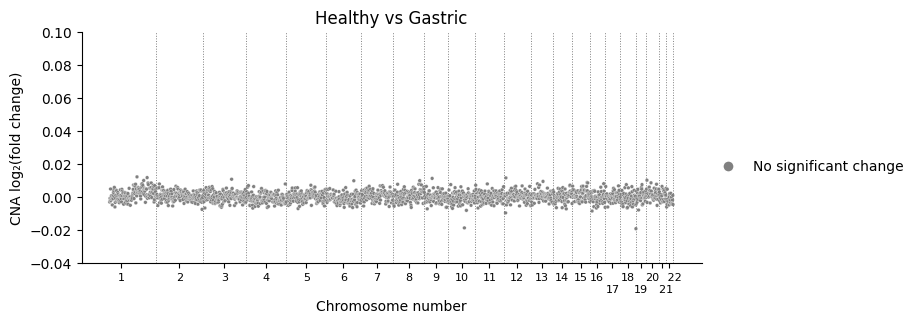

In [ ]:
f='CNA'
custom_lines = [
    # Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=8,mec='w'),
                Line2D([0], [0],marker='o', color='w', markerfacecolor='gray', markersize=8,mec='w'),
                    # Line2D([0], [0],marker='o', color='w', markerfacecolor='b', markersize=8,mec='w'),
                    ]
data=stats_fea[f]
for p in PAIR:
    col_log='Log2FC of '+p
    if col_log not in data.columns:
        col_log='Distance of '+p
    col_PADJ='PADJ of '+p 
    cols=vectorcolor(p,f)

    plt.figure(figsize=(8, 3))
    # plt.figure(figsize=(6/1.4,3/1.5))
    xlabels=['1','2','3','4','5','6','7','8','9','10','11','12','13','14','15','16','\n17','18','\n19','20','\n  21','   22']
    x=data['FEATURES']
    y=data[col_log]

    for vline in results['Vline']:
        plt.axvline(x=vline, color='gray', label='axvline - full height',ls=':',lw=0.7)
        
    sb.scatterplot(x=x,y=y,c=cols,s=7,edgecolor='w')
    # lst_name_show=["CNA_10:135000001-135534747"]
    # region_name = list(data['FEATURES'])
    # for i, txt in enumerate(region_name):
    #     if txt in lst_name_show:
    #         plt.text(x[i],y[i],txt,fontsize=8,color='red')
   
    
    plt.xticks(ticks=results['Position'],labels=xlabels,fontsize=8)
    plt.yticks(np.arange(-0.04,0.1,0.02))
    plt.xlabel('Chromosome number')
    plt.ylabel('CNA '+u'log\u2082(fold change)')
    plt.title(p)
    # n_gain=pd.DataFrame(cols)[0].value_counts()['red']
    # n_loss=pd.DataFrame(cols)[0].value_counts()['b']
    # plt.legend(custom_lines,['CNA gain (n='+str(n_gain)+')','No significant change','CNA loss (n='+str(n_loss)+')'],loc='upper left', bbox_to_anchor=(1, 0.5),frameon=False)
    plt.legend(custom_lines,['No significant change'],loc='upper left', bbox_to_anchor=(1, 0.5),frameon=False)
    # plt.legend(custom_lines,['CNA gain (n='+str(n_gain)+')','No significant change','CNA loss (n='+str(n_loss)+')'],loc='upper right', bbox_to_anchor=(0.5, -0.3),frameon=False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    # plt.savefig('.\Figure\CNA_bins.png', dpi=600, bbox_inches='tight')

SCNA bins

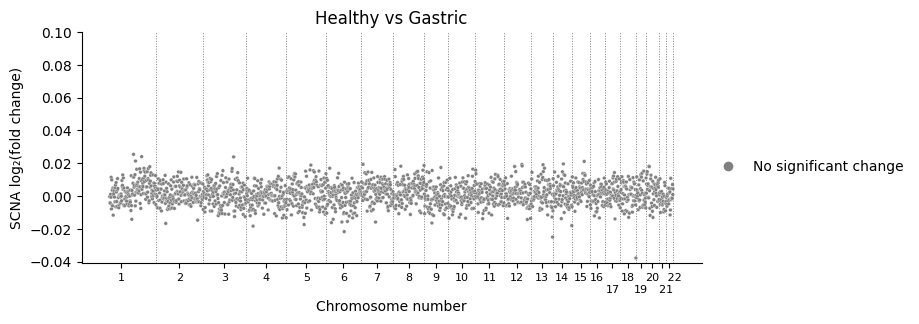

In [ ]:
f='SCNA'
custom_lines = [
    # Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=8,mec='w'),
                Line2D([0], [0],marker='o', color='w', markerfacecolor='gray', markersize=8,mec='w'),
                    # Line2D([0], [0],marker='o', color='w', markerfacecolor='b', markersize=8,mec='w'),
                    ]
data=stats_fea[f]
for p in PAIR:
    col_log='Log2FC of '+p
    if col_log not in data.columns:
        col_log='Distance of '+p
    col_PADJ='PADJ of '+p 
    cols=vectorcolor(p,f)

    plt.figure(figsize=(8, 3))
    # plt.figure(figsize=(6/1.4,3/1.5))
    xlabels=['1','2','3','4','5','6','7','8','9','10','11','12','13','14','15','16','\n17','18','\n19','20','\n  21','   22']
    x=data['FEATURES']
    y=data[col_log]

    for vline in results['Vline']:
        plt.axvline(x=vline, color='gray', label='axvline - full height',ls=':',lw=0.7)
        
    sb.scatterplot(x=x,y=y,c=cols,s=7,edgecolor='w')
    # lst_name_show=["CNA_10:135000001-135534747"]
    # region_name = list(data['FEATURES'])
    # for i, txt in enumerate(region_name):
    #     if txt in lst_name_show:
    #         plt.text(x[i],y[i],txt,fontsize=8,color='red')
   
    
    plt.xticks(ticks=results['Position'],labels=xlabels,fontsize=8)
    plt.yticks(np.arange(-0.04,0.1,0.02))
    plt.xlabel('Chromosome number')
    plt.ylabel('SCNA '+u'log\u2082(fold change)')
    plt.title(p)
    # n_gain=pd.DataFrame(cols)[0].value_counts()['red']
    # n_loss=pd.DataFrame(cols)[0].value_counts()['b']
    # plt.legend(custom_lines,['CNA gain (n='+str(n_gain)+')','No significant change','CNA loss (n='+str(n_loss)+')'],loc='upper left', bbox_to_anchor=(1, 0.5),frameon=False)
    plt.legend(custom_lines,['No significant change'],loc='upper left', bbox_to_anchor=(1, 0.5),frameon=False)
    # plt.legend(custom_lines,['CNA gain (n='+str(n_gain)+')','No significant change','CNA loss (n='+str(n_loss)+')'],loc='upper right', bbox_to_anchor=(0.5, -0.3),frameon=False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    # plt.savefig('.\Figure\CNA_bins.png', dpi=600, bbox_inches='tight')

RATIOSL

In [ ]:
#Tạo position cho chromosome
GWFP=stats_fea['RATIOSL']
GWFP=GWFP[~GWFP['FEATURES'].str.contains('X|Y', case=False, na=False)]
Chromosome=[]
for i in range(len(GWFP)):
    chromosome=GWFP['FEATURES'].iloc[i].split("_")[1].split(':')[0]
    chromosome=int(chromosome)
    Chromosome+=[chromosome]
results=pd.DataFrame({'Chromosome':Chromosome})
results=results['Chromosome'].value_counts().sort_index()
results=pd.DataFrame({'Count':results})
lst=[]
for i in range(len(results)):
    # lst+=[sum(results.iloc[:i,0])+round(results.iloc[i,0]/2,0)]
    lst+=[sum(results.iloc[:i+1,0])]
results['Vline']=lst

Position=[]
for i in range(1,23,1):
    if i ==1:
        posit=int(results['Vline'][i]/4)
    else:
        posit=int((results['Vline'][i]+results['Vline'][i-1])/2)
    Position+=[posit]
results['Position']=Position
results

,Count,Vline,Position
Chromosome,,,
1,230,230,57
2,241,471,350
3,196,667,569
4,190,857,762
5,178,1035,946
6,165,1200,1117
7,158,1358,1279
8,144,1502,1430
9,117,1619,1560



📊 Healthy vs Gastric:
  Healthy - Mean: 0.1830, Median: 0.1792, Min: 0.1581, Max: 0.3410
  Gastric - Mean: 0.1949, Median: 0.1909, Min: 0.1692, Max: 0.3534
  🔥 Mann-Whitney U test: p = 7.962e-235
  ✅ Kết luận: Có sự khác biệt có ý nghĩa thống kê giữa 2 nhóm.


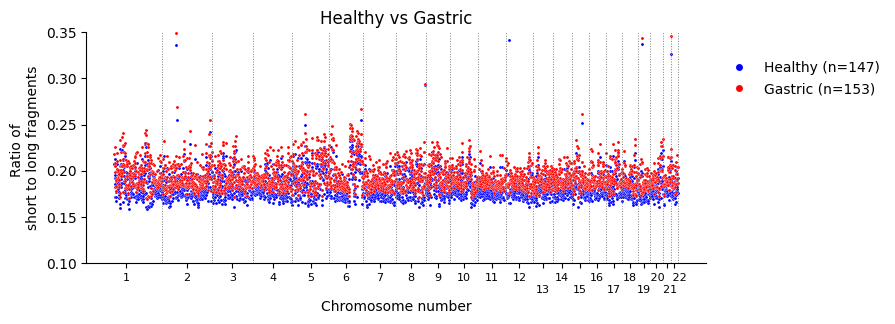

In [ ]:
G['Nongastric']='cyan'
for p in PAIR:
    col1='Mean of '+p.split(" vs ")[0]
    col2='Mean of '+p.split(" vs ")[1]
    # col_log='Log2FC_'+p 
    # col_PADJ='PADJ_'+p 
    # vectorcolorCNA=[]
    # for i in range(len(stat_GWFP_ratio)):
    #     if stat_CNA[col_PADJ].iloc[i] >= 0.05:
    #         vectorcolorCNA+=['gray']
    #     elif stat_CNA[col_log].iloc[i] > 0:
    #         vectorcolorCNA+=['red']
    #     else:
    #         vectorcolorCNA+=['blue']
    plt.figure(figsize=(8,3))
    for vline in results['Vline']:
        plt.axvline(x=vline, color='gray', label='axvline - full height',ls=':',lw=0.7)
    xlabels=['1','2','3','4','5','6','7','8','9','10','11','12','\n13','14','\n15','16','\n17','18','\n19',' 20','\n  21','   22']
    sb.scatterplot(x=GWFP['FEATURES'],y=GWFP[col1],c=G[p.split(" vs ")[0]],s=5,edgecolor='w')
    sb.scatterplot(x=GWFP['FEATURES'],y=GWFP[col2],c=G[p.split(" vs ")[1]],s=5,edgecolor='w')
    plt.xticks(ticks=results['Position'],labels=xlabels,fontsize=8)
    plt.yticks(np.arange(0.1,0.4,0.05))
    plt.ylim((0.1,0.35))
    plt.xlabel('Chromosome number')
    plt.ylabel('Ratio of \nshort to long fragments')
    plt.title(p)
    #custom_lines = [Line2D([0], [0],marker='o',color='w', markerfacecolor='b', markersize=6,mec='w'),
    #               Line2D([0], [0],marker='o', color='w', markerfacecolor='g', markersize=6,mec='w'),
    #               Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=6,mec='w'),
    #               Line2D([0], [0],marker='o', color='w', markerfacecolor='cyan', markersize=6,mec='w')]
    custom_lines = [Line2D([0], [0],marker='o',color='w', markerfacecolor='b', markersize=6,mec='w'),
                    Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=6,mec='w')]
    # plt.legend(custom_lines,[p.split(" vs ")[1],p.split(" vs ")[0]],loc='upper right', bbox_to_anchor=(0.5, -0.3),frameon=False)
    # plt.legend(custom_lines,[p.split(" vs ")[1],p.split(" vs ")[0]],loc='upper left', bbox_to_anchor=(1, 0.5),frameon=False)
    #plt.legend(custom_lines,['Healthy (n='+str(len(healthy))+')','Gastric_benign (n='+str(len(gastric_benign))+')','Gastric (n='+str(len(gastric))+')','Nongastric (n='+str(len(Nongastric))+')'],loc='center right',bbox_to_anchor=(1.3, 0.8),frameon=True,edgecolor='w')
    plt.legend(custom_lines,['Healthy (n='+str(len(healthy))+')','Gastric (n='+str(len(gastric))+')'],loc='center right',bbox_to_anchor=(1.3, 0.8),frameon=True,edgecolor='w')
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    # plt.savefig('.\Figure\FLEN_ratio_short_total.png', dpi=600, bbox_inches='tight')

    group1_values = GWFP[col1].dropna()
    group2_values = GWFP[col2].dropna()
     # ✅ Sau khi vẽ, in thống kê và kết luận
    mean1, mean2 = group1_values.mean(), group2_values.mean()
    median1, median2 = group1_values.median(), group2_values.median()
    min1, min2 = group1_values.min(), group2_values.min()
    max1, max2 = group1_values.max(), group2_values.max()

    print(f"\n📊 {p}:")
    print(f"  {p.split(' vs ')[0]} - Mean: {mean1:.4f}, Median: {median1:.4f}, Min: {min1:.4f}, Max: {max1:.4f}")
    print(f"  {p.split(' vs ')[1]} - Mean: {mean2:.4f}, Median: {median2:.4f}, Min: {min2:.4f}, Max: {max2:.4f}")

    # ✅ Kiểm định thống kê giữa 2 nhóm
    stat, p_value = mannwhitneyu(group1_values, group2_values, alternative='two-sided')
    print(f"  🔥 Mann-Whitney U test: p = {p_value:.4g}")

    # ✅ Kết luận
    if p_value < 0.05:
        print("  ✅ Kết luận: Có sự khác biệt có ý nghĩa thống kê giữa 2 nhóm.")
    else:
        print("  ❌ Kết luận: Không có sự khác biệt có ý nghĩa thống kê giữa 2 nhóm.")



RATIOST

In [ ]:
#Tạo position cho chromosome
GWFP=stats_fea['RATIOST']
GWFP=GWFP[~GWFP['FEATURES'].str.contains('X|Y', case=False, na=False)]
Chromosome=[]
for i in range(len(GWFP)):
    chromosome=GWFP['FEATURES'].iloc[i].split("_")[1].split(':')[0]
    chromosome=int(chromosome)
    Chromosome+=[chromosome]
results=pd.DataFrame({'Chromosome':Chromosome})
results=results['Chromosome'].value_counts().sort_index()
results=pd.DataFrame({'Count':results})
lst=[]
for i in range(len(results)):
    # lst+=[sum(results.iloc[:i,0])+round(results.iloc[i,0]/2,0)]
    lst+=[sum(results.iloc[:i+1,0])]
results['Vline']=lst

Position=[]
for i in range(1,23,1):
    if i ==1:
        posit=int(results['Vline'][i]/4)
    else:
        posit=int((results['Vline'][i]+results['Vline'][i-1])/2)
    Position+=[posit]
results['Position']=Position
# results


📊 Healthy vs Gastric:
  Healthy - Mean: 0.1539, Median: 0.1513, Min: 0.1359, Max: 0.2534
  Gastric - Mean: 0.1620, Median: 0.1593, Min: 0.1439, Max: 0.2598
  🔥 Mann-Whitney U test: p = 1.599e-221
  ✅ Kết luận: Có sự khác biệt có ý nghĩa thống kê giữa 2 nhóm.


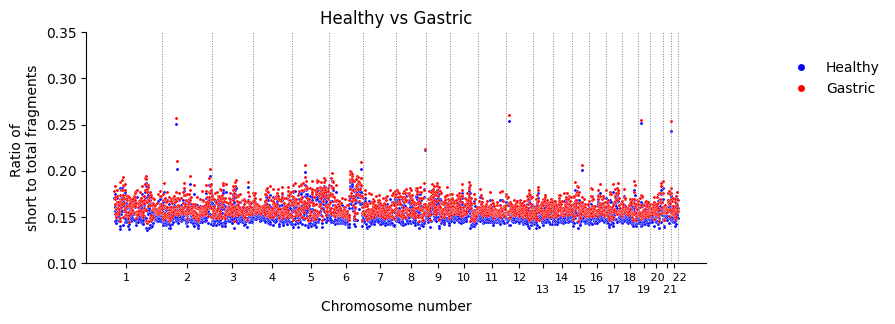

In [ ]:
G['Nongastric']='cyan'
for p in PAIR:
    col1='Mean of '+p.split(" vs ")[0]
    col2='Mean of '+p.split(" vs ")[1]
    # col_log='Log2FC_'+p 
    # col_PADJ='PADJ_'+p 
    # vectorcolorCNA=[]
    # for i in range(len(stat_GWFP_ratio)):
    #     if stat_CNA[col_PADJ].iloc[i] >= 0.05:
    #         vectorcolorCNA+=['gray']
    #     elif stat_CNA[col_log].iloc[i] > 0:
    #         vectorcolorCNA+=['red']
    #     else:
    #         vectorcolorCNA+=['blue']
    plt.figure(figsize=(8,3))
    for vline in results['Vline']:
        plt.axvline(x=vline, color='gray', label='axvline - full height',ls=':',lw=0.7)
    xlabels=['1','2','3','4','5','6','7','8','9','10','11','12','\n13','14','\n15','16','\n17','18','\n19',' 20','\n  21','   22']
    sb.scatterplot(x=GWFP['FEATURES'],y=GWFP[col1],c=G[p.split(" vs ")[0]],s=5,edgecolor='w')
    sb.scatterplot(x=GWFP['FEATURES'],y=GWFP[col2],c=G[p.split(" vs ")[1]],s=5,edgecolor='w')
    plt.xticks(ticks=results['Position'],labels=xlabels,fontsize=8)
    plt.yticks(np.arange(0.1,0.4,0.05))
    plt.ylim((0.1,0.35))
    plt.xlabel('Chromosome number')
    plt.ylabel('Ratio of \nshort to total fragments')
    plt.title(p)
    #custom_lines = [Line2D([0], [0],marker='o',color='w', markerfacecolor='b', markersize=6,mec='w'),
    #               Line2D([0], [0],marker='o', color='w', markerfacecolor='g', markersize=6,mec='w'),
    #               Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=6,mec='w'),
    #               Line2D([0], [0],marker='o', color='w', markerfacecolor='cyan', markersize=6,mec='w')]
    custom_lines = [Line2D([0], [0],marker='o',color='w', markerfacecolor='b', markersize=6,mec='w'),
                    Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=6,mec='w')]
    # plt.legend(custom_lines,[p.split(" vs ")[1],p.split(" vs ")[0]],loc='upper right', bbox_to_anchor=(0.5, -0.3),frameon=False)
    # plt.legend(custom_lines,[p.split(" vs ")[1],p.split(" vs ")[0]],loc='upper left', bbox_to_anchor=(1, 0.5),frameon=False)
    #plt.legend(custom_lines,['Healthy (n='+str(len(healthy))+')','Gastric_benign (n='+str(len(gastric_benign))+')','Gastric (n='+str(len(gastric))+')','Nongastric (n='+str(len(Nongastric))+')'],loc='center right',bbox_to_anchor=(1.3, 0.8),frameon=True,edgecolor='w')
    plt.legend(custom_lines,['Healthy','Gastric'],loc='center right',bbox_to_anchor=(1.3, 0.8),frameon=True,edgecolor='w')
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    # plt.savefig('.\Figure\FLEN_ratio_short_total.png', dpi=600, bbox_inches='tight')

    group1_values = GWFP[col1].dropna()
    group2_values = GWFP[col2].dropna()
     # ✅ Sau khi vẽ, in thống kê và kết luận
    mean1, mean2 = group1_values.mean(), group2_values.mean()
    median1, median2 = group1_values.median(), group2_values.median()
    min1, min2 = group1_values.min(), group2_values.min()
    max1, max2 = group1_values.max(), group2_values.max()

    print(f"\n📊 {p}:")
    print(f"  {p.split(' vs ')[0]} - Mean: {mean1:.4f}, Median: {median1:.4f}, Min: {min1:.4f}, Max: {max1:.4f}")
    print(f"  {p.split(' vs ')[1]} - Mean: {mean2:.4f}, Median: {median2:.4f}, Min: {min2:.4f}, Max: {max2:.4f}")

    # ✅ Kiểm định thống kê giữa 2 nhóm
    stat, p_value = mannwhitneyu(group1_values, group2_values, alternative='two-sided')
    print(f"  🔥 Mann-Whitney U test: p = {p_value:.4g}")

    # ✅ Kết luận
    if p_value < 0.05:
        print("  ✅ Kết luận: Có sự khác biệt có ý nghĩa thống kê giữa 2 nhóm.")
    else:
        print("  ❌ Kết luận: Không có sự khác biệt có ý nghĩa thống kê giữa 2 nhóm.")

In [ ]:
# ✅ LẤY DANH SÁCH CÁC CỘT TÍNH TOÁN (KHÔNG GỒM CỘT PHÂN NHÓM)
#columns = [col for col in df.columns if col != 'Giai đoạn theo TNM']

# -----------------------------
# TÍNH LOG2FC & P-VALUE
# -----------------------------
#results = []
#for feature in columns:
#    group_I = df[df['Giai đoạn theo TNM'] == 'I'][feature]
#    group_II = df[df['Giai đoạn theo TNM'] == 'II'][feature]

#   mean_I = group_I.mean()
#    mean_II = group_II.mean()
#    log2fc = np.log2((mean_II + 1e-9) / (mean_I + 1e-9))
#    _, p_val = ttest_ind(group_II, group_I, equal_var=False)

#    results.append({
#        'FEATURE': feature,
#        'Log2FC': log2fc,
#        'p-value': p_val
#    })

#results_df = pd.DataFrame(results)

# -----------------------------
# VẼ HEATMAP (GIỮ ĐÚNG VỊ TRÍ, CHỈ HIỂN THỊ P < 0.05)
# -----------------------------
#sorted_all = results_df.sort_values(by='p-value', ascending=True).reset_index(drop=True)
#log2fc_vals = sorted_all['Log2FC'].values
#features = sorted_all['FEATURE'].values
#pvals = sorted_all['p-value'].values

#masked_vals = [val if p < 0.05 else np.nan for val, p in zip(log2fc_vals, pvals)]
#masked_df = pd.DataFrame([masked_vals], columns=features, index=['Log₂FC'])

#plt.figure(figsize=(12, 2))
#sb.heatmap(masked_df,
#           cmap='seismic', center=0,
#           vmin=-0.16, vmax=0.16,
#           linewidths=1,
#           xticklabels=True, yticklabels=True,
#           cbar_kws={'label': 'Log₂FC'})
#plt.xticks(rotation=90)
#plt.title('Log₂FC heatmap (features with p < 0.05 only)', fontsize=12)
#plt.tight_layout()
#plt.show()

In [ ]:
stats_fea['RATIOSL']

,FEATURES,Mean of Healthy,Mean of Gastric,Median of Healthy,Median of Gastric,SD of Healthy,SD of Gastric,CV% of Healthy,CV% of Gastric,Entropy of Healthy,...,Log2FC of Healthy vs Gastric,Log2FC Median of Healthy vs Gastric,P of Healthy vs Gastric,PADJ of Healthy vs Gastric,Round_Mean of Healthy,Round_Mean of Gastric,-log10(p-value) of Healthy vs Gastric,Distance of Healthy vs Gastric,AUC of Healthy vs Gastric,AUCADJ of Healthy vs Gastric
0,RATIOSL_1:1-1000000,0.206924,0.218288,0.201655,0.212575,0.038478,0.044537,18.595472,20.402749,3.402389,...,0.077133,0.076085,0.014535,0.016566,0.21,0.22,1.780790,0.011364,0.581610,0.581610
1,RATIOSL_1:100000001-101000000,0.191824,0.204818,0.187060,0.198440,0.034556,0.045356,18.014292,22.144468,3.340145,...,0.094562,0.085200,0.005251,0.012045,0.19,0.20,1.919211,0.012994,0.593215,0.593215
2,RATIOSL_1:10000001-11000000,0.195383,0.207914,0.192054,0.203260,0.034978,0.043093,17.902340,20.726299,3.306388,...,0.089678,0.081814,0.005294,0.012045,0.20,0.21,1.919211,0.012530,0.593126,0.593126
3,RATIOSL_1:1000001-2000000,0.212205,0.225741,0.207849,0.221798,0.036023,0.044093,16.975474,19.532598,3.413558,...,0.089207,0.093712,0.003541,0.012045,0.21,0.23,1.919211,0.013536,0.597395,0.597395
4,RATIOSL_1:101000001-102000000,0.185996,0.198346,0.182404,0.192950,0.033609,0.043250,18.069899,21.805489,3.359654,...,0.092748,0.081089,0.004735,0.012045,0.19,0.20,1.919211,0.012350,0.594327,0.594327
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2867,RATIOSL_Y:10000001-11000000,0.241999,0.252948,0.239700,0.249807,0.054254,0.058086,22.418979,22.963446,3.726413,...,0.063844,0.059580,0.085527,0.085766,0.24,0.25,1.066686,0.010950,0.557423,0.557423
2868,RATIOSL_Y:13000001-14000000,0.482984,0.494054,0.445889,0.478018,0.120349,0.119328,24.917751,24.152941,3.878991,...,0.032693,0.100380,0.362121,0.362247,0.48,0.49,0.440995,0.011070,0.530434,0.530434
2869,RATIOSL_Y:58000001-59000000,0.340382,0.354932,0.332139,0.348696,0.062071,0.069161,18.235782,19.485730,3.511868,...,0.060388,0.070183,0.042796,0.043171,0.34,0.35,1.364804,0.014550,0.567649,0.567649
2870,RATIOSL_Y:59000001-59373566,0.200908,0.214084,0.197183,0.213660,0.047650,0.053958,23.717380,25.204073,3.667531,...,0.091644,0.115783,0.032771,0.033328,0.20,0.21,1.477185,0.013176,0.571295,0.571295


In [ ]:
GWFP

,FEATURES,Mean of Healthy,Mean of Gastric,Median of Healthy,Median of Gastric,SD of Healthy,SD of Gastric,CV% of Healthy,CV% of Gastric,Entropy of Healthy,...,Log2FC of Healthy vs Gastric,Log2FC Median of Healthy vs Gastric,P of Healthy vs Gastric,PADJ of Healthy vs Gastric,Round_Mean of Healthy,Round_Mean of Gastric,-log10(p-value) of Healthy vs Gastric,Distance of Healthy vs Gastric,AUC of Healthy vs Gastric,AUCADJ of Healthy vs Gastric
0,RATIOST_1:1-1000000,0.170638,0.178105,0.167814,0.175309,0.025450,0.029347,14.914586,16.477056,3.496949,...,0.061794,0.063033,0.014535,0.016577,0.17,0.18,1.780488,0.007468,0.581610,0.581610
1,RATIOST_1:100000001-101000000,0.160274,0.168869,0.157583,0.165582,0.023353,0.030101,14.570838,17.824856,3.457310,...,0.075365,0.071435,0.005251,0.012053,0.16,0.17,1.918909,0.008595,0.593215,0.593215
2,RATIOST_1:10000001-11000000,0.162763,0.171114,0.161112,0.168925,0.023468,0.028456,14.418448,16.629637,3.426619,...,0.072180,0.068315,0.005294,0.012053,0.16,0.17,1.918909,0.008350,0.593126,0.593126
3,RATIOST_1:1000001-2000000,0.174354,0.183151,0.172082,0.181534,0.023707,0.028316,13.596837,15.460478,3.470886,...,0.071011,0.077146,0.003541,0.012053,0.17,0.18,1.918909,0.008797,0.597395,0.597395
4,RATIOST_1:101000001-102000000,0.156175,0.164469,0.154266,0.161742,0.023049,0.029116,14.758722,17.703058,3.402888,...,0.074650,0.068278,0.004735,0.012053,0.16,0.16,1.918909,0.008294,0.594327,0.594327
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2713,RATIOST_9:95000001-96000000,0.169077,0.177155,0.168038,0.176737,0.022631,0.028523,13.385163,16.100317,3.423440,...,0.067333,0.072816,0.006157,0.012053,0.17,0.18,1.918909,0.008078,0.591481,0.591481
2714,RATIOST_9:96000001-97000000,0.152275,0.159335,0.149965,0.155859,0.022997,0.027458,15.102075,17.233144,3.380331,...,0.065390,0.055613,0.014697,0.016709,0.15,0.16,1.777060,0.007061,0.581477,0.581477
2715,RATIOST_9:97000001-98000000,0.153875,0.162888,0.150376,0.162181,0.023672,0.028369,15.383662,17.416306,3.438327,...,0.082128,0.109033,0.002570,0.012053,0.15,0.16,1.918909,0.009014,0.600685,0.600685
2716,RATIOST_9:98000001-99000000,0.148563,0.156318,0.146353,0.153454,0.022835,0.027730,15.370710,17.739233,3.418995,...,0.073405,0.068353,0.011055,0.013966,0.15,0.16,1.854922,0.007755,0.584856,0.584856


CLE

In [ ]:
#Tạo position cho chromosome
#GWFP=stats_fea['CLE']
#GWFP=GWFP[~GWFP['FEATURES'].str.contains('X|Y', case=False, na=False)]
#Chromosome=[]
#for i in range(len(GWFP)):
#    chromosome=GWFP['FEATURES'].iloc[i].split("_")[1].split(':')[0]
#    chromosome=int(chromosome)
#    Chromosome+=[chromosome]
#results=pd.DataFrame({'Chromosome':Chromosome})
#results=results['Chromosome'].value_counts().sort_index()
#results=pd.DataFrame({'Count':results})
#lst=[]
#for i in range(len(results)):
#    # lst+=[sum(results.iloc[:i,0])+round(results.iloc[i,0]/2,0)]
#    lst+=[sum(results.iloc[:i+1,0])]
#results['Vline']=lst

#Position=[]
#for i in range(1,23,1):
#    if i ==1:
#        posit=int(results['Vline'][i]/4)
#    else:
#        posit=int((results['Vline'][i]+results['Vline'][i-1])/2)
#    Position+=[posit]
#results['Position']=Position
#results

NameError: name 'gastric_benign' is not defined

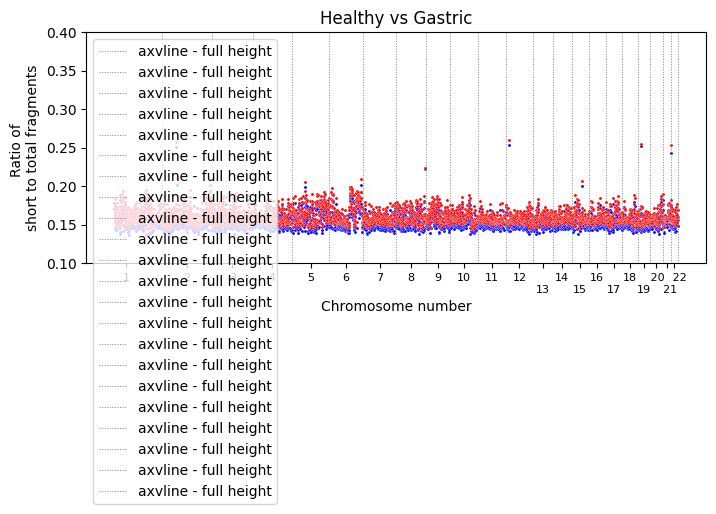

In [ ]:
G['Nongastric']='cyan'
for p in PAIR:
    col1='Mean of '+p.split(" vs ")[0]
    #col2='Mean of '+p.split(" vs ")[1]
    # col_log='Log2FC_'+p 
    # col_PADJ='PADJ_'+p 
    # vectorcolorCNA=[]
    # for i in range(len(stat_GWFP_ratio)):
    #     if stat_CNA[col_PADJ].iloc[i] >= 0.05:
    #         vectorcolorCNA+=['gray']
    #     elif stat_CNA[col_log].iloc[i] > 0:
    #         vectorcolorCNA+=['red']
    #     else:
    #         vectorcolorCNA+=['blue']
    plt.figure(figsize=(8,3))
    for vline in results['Vline']:
        plt.axvline(x=vline, color='gray', label='axvline - full height',ls=':',lw=0.7)
    xlabels=['1','2','3','4','5','6','7','8','9','10','11','12','\n13','14','\n15','16','\n17','18','\n19',' 20','\n  21','   22']
    sb.scatterplot(x=GWFP['FEATURES'],y=GWFP[col1],c=G[p.split(" vs ")[0]],s=5,edgecolor='w')
    sb.scatterplot(x=GWFP['FEATURES'],y=GWFP[col2],c=G[p.split(" vs ")[1]],s=5,edgecolor='w')
    plt.xticks(ticks=results['Position'],labels=xlabels,fontsize=8)
    plt.yticks(np.arange(0.1,0.4,0.05))
    # plt.ylim((0.1,0.35))
    plt.xlabel('Chromosome number')
    plt.ylabel('Ratio of \nshort to total fragments')
    plt.title(p)
    custom_lines = [Line2D([0], [0],marker='o',color='w', markerfacecolor='b', markersize=6,mec='w'),
                    Line2D([0], [0],marker='o', color='w', markerfacecolor='g', markersize=6,mec='w'),
                    Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=6,mec='w'),
                    Line2D([0], [0],marker='o', color='w', markerfacecolor='cyan', markersize=6,mec='w')]
    # plt.legend(custom_lines,[p.split(" vs ")[1],p.split(" vs ")[0]],loc='upper right', bbox_to_anchor=(0.5, -0.3),frameon=False)
    # plt.legend(custom_lines,[p.split(" vs ")[1],p.split(" vs ")[0]],loc='upper left', bbox_to_anchor=(1, 0.5),frameon=False)
    plt.legend(custom_lines,['Healthy (n='+str(len(healthy))+')','Gastric_benign (n='+str(len(gastric_benign))+')','Gastric (n='+str(len(gastric))+')','Nongastric (n='+str(len(Nongastric))+')'],loc='center right',bbox_to_anchor=(1.3, 0.8),frameon=True,edgecolor='w')
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    # plt.savefig('.\Figure\FLEN_ratio_short_total.png', dpi=600, bbox_inches='tight')

PCA

In [ ]:
G={
    'Healthy':'b',
    'Gastric_benign':'g',
    'Gastric':'r'
    }

In [ ]:
special_samples=['KGDAAA09','MG168','ZK0AAAI07NB','ZMG050NB']
special_samples

['KGDAAA09', 'MG168', 'ZK0AAAI07NB', 'ZMG050NB']

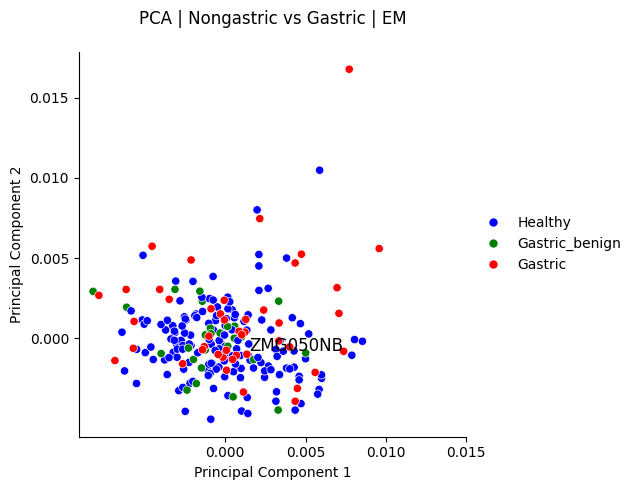

In [ ]:
f='EM'
# for f in features:
PCAsigfea(
      DATA,
      SAMPLES,
      stats_fea,
      dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
      p='Nongastric vs Gastric',
      f=f,
      sig=False,alpha=0.05,
      show_ID=True,IDs=special_samples,
      plot_pct_explain=False,top_pc=2,
      yticks=[0,0.02,0.005],xticks=[0,0.02,0.005],
      save=False,figname='PCA.png'
            )

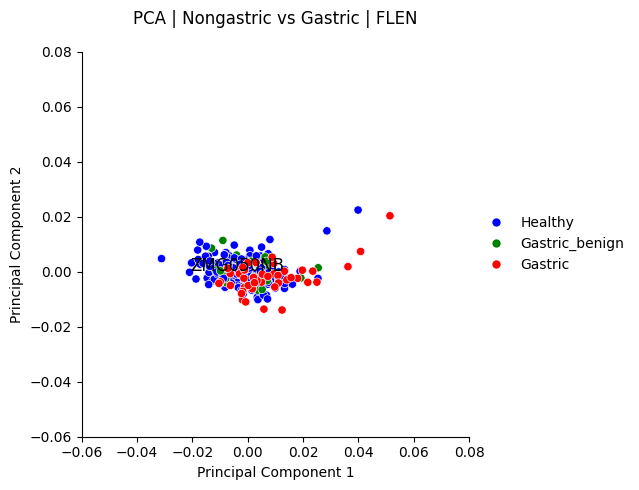

In [ ]:
f='FLEN'
# for f in features:
PCAsigfea(
      DATA,
      SAMPLES,
      stats_fea,
      dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
      p='Nongastric vs Gastric',
      f=f,
      sig=False,alpha=0.05,
      show_ID=True,IDs=special_samples,
      plot_pct_explain=False,top_pc=2,
      yticks=[-0.06,0.08,0.02],xticks=[-0.06,0.08,0.02],
      save=False,figname='PCA.png'
            )

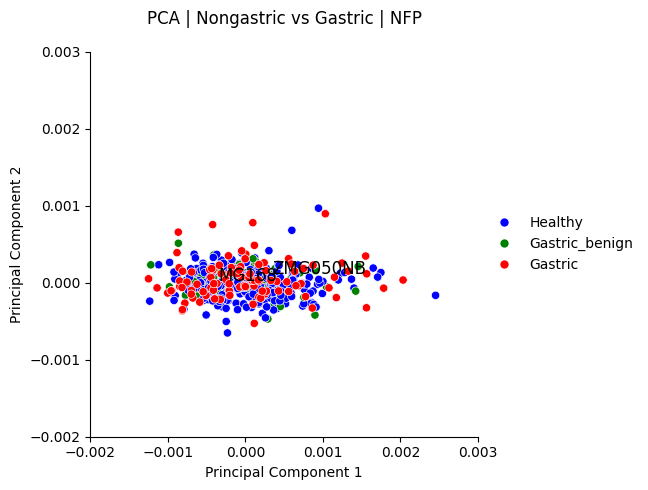

In [ ]:
f='NFP'
# for f in features:
PCAsigfea(
      DATA,
      SAMPLES,
      stats_fea,
      dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
      p='Nongastric vs Gastric',
      f=f,
      sig=False,alpha=0.05,
      show_ID=True,IDs=special_samples,
      plot_pct_explain=False,top_pc=2,
      yticks=[-0.002,0.004,0.001],xticks=[-0.002,0.004,0.001],
      save=False,figname='PCA.png'
            )

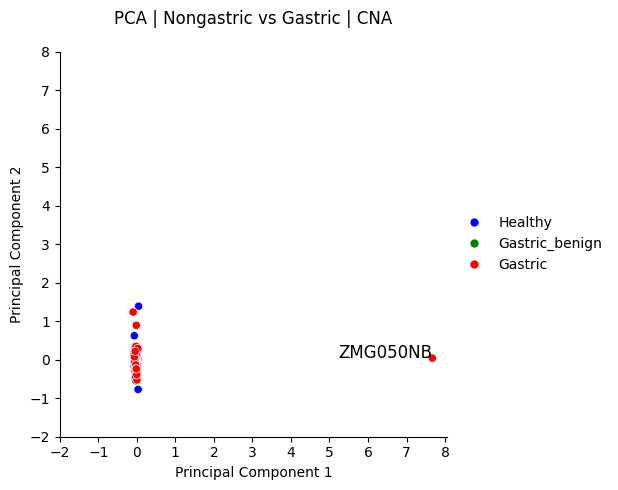

In [ ]:
f='CNA'
# for f in features:
PCAsigfea(
      DATA,
      SAMPLES,
      stats_fea,
      dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
      p='Nongastric vs Gastric',
      f=f,
      sig=False,alpha=0.05,
      show_ID=True,IDs=special_samples,
      plot_pct_explain=False,top_pc=2,
      yticks=[-2,9,1],xticks=[-2,9,1],
      save=False,figname='PCA.png'
            )

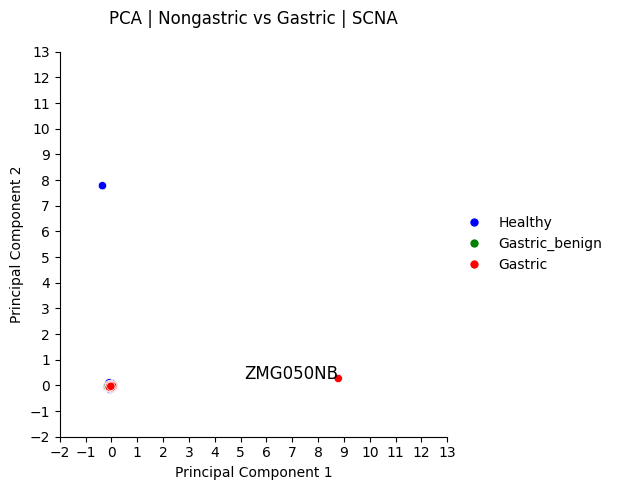

In [ ]:
f='SCNA'
# for f in features:
PCAsigfea(
      DATA,
      SAMPLES,
      stats_fea,
      dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
      p='Nongastric vs Gastric',
      f=f,
      sig=False,alpha=0.05,
      show_ID=True,IDs=special_samples,
      plot_pct_explain=False,top_pc=2,
      yticks=[-2,14,1],xticks=[-2,14,1],
      save=False,figname='PCA.png'
            )

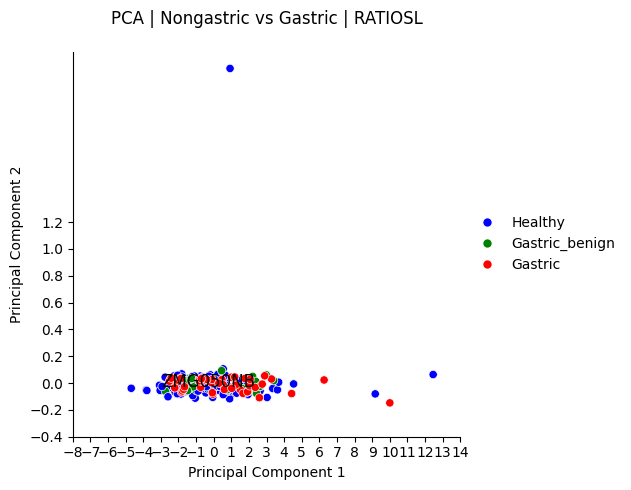

In [ ]:
f='RATIOSL'
# for f in features:
PCAsigfea(
      DATA,
      SAMPLES,
      stats_fea,
      dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
      p='Nongastric vs Gastric',
      f=f,
      sig=False,alpha=0.05,
      show_ID=True,IDs=special_samples,
      plot_pct_explain=False,top_pc=2,
      yticks=[-0.4,1.4,0.2],xticks=[-8,15,1],
      save=False,figname='PCA.png'
            )

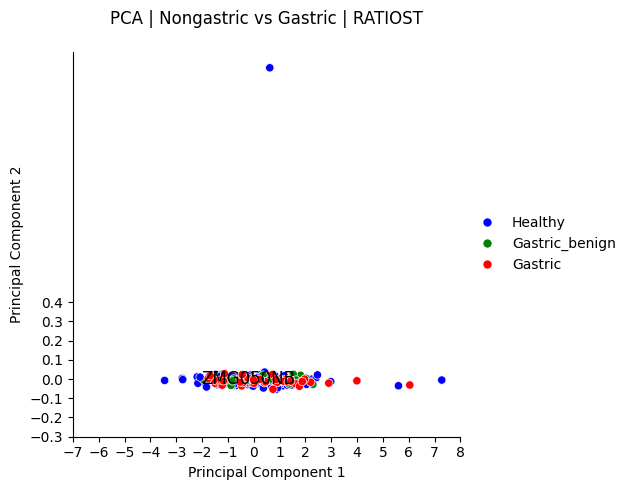

In [ ]:
f='RATIOST'
# for f in features:
PCAsigfea(
      DATA,
      SAMPLES,
      stats_fea,
      dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
      p='Nongastric vs Gastric',
      f=f,
      sig=False,alpha=0.05,
      show_ID=True,IDs=special_samples,
      plot_pct_explain=False,top_pc=2,
      yticks=[-0.3,0.5,0.1],xticks=[-7,9,1],
      save=False,figname='PCA.png'
            )

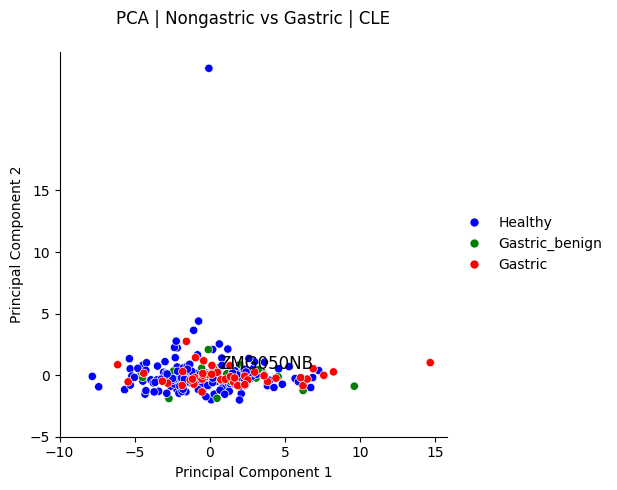

In [ ]:
f='CLE'
# for f in features:
PCAsigfea(
      DATA,
      SAMPLES,
      stats_fea,
      dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
      p='Nongastric vs Gastric',
      f=f,
      sig=False,alpha=0.05,
      show_ID=True,IDs=special_samples,
      plot_pct_explain=False,top_pc=2,
      yticks=[-5,20,5],xticks=[-10,20,5],
      save=False,figname='PCA.png'
            )

PCA filter

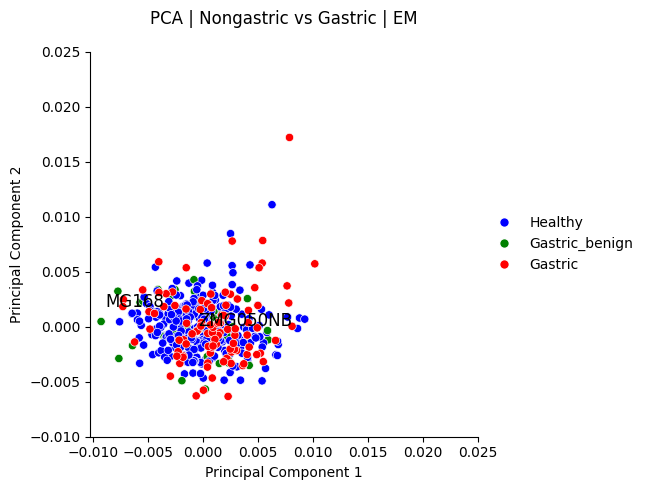

In [ ]:
f='EM'
healthy1=healthy[~healthy.iloc[:, 0].str.contains(special_sample, na=False)]
Nongastric1=pd.concat([healthy1,gastric_benign],axis=0)
PCAsigfea(
        DATA,
        SAMPLES={'Healthy':healthy1,'Gastric':gastric,'Gastric_benign':gastric_benign,'Nongastric':Nongastric1},
        stats_fea=stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        p='Nongastric vs Gastric',
        f=f,
        sig=False,alpha=0.05,
        show_ID=True,IDs=special_samples,
        plot_pct_explain=False,top_pc=2,
        yticks=[-0.01,0.025,0.005],xticks=[-0.01,0.025,0.005],
        save=False,figname='PCA.png'
              )

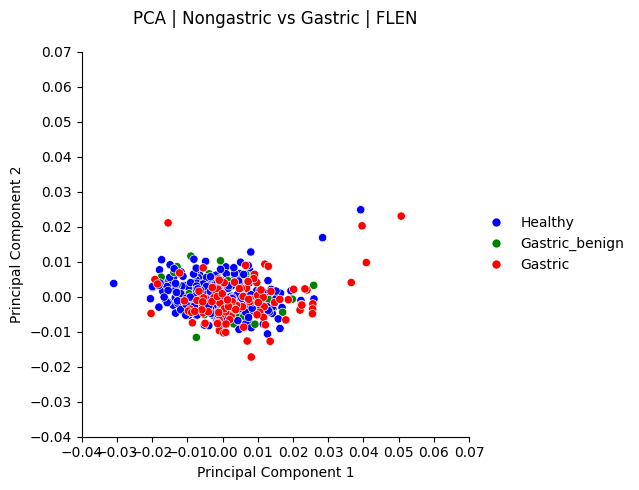

In [ ]:
f='FLEN'
healthy1=healthy[~healthy.iloc[:, 0].str.contains(special_sample, na=False)]
Nongastric1=pd.concat([healthy1,gastric_benign],axis=0)
PCAsigfea(
        DATA,
        SAMPLES={'Healthy':healthy1,'Gastric':gastric,'Gastric_benign':gastric_benign,'Nongastric':Nongastric1},
        stats_fea=stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        p='Nongastric vs Gastric',
        f=f,
        sig=False,alpha=0.05,
        show_ID=True,IDs=[special_sample],
        plot_pct_explain=False,top_pc=2,
        yticks=[-0.04,0.07,0.01],xticks=[-0.04,0.07,0.01],
        save=False,figname='PCA.png'
              )

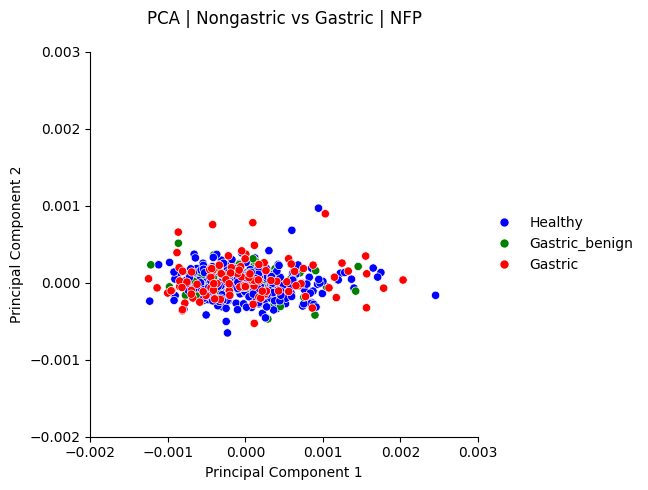

In [ ]:
f='NFP'
# for f in features:
PCAsigfea(
      DATA,
      SAMPLES={'Healthy':healthy1,'Gastric':gastric,'Gastric_benign':gastric_benign,'Nongastric':Nongastric1},
      stats_fea=stats_fea,
      dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
      p='Nongastric vs Gastric',
      f=f,
      sig=False,alpha=0.05,
      show_ID=True,IDs=[special_sample],
      plot_pct_explain=False,top_pc=2,
      yticks=[-0.002,0.004,0.001],xticks=[-0.002,0.004,0.001],
      save=False,figname='PCA.png'
            )

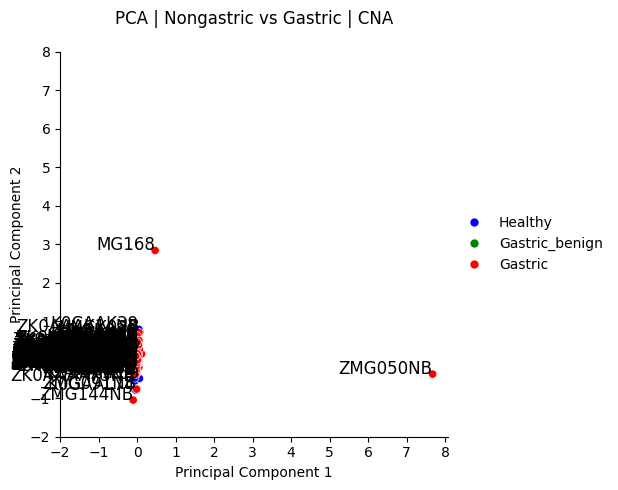

In [ ]:
f='CNA'
# for f in features:
PCAsigfea(
      DATA,
      SAMPLES={'Healthy':healthy1,'Gastric':gastric,'Gastric_benign':gastric_benign,'Nongastric':Nongastric1},
      stats_fea=stats_fea,
      dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
      p='Nongastric vs Gastric',
      f=f,
      sig=False,alpha=0.05,
      show_ID=True,IDs=list(set(sample_list_all['SampleID'])-set(special_sample)),
      plot_pct_explain=False,top_pc=2,
      yticks=[-2,9,1],xticks=[-2,9,1],
      save=False,figname='PCA.png'
            )

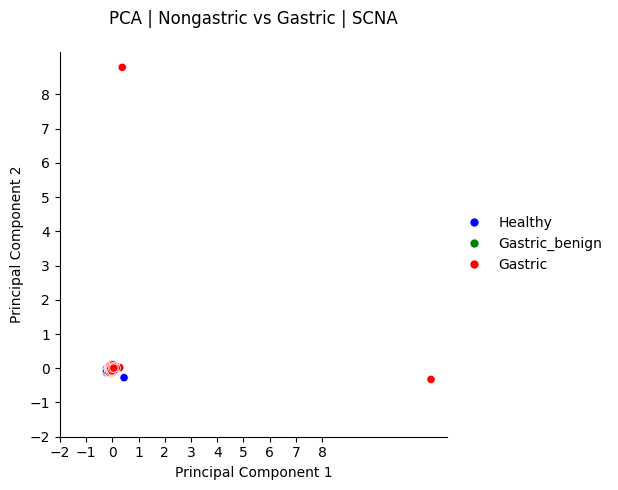

In [ ]:
f='SCNA'
# for f in features:
PCAsigfea(
      DATA,
      SAMPLES={'Healthy':healthy1,'Gastric':gastric,'Gastric_benign':gastric_benign,'Nongastric':Nongastric1},
      stats_fea=stats_fea,
      dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
      p='Nongastric vs Gastric',
      f=f,
      sig=False,alpha=0.05,
      show_ID=True,IDs=[special_sample],
      plot_pct_explain=False,top_pc=2,
      yticks=[-2,9,1],xticks=[-2,9,1],
      save=False,figname='PCA.png'
            )

t-SNE

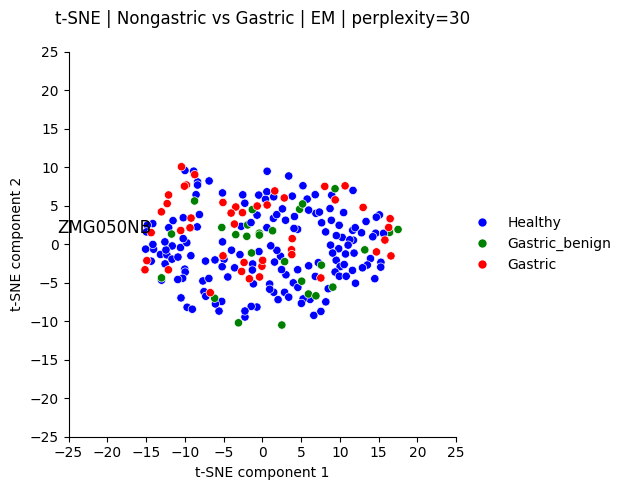

In [ ]:
f='EM'
TSNEfea(DATA, SAMPLES,stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        f=f,
    p='Nongastric vs Gastric',
    sig=False,alpha=0.05,
    show_ID=True,IDs=special_samples,
    yticks=[-25,30,5],
    xticks=[-25,30,5],
    perplexity=30,
    save=False,
    figname='TSNE.png')

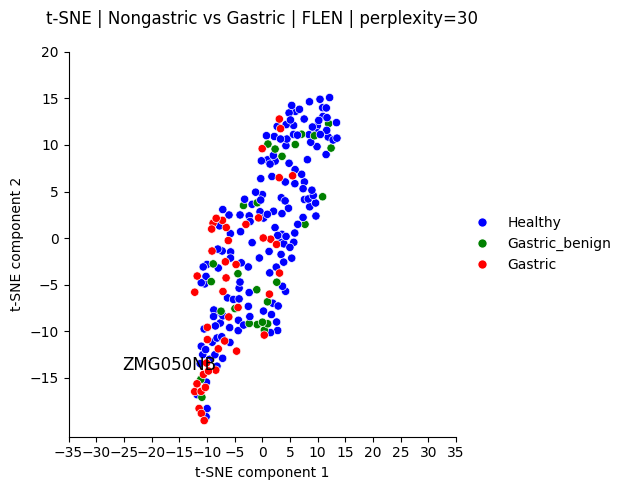

In [ ]:
f='FLEN'
TSNEfea(DATA, SAMPLES,stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        f=f,
    p='Nongastric vs Gastric',
    sig=False,alpha=0.05,
    show_ID=True,IDs=special_samples,
    yticks=[-15,25,5],
    xticks=[-35,40,5],
    perplexity=30,
    save=False,
    figname='TSNE.png')

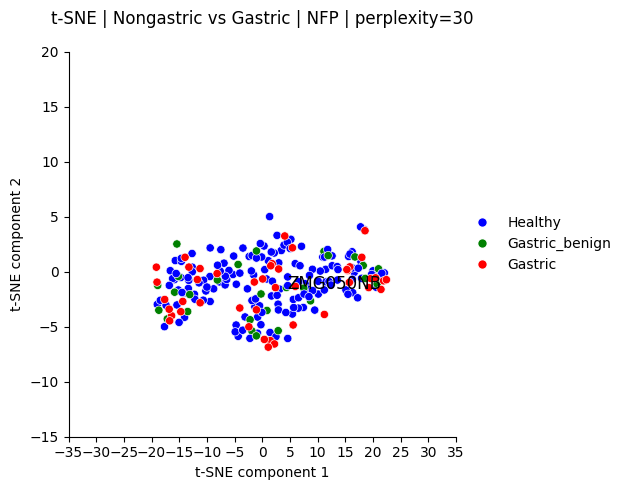

In [ ]:
f='NFP'
TSNEfea(DATA, SAMPLES,stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        f=f,
    p='Nongastric vs Gastric',
    sig=False,alpha=0.05,
    show_ID=True,IDs=special_samples,
    yticks=[-15,25,5],
    xticks=[-35,40,5],
    perplexity=30,
    save=False,
    figname='TSNE.png')

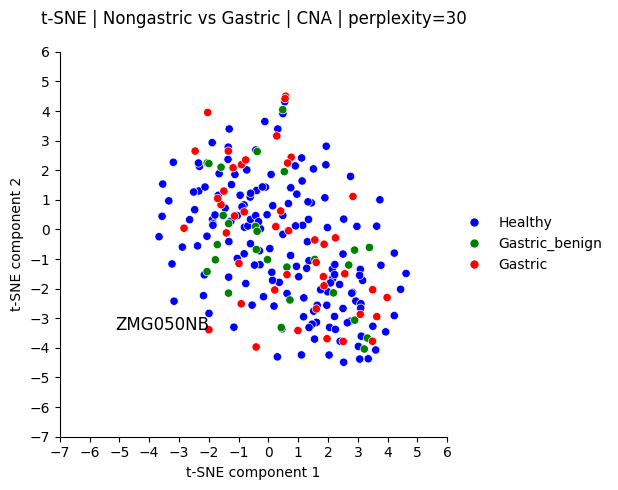

In [ ]:
f='CNA'
TSNEfea(DATA, SAMPLES,stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        f=f,
    p='Nongastric vs Gastric',
    sig=False,alpha=0.05,
    show_ID=True,IDs=special_samples,
    yticks=[-7,7,1],
    xticks=[-7,7,1],
    perplexity=30,
    save=False,
    figname='TSNE.png')

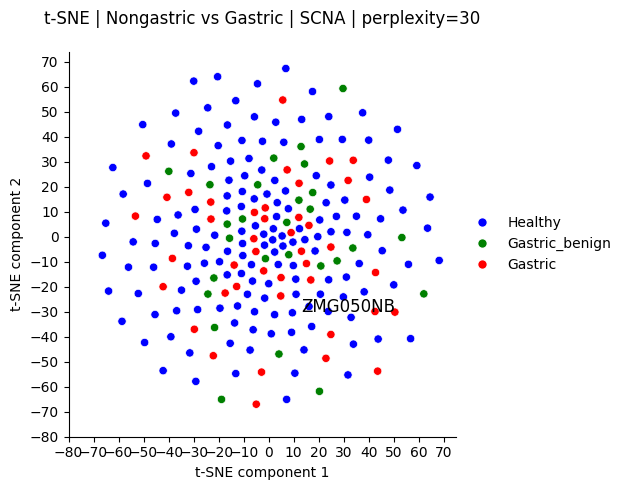

In [ ]:
f='SCNA'
TSNEfea(DATA, SAMPLES,stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        f=f,
    p='Nongastric vs Gastric',
    sig=False,alpha=0.05,
    show_ID=True,IDs=special_samples,
    yticks=[-80,80,10],
    xticks=[-80,80,10],
    perplexity=30,
    save=False,
    figname='TSNE.png')

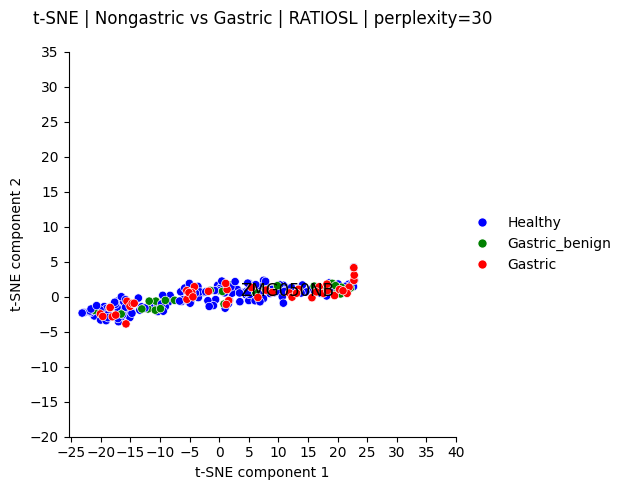

In [ ]:
f='RATIOSL'
TSNEfea(DATA, SAMPLES,stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        f=f,
    p='Nongastric vs Gastric',
    sig=False,alpha=0.05,
    show_ID=True,IDs=special_samples,
    yticks=[-20,40,5],
    xticks=[-25,45,5],
    perplexity=30,
    save=False,
    figname='TSNE.png')

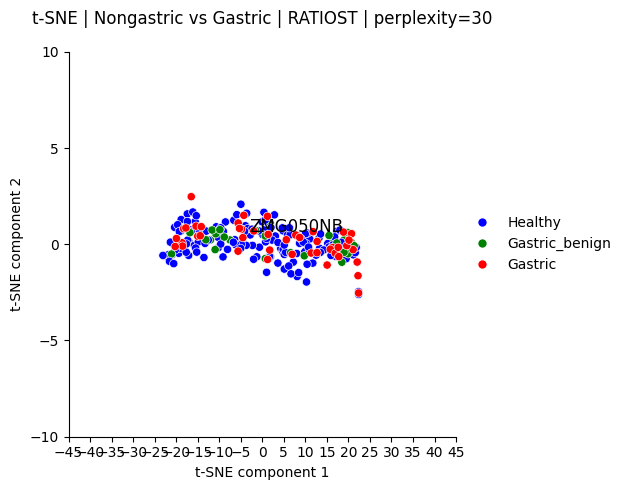

In [ ]:
f='RATIOST'
TSNEfea(DATA, SAMPLES,stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        f=f,
    p='Nongastric vs Gastric',
    sig=False,alpha=0.05,
    show_ID=True,IDs=special_samples,
    yticks=[-10,15,5],
    xticks=[-45,50,5],
    perplexity=30,
    save=False,
    figname='TSNE.png')

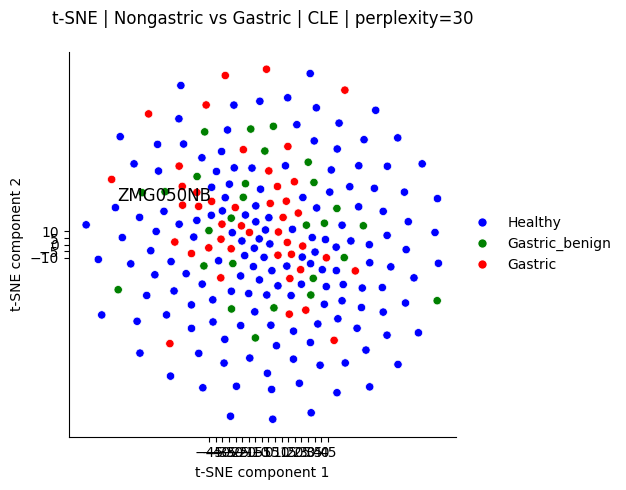

In [ ]:
f='CLE'
TSNEfea(DATA, SAMPLES,stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        f=f,
    p='Nongastric vs Gastric',
    sig=False,alpha=0.05,
    show_ID=True,IDs=special_samples,
    yticks=[-10,15,5],
    xticks=[-45,50,5],
    perplexity=30,
    save=False,
    figname='TSNE.png')

UMAP

C:\Users\VODACHO\AppData\Roaming\Python\Python38\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


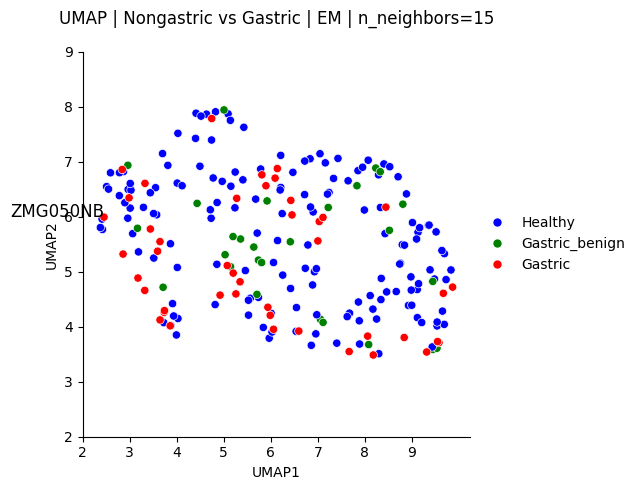

In [ ]:
f='EM'
UMAPfea(
        DATA, SAMPLES,stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        f=f,p='Nongastric vs Gastric',
        sig=False,alpha=0.05,show_ID=True,IDs=special_samples,
        yticks=[2,10,1],
        xticks=[2,10,1],
        n_neighbors=15,n_components=2,
        save=False,figname='UMAP.png'
            )

C:\Users\VODACHO\AppData\Roaming\Python\Python38\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


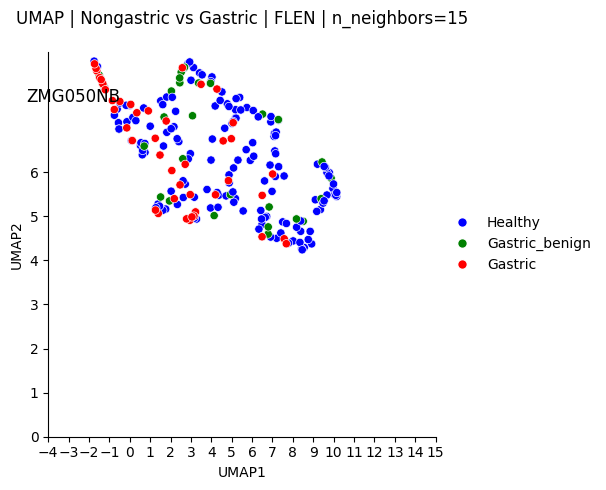

In [ ]:
f='FLEN'
UMAPfea(
        DATA, SAMPLES,stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        f=f,p='Nongastric vs Gastric',
        sig=False,alpha=0.05,show_ID=True,IDs=special_samples,
        yticks=[0,7,1],
        xticks=[-4,16,1],
        n_neighbors=15,n_components=2,
        save=False,figname='UMAP.png'
            )

C:\Users\VODACHO\AppData\Roaming\Python\Python38\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


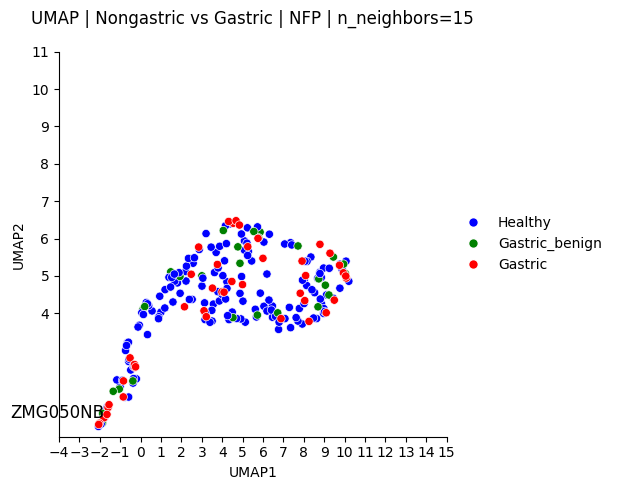

In [ ]:
f='NFP'
UMAPfea(
        DATA, SAMPLES,stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        f=f,p='Nongastric vs Gastric',
        sig=False,alpha=0.05,show_ID=True,IDs=special_samples,
        yticks=[4,12,1],
        xticks=[-4,16,1],
        n_neighbors=15,n_components=2,
        save=False,figname='UMAP.png'
            )

C:\Users\VODACHO\AppData\Roaming\Python\Python38\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


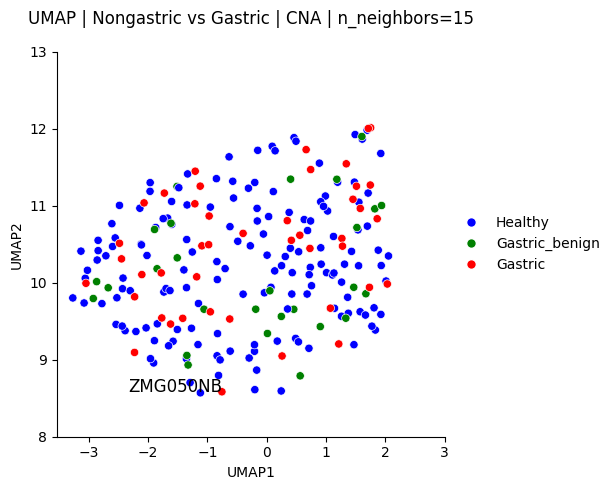

In [ ]:
f='CNA'
UMAPfea(
        DATA, SAMPLES,stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        f=f,p='Nongastric vs Gastric',
        sig=False,alpha=0.05,show_ID=True,IDs=special_samples,
        yticks=[8,14,1],
        xticks=[-3,4,1],
        n_neighbors=15,n_components=2,
        save=False,figname='UMAP.png'
            )

C:\Users\VODACHO\AppData\Roaming\Python\Python38\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


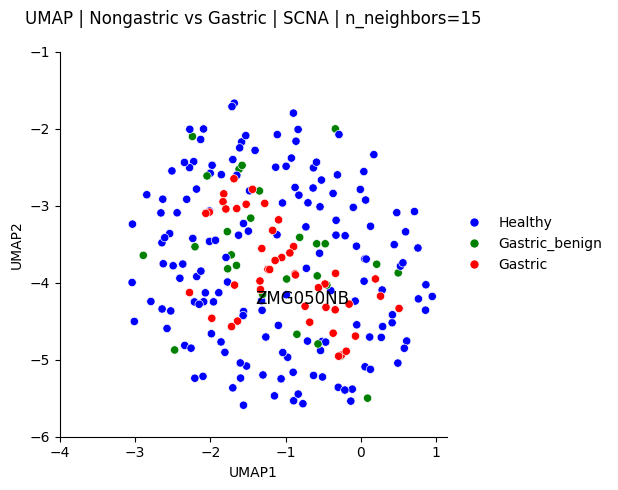

In [ ]:
f='SCNA'
UMAPfea(
        DATA, SAMPLES,stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        f=f,p='Nongastric vs Gastric',
        sig=False,alpha=0.05,show_ID=True,IDs=special_samples,
        yticks=[-6,0,1],
        xticks=[-4,2,1],
        n_neighbors=15,n_components=2,
        save=False,figname='UMAP.png'
            )

C:\Users\VODACHO\AppData\Roaming\Python\Python38\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


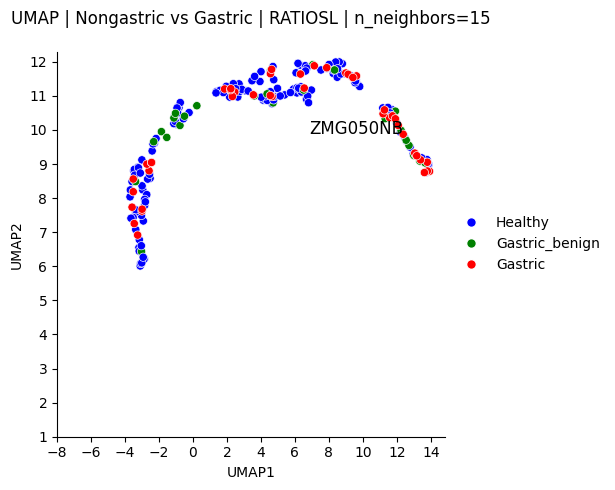

In [ ]:
f='RATIOSL'
UMAPfea(
        DATA, SAMPLES,stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        f=f,p='Nongastric vs Gastric',
        sig=False,alpha=0.05,show_ID=True,IDs=special_samples,
        yticks=[1,13,1],
        xticks=[-8,16,2],
        n_neighbors=15,n_components=2,
        save=False,figname='UMAP.png'
            )

C:\Users\VODACHO\AppData\Roaming\Python\Python38\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


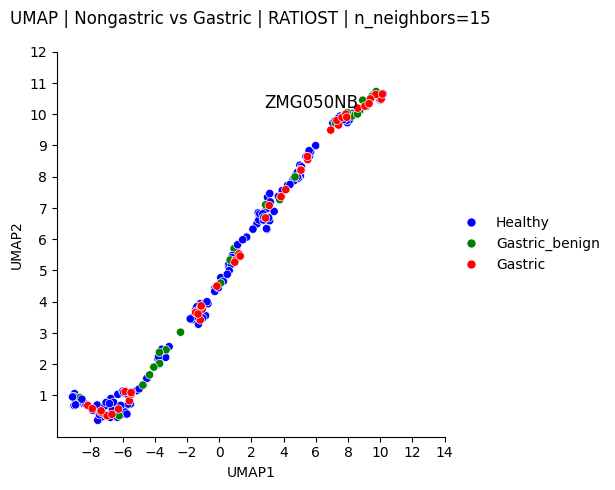

In [ ]:
f='RATIOST'
UMAPfea(
        DATA, SAMPLES,stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        f=f,p='Nongastric vs Gastric',
        sig=False,alpha=0.05,show_ID=True,IDs=special_samples,
        yticks=[1,13,1],
        xticks=[-8,16,2],
        n_neighbors=15,n_components=2,
        save=False,figname='UMAP.png'
            )

C:\Users\VODACHO\AppData\Roaming\Python\Python38\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


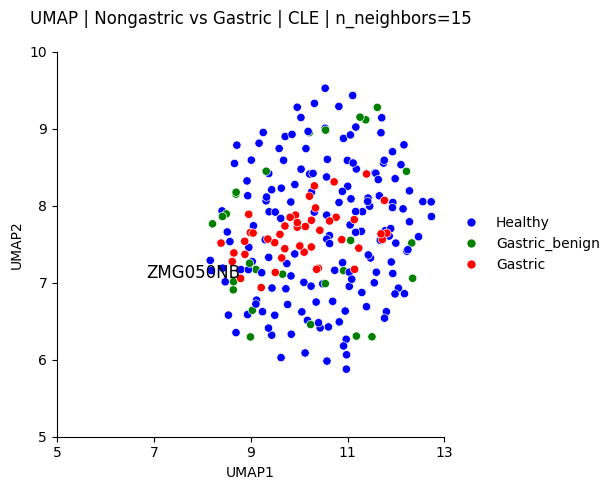

In [ ]:
f='CLE'
UMAPfea(
        DATA, SAMPLES,stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        f=f,p='Nongastric vs Gastric',
        sig=False,alpha=0.05,show_ID=True,IDs=special_samples,
        yticks=[5,11,1],
        xticks=[5,14,2],
        n_neighbors=15,n_components=2,
        save=False,figname='UMAP.png'
            )

LDA

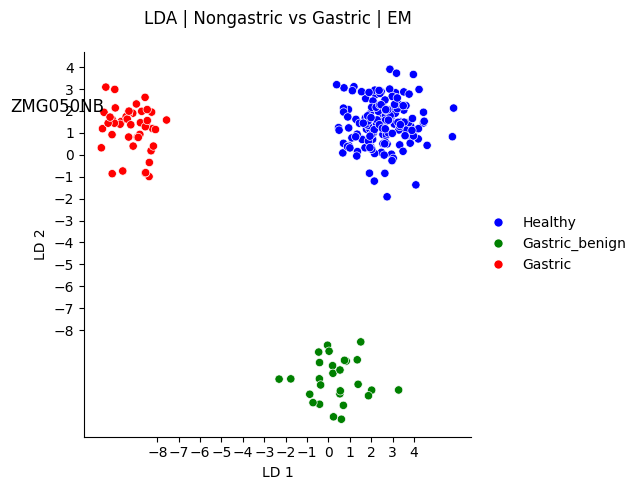

In [ ]:
f='EM'
LDAsigfea(DATA,SAMPLES,stats_fea=stats_fea,
          dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
          p='Nongastric vs Gastric',f=f,
              sig=False,alpha=0.05,show_ID=True,IDs=special_samples,
              yticks=[-8,5,1],xticks=[-8,5,1],
              save=False,figname='LDA.png'
              )

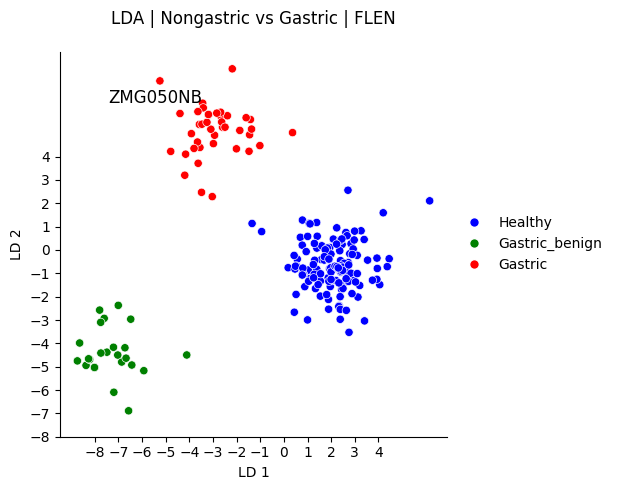

In [ ]:
f='FLEN'
LDAsigfea(DATA,SAMPLES,stats_fea=stats_fea,
          dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
          p='Nongastric vs Gastric',f=f,
              sig=False,alpha=0.05,show_ID=True,IDs=special_samples,
              yticks=[-8,5,1],xticks=[-8,5,1],
              save=False,figname='LDA.png'
              )

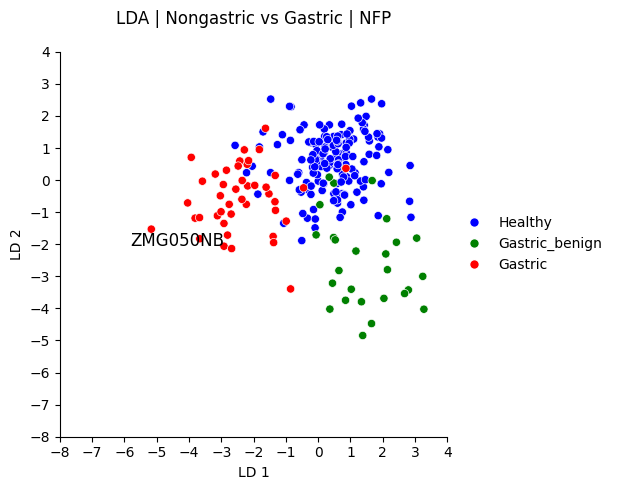

In [ ]:
f='NFP'
LDAsigfea(DATA,SAMPLES,stats_fea=stats_fea,
          dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
          p='Nongastric vs Gastric',f=f,
              sig=False,alpha=0.05,show_ID=True,IDs=special_samples,
              yticks=[-8,5,1],xticks=[-8,5,1],
              save=False,figname='LDA.png'
              )

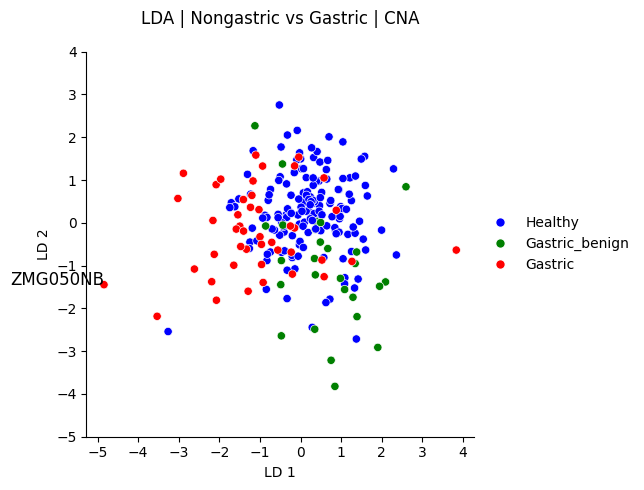

In [ ]:
f='CNA'
LDAsigfea(DATA,SAMPLES,stats_fea=stats_fea,
          dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
          p='Nongastric vs Gastric',f=f,
              sig=False,alpha=0.05,show_ID=True,IDs=special_samples,
              yticks=[-5,5,1],xticks=[-5,5,1],
              save=False,figname='LDA.png'
              )

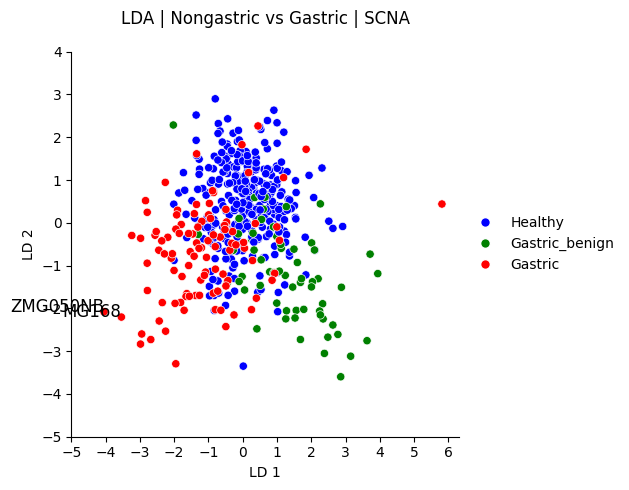

In [ ]:
f='SCNA'
LDAsigfea(DATA,SAMPLES,stats_fea=stats_fea,
          dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
          p='Nongastric vs Gastric',f=f,
              sig=False,alpha=0.05,show_ID=True,IDs=special_samples,
              yticks=[-5,5,1],xticks=[-5,7,1],
              save=False,figname='LDA.png'
              )

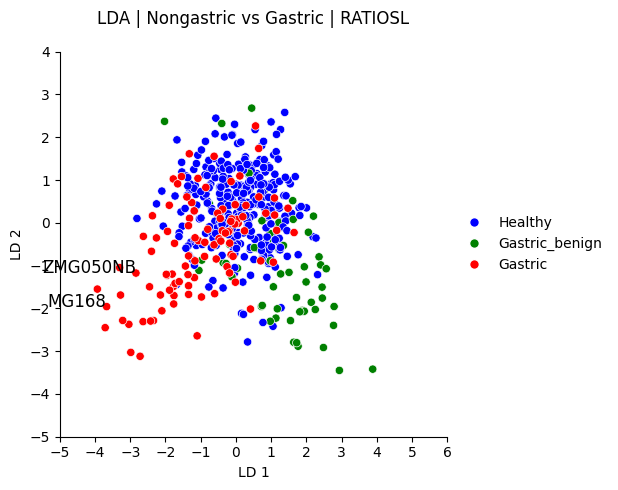

In [ ]:
f='RATIOSL'
LDAsigfea(DATA,SAMPLES,stats_fea=stats_fea,
          dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
          p='Nongastric vs Gastric',f=f,
              sig=False,alpha=0.05,show_ID=True,IDs=special_samples,
              yticks=[-5,5,1],xticks=[-5,7,1],
              save=False,figname='LDA.png'
              )

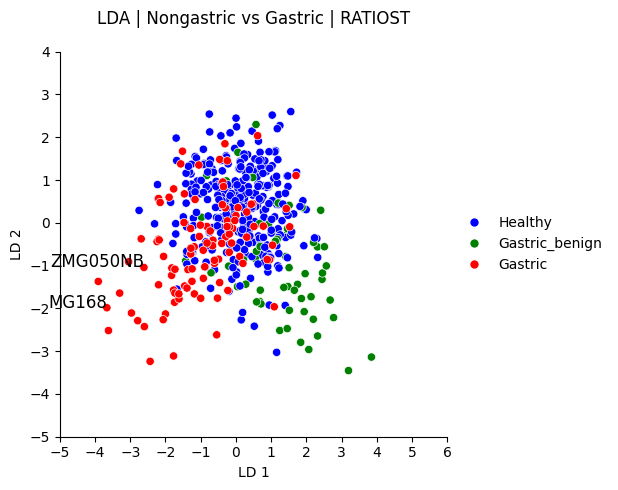

In [ ]:
f='RATIOST'
LDAsigfea(DATA,SAMPLES,stats_fea=stats_fea,
          dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
          p='Nongastric vs Gastric',f=f,
              sig=False,alpha=0.05,show_ID=True,IDs=special_samples,
              yticks=[-5,5,1],xticks=[-5,7,1],
              save=False)

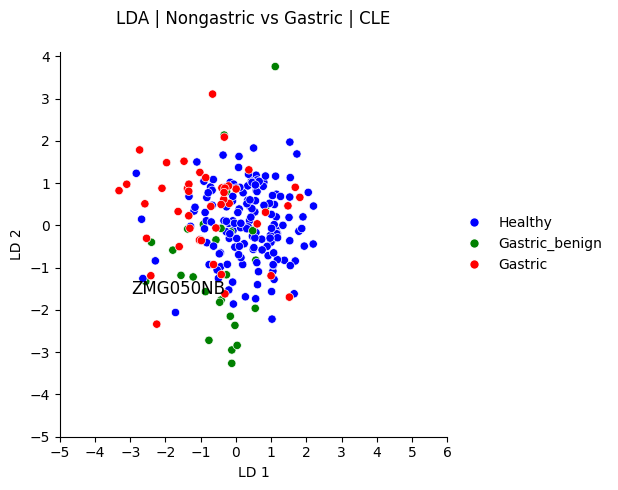

In [ ]:
f='CLE'
LDAsigfea(DATA,SAMPLES,stats_fea=stats_fea,
          dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
          p='Nongastric vs Gastric',f=f,
              sig=False,alpha=0.05,show_ID=True,IDs=special_samples,
              yticks=[-5,5,1],xticks=[-5,7,1],
              save=False)